<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        💳 Credit Risk Analysis 💸
    </h1>
</div>


# 📂 Overview

* **Background** <br>
  In the financial services industry, lending institutions face significant challenges in **managing credit risk** while maintaining profitability. Accurately assessing a borrower’s ability to repay is critical to **minimizing defaults** and ensuring sustainable lending practices.

* **Goal of the Project** <br>
  Using historical customer, financial, and credit behavior data, this project aims to build a predictive model that estimates the likelihood of a borrower defaulting on a loan. This enables financial institutions to **improve risk assessment**, **optimize loan approval decisions**, and **reduce potential losses**.

🎯 Key Features

**Target Variable**

* `loan_status`: *Loan status (e.g., fully paid, default, charged off)*

**Customer Demographics & Profile** <br>

* `person_age`: Age of the customer
* `gender`: Gender
* `marital_status`: Marital status
* `education_level`: Education level

**Financial & Employment Information** <br>

* `person_income`: Annual income
* `person_emp_length`: Employment length (in years)
* `employment_type`: Type of employment
* `person_home_ownership`: Home ownership status

**Loan Characteristics** <br>

* `loan_amnt`: Loan amount
* `loan_term_months`: Loan term (in months)
* `loan_int_rate`: Interest rate
* `loan_grade`: Loan risk grade (A–G)
* `loan_intent`: Loan purpose
* `loan_percent_income`: Loan-to-income percentage
* `loan_to_income_ratio`: Loan-to-income ratio

**Credit History** <br>

* `cb_person_cred_hist_length`: Credit history length
* `cb_person_default_on_file`: Historical default indicator

**Debt & Repayment Capacity** <br>

* `other_debt`: Other existing debts
* `debt_to_income_ratio`: Debt-to-income ratio

**Credit Behavior** <br>

* `open_accounts`: Number of open credit accounts
* `credit_utilization_ratio`: Credit utilization ratio
* `past_delinquencies`: Number of past delinquencies

**Geographic Information** <br>

* `country`: Country
* `state`: State/region
* `city`: City
* `city_latitude`: Latitude
* `city_longitude`: Longitude

📁 Files Provided

* `Credit_Risk_Dataset_Onyx_Data_September_25 - Credit Risk Data.csv`: Main dataset used for analysis and modeling

🚀 Project Objective

The primary objective of this project is to **perform exploratory data analysis (EDA)** and develop predictive models to classify whether a borrower is likely to default on a loan.

By leveraging these insights, financial institutions can:

* Improve **credit risk assessment**
* Enhance **loan approval strategies**
* Reduce **default rates and financial losses**

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
# ===============================
# Core Libraries
# ===============================
import pandas as pd              # Data handling
import numpy as np               # Numerical operations
import seaborn as sns            # Statistical plots
import matplotlib.pyplot as plt  # Visualization

# ===============================
# Project Utilities
# ===============================
from utils.logger import LoggerConfig
from utils.utils import Utils
from utils.config_loader import load_config
from config.config import CFG
from utils.colors_utils import ColorUtils
from utils.stats_utils import StatUtils
from utils.validation import DataValidator
from utils.feature_utils import FeatureUtils

# ===============================
# Modeling Utilities
# ===============================
from models.benchmark import *
from models.oof import *

# ===============================
# Hyperparameter Tuning
# ===============================
from models.catboost_tuning import *
from models.lgbm_tunning import *
from models.hgbc_tuning import *

# ===============================
# Explainability
# ===============================
from utils.explainability import *

# ===============================
# Notebook Display
# ===============================
from IPython.display import display, HTML

# ===============================
# Data Splitting & Preprocessing
# ===============================
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold

from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ===============================
# Evaluation
# ===============================
from sklearn.metrics import classification_report

# ===============================
# Machine Learning Models
# ===============================
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier

# ===============================
# Optimization
# ===============================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ===============================
# Environment Settings
# ===============================
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [2]:
# Initialize notebook logger
logger = LoggerConfig.setup_logger()

# Load datasets safely
df = Utils.read_csv_safe(path=CFG.DATA_PATH, logger=logger,
                         encodings=CFG.DEFAULT_ENCODING).pipe(Utils.clean_columns)

2026-05-06 13:14:26 | INFO     | Logging configured: level=DEBUG, format=colored
2026-05-06 13:14:27 | INFO     | Loaded file with encoding: utf-8 | Shape: (32581, 29)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [3]:
# Data Preview
display(df.head())

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-time,36,0.643382,15626.153440,0.930628,4,0.228103,0


In [4]:
# Display information about the DataFrames
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">
<h2 style="color:#f9e79f; margin-top:0;">📊 Insights from Initial Data Exploration</h2>

<b>Dataset Size and Structure</b>  
<ul>
<li>The dataset contains <b>32,581 records</b> with <b>29 features</b>.</li>
<li>The data is moderately sized and suitable for both <b>EDA</b> and <b>machine learning modeling</b>.</li>
</ul>

<b>Feature Overview</b>
<ul>
<li>The dataset includes comprehensive information for credit risk assessment:</li>
<ul>
<li><b>Numerical features:</b> <code>person_age</code>, <code>person_income</code>, <code>loan_amnt</code>, <code>loan_int_rate</code>, <code>loan_percent_income</code>, <code>debt_to_income_ratio</code>, <code>credit_utilization_ratio</code>, <code>open_accounts</code>, <code>past_delinquencies</code>.</li>
<li><b>Categorical features:</b> <code>person_home_ownership</code>, <code>loan_intent</code>, <code>loan_grade</code>, <code>gender</code>, <code>marital_status</code>, <code>education_level</code>, <code>employment_type</code>, <code>cb_person_default_on_file</code>, <code>location-related features</code>.</li>
</ul>
<li>The target variable is <code>loan_status</code>, represented as a <b>binary outcome (0/1)</b>, indicating loan repayment status.</li>
</ul>

<b>Data Quality and Completeness</b>  
<ul>
<li>Most features are complete, but some missing values are observed:</li>
<ul>
<li><code>person_emp_length</code> has missing values (~2.7%).</li>
<li><code>loan_int_rate</code> has notable missing values (~9.6%).</li>
</ul>
<li>Data types are consistent:</li>
<ul>
<li><b>Numerical:</b> int64 and float64</li>
<li><b>Categorical:</b> object (string)</li>
</ul>
</ul>

</div>

In [5]:
# Numerical Features
num_features = ["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "loan_percent_income", 
                "loan_to_income_ratio", "cb_person_cred_hist_length", "other_debt",  "debt_to_income_ratio", "open_accounts", 
                "credit_utilization_ratio"]

# Categorical Features
cat_features = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file", "gender", "marital_status", 
                "education_level", "employment_type", "country", "state", "city", "loan_term_months", "past_delinquencies"]

# Data Describe
cm = sns.light_palette("blue", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

,count,mean,std,min,25%,50%,75%,max
person_age,32581.000000,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,144.000000
person_income,32581.000000,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6000000.000000
person_emp_length,31686.000000,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,123.000000
loan_amnt,32581.000000,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,35000.000000
loan_int_rate,29465.000000,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,23.220000
loan_percent_income,32581.000000,0.170203,0.106782,0.000000,0.090000,0.150000,0.230000,0.830000
loan_to_income_ratio,32581.000000,0.170553,0.107049,0.000789,0.089655,0.148148,0.229167,0.830000
cb_person_cred_hist_length,32581.000000,5.804211,4.055001,2.000000,3.000000,4.000000,8.000000,30.000000
other_debt,32581.000000,11567.959773,13060.930898,225.207376,5387.168477,8995.070580,14562.930270,1187998.914000
debt_to_income_ratio,32581.000000,0.345208,0.129406,0.064502,0.251236,0.333188,0.423142,1.053888


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Descriptive Statistics
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><code>person_age</code>: Avg ~27.7; median ~26; range (~20 → 144) → mostly young population with extreme outliers (likely data quality issues).</li>

<li><code>person_income</code>: Avg ~66K; median ~55K; very wide range (~4K → 6M) → highly skewed distribution with strong outliers.</li>

<li><code>person_emp_length</code>: Avg ~4.8 years; median ~4; range (~0 → 123) → reasonable spread but contains unrealistic high values.</li>

<li><code>loan_amnt</code>: Avg ~9.6K; median ~8K; range (~500 → 35K) → moderately distributed loan sizes.</li>

<li><code>loan_int_rate</code>: Avg ~11%; range (~5.4 → 23.2) → typical lending rates with moderate variability.</li>

<li><code>loan_percent_income</code>: Avg ~17%; range (~0 → 83%) → indicates some borrowers take disproportionately high loans relative to income.</li>

<li><code>loan_to_income_ratio</code>: Similar distribution to <code>loan_percent_income</code> → potential redundancy between features.</li>

<li><code>cb_person_cred_hist_length</code>: Avg ~5.8 years; range (~2 → 30) → relatively short credit history for most borrowers.</li>

<li><code>other_debt</code>: Avg ~11.5K; extremely wide range (~225 → 1.18M) → highly skewed with significant outliers.</li>

<li><code>debt_to_income_ratio</code>: Avg ~0.35; range (~0.06 → 1.05) → high values indicate financial stress and elevated default risk.</li>

<li><code>open_accounts</code>: Avg ~8; range (~0 → 15) → moderate credit activity across customers.</li>

<li><code>credit_utilization_ratio</code>: Avg ~0.50; range (~0.05 → 0.95) → many users utilize a large portion of their credit limit.</li>

</ul>

</div>

In [6]:
df = Utils.reduce_mem_usage(cols=num_features, df=df)
df = Utils.convert_cat(features=cat_features, df=df)

# Display information about the DataFrames
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   client_ID                   32581 non-null  object  
 1   person_age                  32581 non-null  int16   
 2   person_income               32581 non-null  int32   
 3   person_home_ownership       32581 non-null  category
 4   person_emp_length           31686 non-null  float32 
 5   loan_intent                 32581 non-null  category
 6   loan_grade                  32581 non-null  category
 7   loan_amnt                   32581 non-null  int32   
 8   loan_int_rate               29465 non-null  float32 
 9   loan_status                 32581 non-null  int64   
 10  loan_percent_income         32581 non-null  float32 
 11  cb_person_default_on_file   32581 non-null  category
 12  cb_person_cred_hist_length  32581 non-null  int8    
 13  gender          

In [7]:
# Data Describe
display(df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836
gender,32581,2,Male,16371
marital_status,32581,4,Single,16368
education_level,32581,4,High School,13185
employment_type,32581,4,Full-time,19473
country,32581,3,UK,10944
state,32581,9,BC,3679


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Features Overview
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><code>person_home_ownership</code>: 4 categories; most customers are <b>RENT (~50%)</b> → suggests many borrowers do not own property, potentially increasing risk exposure.</li>

<li><code>loan_intent</code>: 6 categories; <b>EDUCATION</b> is the most common → indicates strong demand for education-related loans.</li>

<li><code>loan_grade</code>: 7 levels (A–G); majority in <b>Grade A</b> → dataset is skewed toward lower-risk borrowers.</li>

<li><code>cb_person_default_on_file</code>: Binary; majority <b>No (~82%)</b> → relatively low historical default rate.</li>

<li><code>gender</code>: Balanced distribution (Male slightly higher) → unlikely to strongly bias model.</li>

<li><code>marital_status</code>: <b>Single</b> is the dominant group → may correlate with different financial behaviors.</li>

<li><code>education_level</code>: Most borrowers have <b>High School</b> education → mid-level education dominates the dataset.</li>

<li><code>employment_type</code>: Majority are <b>Full-time</b> → indicates relatively stable income sources.</li>

<li><code>country</code>: 3 categories; <b>UK</b> appears most frequently → dataset concentrated in specific regions.</li>

<li><code>state</code>: 9 categories; moderate cardinality → useful for regional analysis.</li>

<li><code>city</code>: 18 categories; relatively higher cardinality → may require encoding strategies beyond simple one-hot.</li>

<li><code>loan_term_months</code>: 4 categories; <b>36 months</b> most common → standard loan duration dominates.</li>

<li><code>past_delinquencies</code>: 7 categories; majority have <b>0 past delinquencies</b> → indicates generally good repayment behavior.</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [8]:
logger.info("Start checking NULL values")
logger.info("-" * 80)
logger.info(f"Checking missing values for {CFG.DATASET_NAME}...")
DataValidator.checkNULL(df=df, logger=logger)
logger.info("-" * 80)
logger.info("Completed checking for NULL values across datasets.")

2026-05-06 13:14:27 | INFO     | Start checking NULL values
2026-05-06 13:14:27 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:27 | INFO     | Checking missing values for Credit Risk Dataset...
2026-05-06 13:14:27 | WARNING  | 
+-------------------+---------------+-----------+
| Feature           | Missing_Count | Missing_% |
+-------------------+---------------+-----------+
| loan_int_rate     | 3116          | 9.56      |
| person_emp_length | 895           | 2.75      |
+-------------------+---------------+-----------+
2026-05-06 13:14:27 | WARNING  | Total missing values: 4,011 out of 32,581 rows.
2026-05-06 13:14:27 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:27 | INFO     | Completed checking for NULL values across datasets.


## Checking duplicate Value

In [9]:
logger.info("Start checking duplicate values")
logger.info("-" * 80)
logger.info(f"Data duplicate Analysis...")
DataValidator.checkDuplicate(df=df, logger=logger)
logger.info("-" * 80)
logger.info("Duplicate value inspection successfully completed across datasets.")

2026-05-06 13:14:28 | INFO     | Start checking duplicate values
2026-05-06 13:14:28 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:28 | INFO     | Data duplicate Analysis...
2026-05-06 13:14:28 | INFO     | No duplicate rows found out of 32,581 total rows.
2026-05-06 13:14:28 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:28 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [10]:
logger.info("-" * 80)
outlier_data = DataValidator.checkOutlier(df=df, dataset_name="Bank Marketing", 
                                          list_feature=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Outlier checking successfully completed across datasets.")

2026-05-06 13:14:28 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:28 | INFO     | Checking outliers for Bank Marketing...
2026-05-06 13:14:28 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:28 | WARNING  | [Bank Marketing] person_age: 1,494 outliers detected (lower=12.500, upper=40.500)
2026-05-06 13:14:28 | WARNING  | [Bank Marketing] person_income: 1,484 outliers detected (lower=-22550.000, upper=140250.000)
2026-05-06 13:14:28 | WARNING  | [Bank Marketing] person_emp_length: 853 outliers detected (lower=-5.500, upper=14.500)
2026-05-06 13:14:28 | WARNING  | [Bank Marketing] loan_amnt: 1,689 outliers detected (lower=-5800.000, upper=23000.000)
2026-05-06 13:14:28 | WARNING  | [Bank Marketing] loan_int_rate: 6 outliers detected (lower=-0.455, upper=21.825)
2026-05-06 13:14:28 | WARNING  | [Bank Marketing] loan_percent_income: 651 outliers detected (lower=-0.1

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Data Quality Insights: Missing Values, Duplicates, and Outliers
</div>

<b>Missing Values Analysis</b>

<ul>
<li>Missing values were identified in <b>2 features</b>:</li>
<ul>
<li><code>loan_int_rate</code>: 3,116 missing (~9.56%) → significant and requires careful imputation.</li>
<li><code>person_emp_length</code>: 895 missing (~2.75%) → relatively minor but still needs handling.</li>
</ul>
<li>Total missing values: <b>4,011</b> across <b>32,581 records</b>.</li>
<li>Overall, the dataset is largely complete, with missingness concentrated in specific financial attributes.</li>
</ul>

<b>Duplicate Records Analysis</b>

<ul>
<li>No duplicate rows were detected across the dataset.</li>
<li>This ensures data integrity and prevents bias from repeated observations.</li>
</ul>

<b>Outlier Analysis</b>

<ul>
<li>Outliers are present across multiple numerical features, indicating high variability in borrower profiles.</li>
<ul>
<li>Strong outliers detected in <code>person_age</code>, <code>person_income</code>, <code>loan_amnt</code>, and <code>other_debt</code>.</li>
<li>Financial ratio features such as <code>loan_percent_income</code>, <code>loan_to_income_ratio</code>, and <code>debt_to_income_ratio</code> also show notable outliers.</li>
<li><code>person_emp_length</code> and <code>cb_person_cred_hist_length</code> contain unrealistic extreme values, suggesting potential data quality issues.</li>
</ul>
<li>Some features like <code>open_accounts</code> and <code>credit_utilization_ratio</code> show stable distributions with <b>no outliers detected</b>.</li>
<li>Outliers in financial datasets often reflect real-world extreme cases (e.g., high debt or income), so <b>removal should be handled carefully</b>.</li>
</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis (EDA)</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis (EDA)
    </h1>
</div>

## Loan Status Distribution

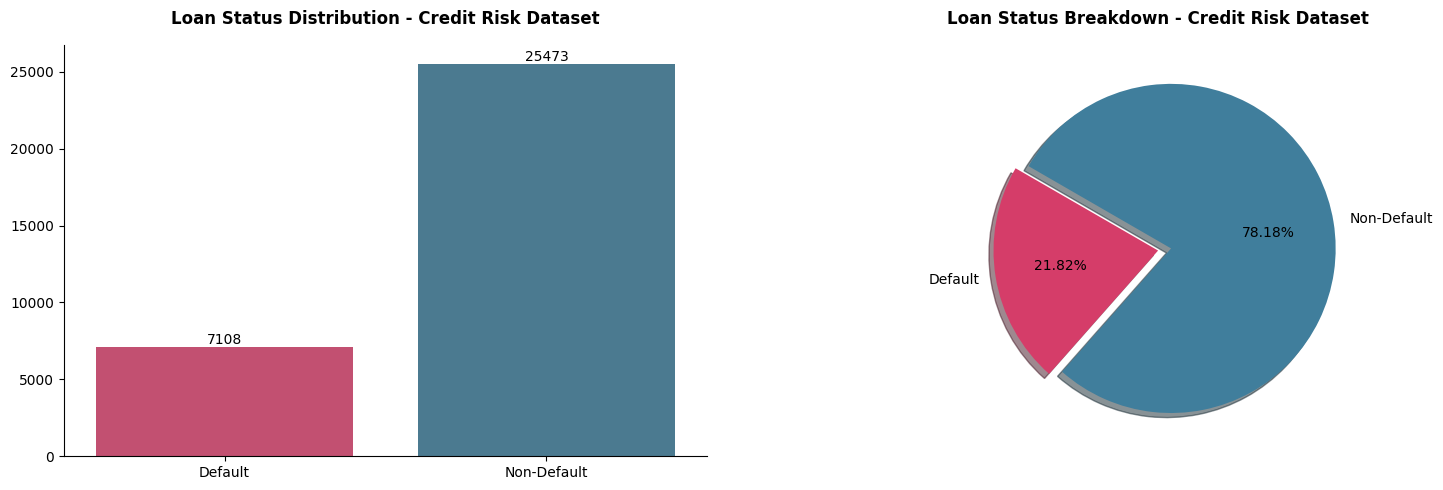

In [11]:
df_credit = df.copy()
mapping = {0: "Non-Default", 1: "Default"}
df_credit["loan_status"] = df_credit["loan_status"].map(mapping)

order = ["Default", "Non-Default"]
loan_status_distribution  = df_credit[CFG.TARGET_FEATURE].value_counts().reindex(order)
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 5))
n_color = ColorUtils.color(n_colors=df_credit[CFG.TARGET_FEATURE].nunique())
# ax[0]
sns.countplot(data=df_credit, x = CFG.TARGET_FEATURE, palette=n_color, 
              ax=ax[0], order=order)
ax[0].set_title(f"Loan Status Distribution - {CFG.DATASET_NAME}", weight="bold", fontsize=12, pad=15)
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[0].set_ylabel("")
ax[0].set_xlabel("")
sns.despine(ax=ax[0], top=True, right=True, left=False, bottom=False)

# ax[1]
ax[1].pie(
    loan_status_distribution,
    labels=order,
    colors = n_color,
    autopct = "%1.2f%%",
    startangle = 150,
    explode = (0, 0.08),
    shadow= True
)
ax[1].set_title(f"Loan Status Breakdown - {CFG.DATASET_NAME}",  weight="bold", fontsize=12, pad=15)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight
</div>

<table>
<tr>
<th>Dataset</th>
<th>Non-Default (0)</th>
<th>Default (1)</th>
<th>Default Rate</th>
</tr>
<tr>
<td><b>Credit Risk</b></td>
<td>25,473</td>
<td>7,108</td>
<td><b>21.82%</b></td>
</tr>
</table>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Majority class</b>: <code>Non-Default</code> (~78.18%) → most customers successfully repay their loans.</li>

<li><b>Minority class</b>: <code>Default</code> (~21.82%) → represents borrowers with repayment risk.</li>

<li>The dataset shows a <b>moderate class imbalance</b>, with roughly a <b>1:4 ratio</b> between default and non-default cases.</li>

<li>The default rate (~22%) is <b>significantly higher</b> than typical banking datasets → providing a stronger signal for model learning.</li>

<li>This imbalance suggests the need for:
<ul>
<li>Evaluation metrics beyond accuracy (e.g., <b>ROC-AUC, F1-score</b>)</li>
<li>Potential use of <b>class weighting</b> or <b>resampling techniques</b></li>
</ul>
</li>

</ul>

</div>

## Numerical Feature Distributions

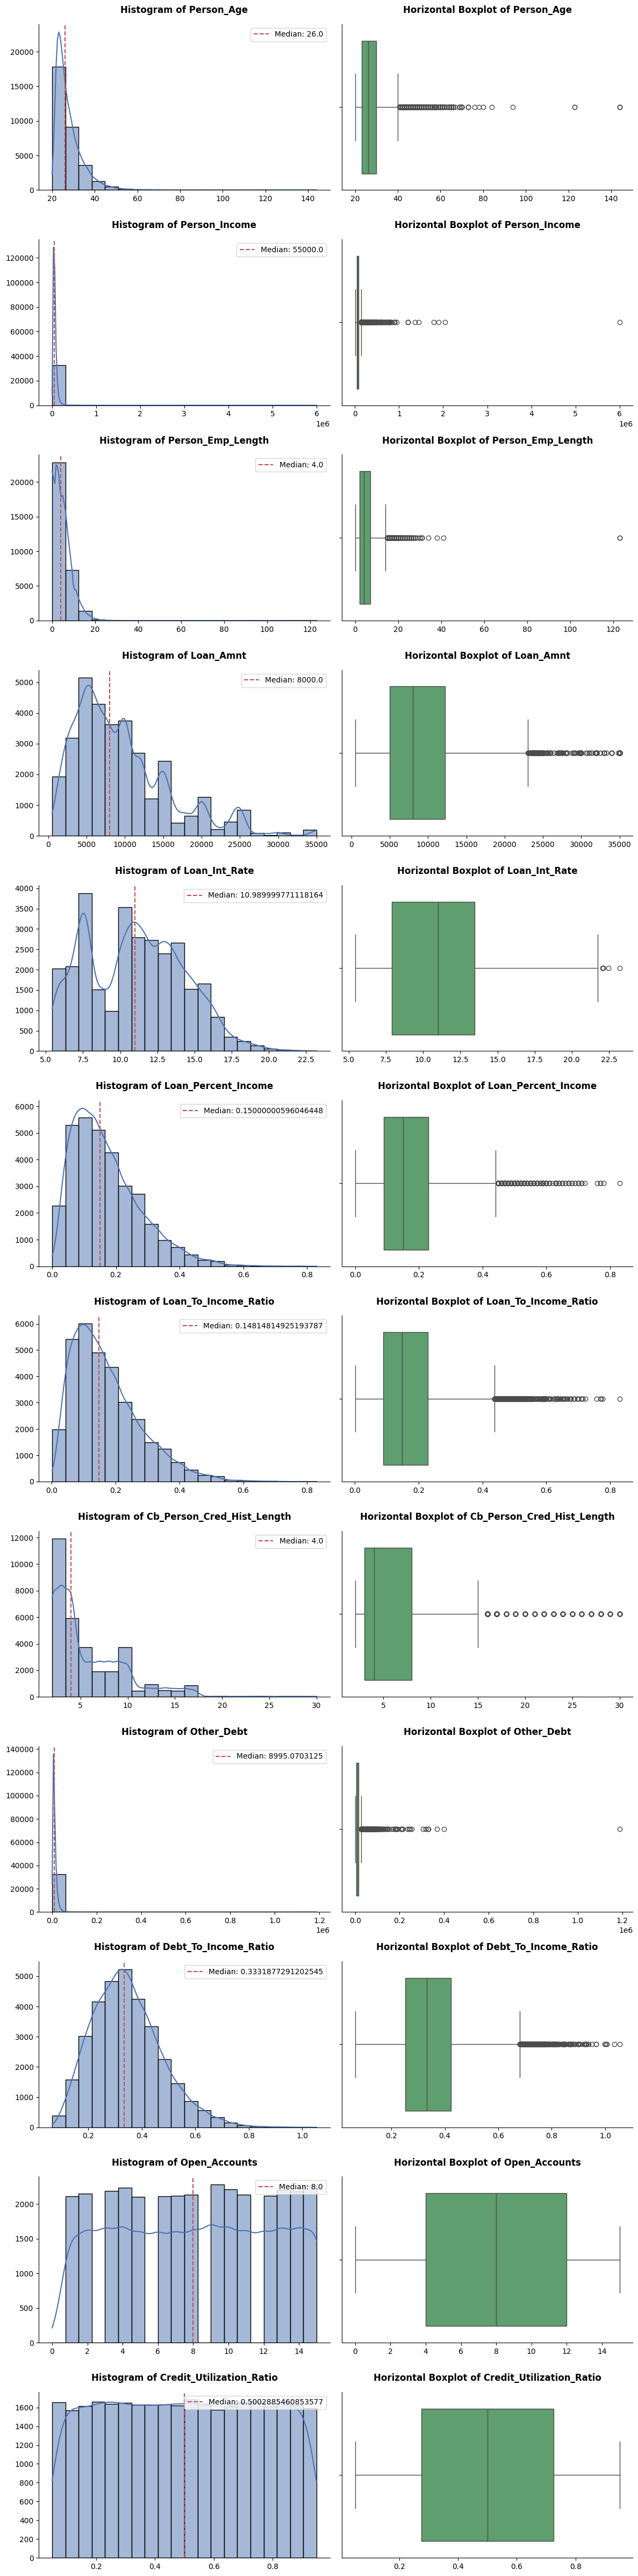

In [12]:
def plot_numerical_features(df=df, numerical_features = num_features):
    """
    Plot distribution of numerical features using Histogram and Boxplot.
    """

    # Create subplot grid
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    # Ensure ax is always 2D (important if only 1 feature)
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        # Histogram + KDE
        sns.histplot(data=df[feature], color="#4C72B0", bins = 20, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature.title()}", weight="bold", fontsize=12, pad=15)
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")

        # Draw vertical line for median
        ax[i, 0].axvline(df[feature].median(), color="#C44E52", linestyle="--", label=f"Median: {df[feature].median()}")
        ax[i, 0].legend(loc="upper right")
        sns.despine(ax=ax[i, 0], top=True, right=True, left=False, bottom=False)

        # Horizontal Boxplot
        sns.boxplot(data=df[feature], color="#55A868", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Boxplot of {feature.title()}", weight="bold", fontsize=12, pad=15)
        ax[i, 1].set_xlabel("")
        sns.despine(ax=ax[i, 1], top=True, right=True, left=False, bottom=False)

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [13]:
logger.info("-" * 80)
skew_feature = DataValidator.check_skewness(data=df_credit, dataset_name= CFG.DATASET_NAME, 
                                            numerical_features=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-05-06 13:14:35 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:35 | INFO     | Skewness analysis for Credit Risk Dataset
2026-05-06 13:14:35 | INFO     | Total numerical features checked: 12
2026-05-06 13:14:35 | DEBUG    | ----------------------------------------------------------------------
2026-05-06 13:14:35 | DEBUG    | Feature                        | Skewness  | Remark
2026-05-06 13:14:35 | DEBUG    | ----------------------------------------------------------------------
2026-05-06 13:14:35 | DEBUG    | person_income                  |  +32.8653 | Highly skewed
2026-05-06 13:14:35 | DEBUG    | other_debt                     |  +28.4619 | Highly skewed
2026-05-06 13:14:35 | DEBUG    | person_emp_length              |   +2.6145 | Highly skewed
2026-05-06 13:14:35 | DEBUG    | person_age                     |   +2.5814 | Highly skewed
2026-05-06 13:14:35 | DEBUG    | cb_person_cred_hist_length     |   +1.6618 | Hi

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>Most numerical features in the dataset are <b>right-skewed</b>, indicating that values are concentrated at lower ranges with <b>long tails and extreme outliers</b>.</li>

<li><b>9 out of 12 features</b> show significant skewness (<code>|skew| > 0.5</code>), highlighting strong non-normal distributions.</li>

<li>Features such as <code>person_income</code> and <code>other_debt</code> exhibit <b>extreme skewness</b> (skew &gt; 25), suggesting the presence of very large outliers and heavy-tailed distributions.</li>

<li>Moderately skewed features include <code>debt_to_income_ratio</code>, indicating some imbalance but less extreme compared to financial amount variables.</li>

<li>Features like <code>loan_int_rate</code>, <code>open_accounts</code>, and <code>credit_utilization_ratio</code> are <b>approximately symmetric</b>, making them more stable for modeling.</li>

<li>The strong skewness in financial variables reflects real-world behavior, where a small number of customers have <b>exceptionally high income or debt levels</b>.</li>

<li><b>Data transformation techniques</b> such as <b>log transformation, Box-Cox, or Yeo-Johnson</b> are recommended to reduce skewness and improve model performance.</li>

</ul>

</div>

## Correlation Analysis of Numerical Features

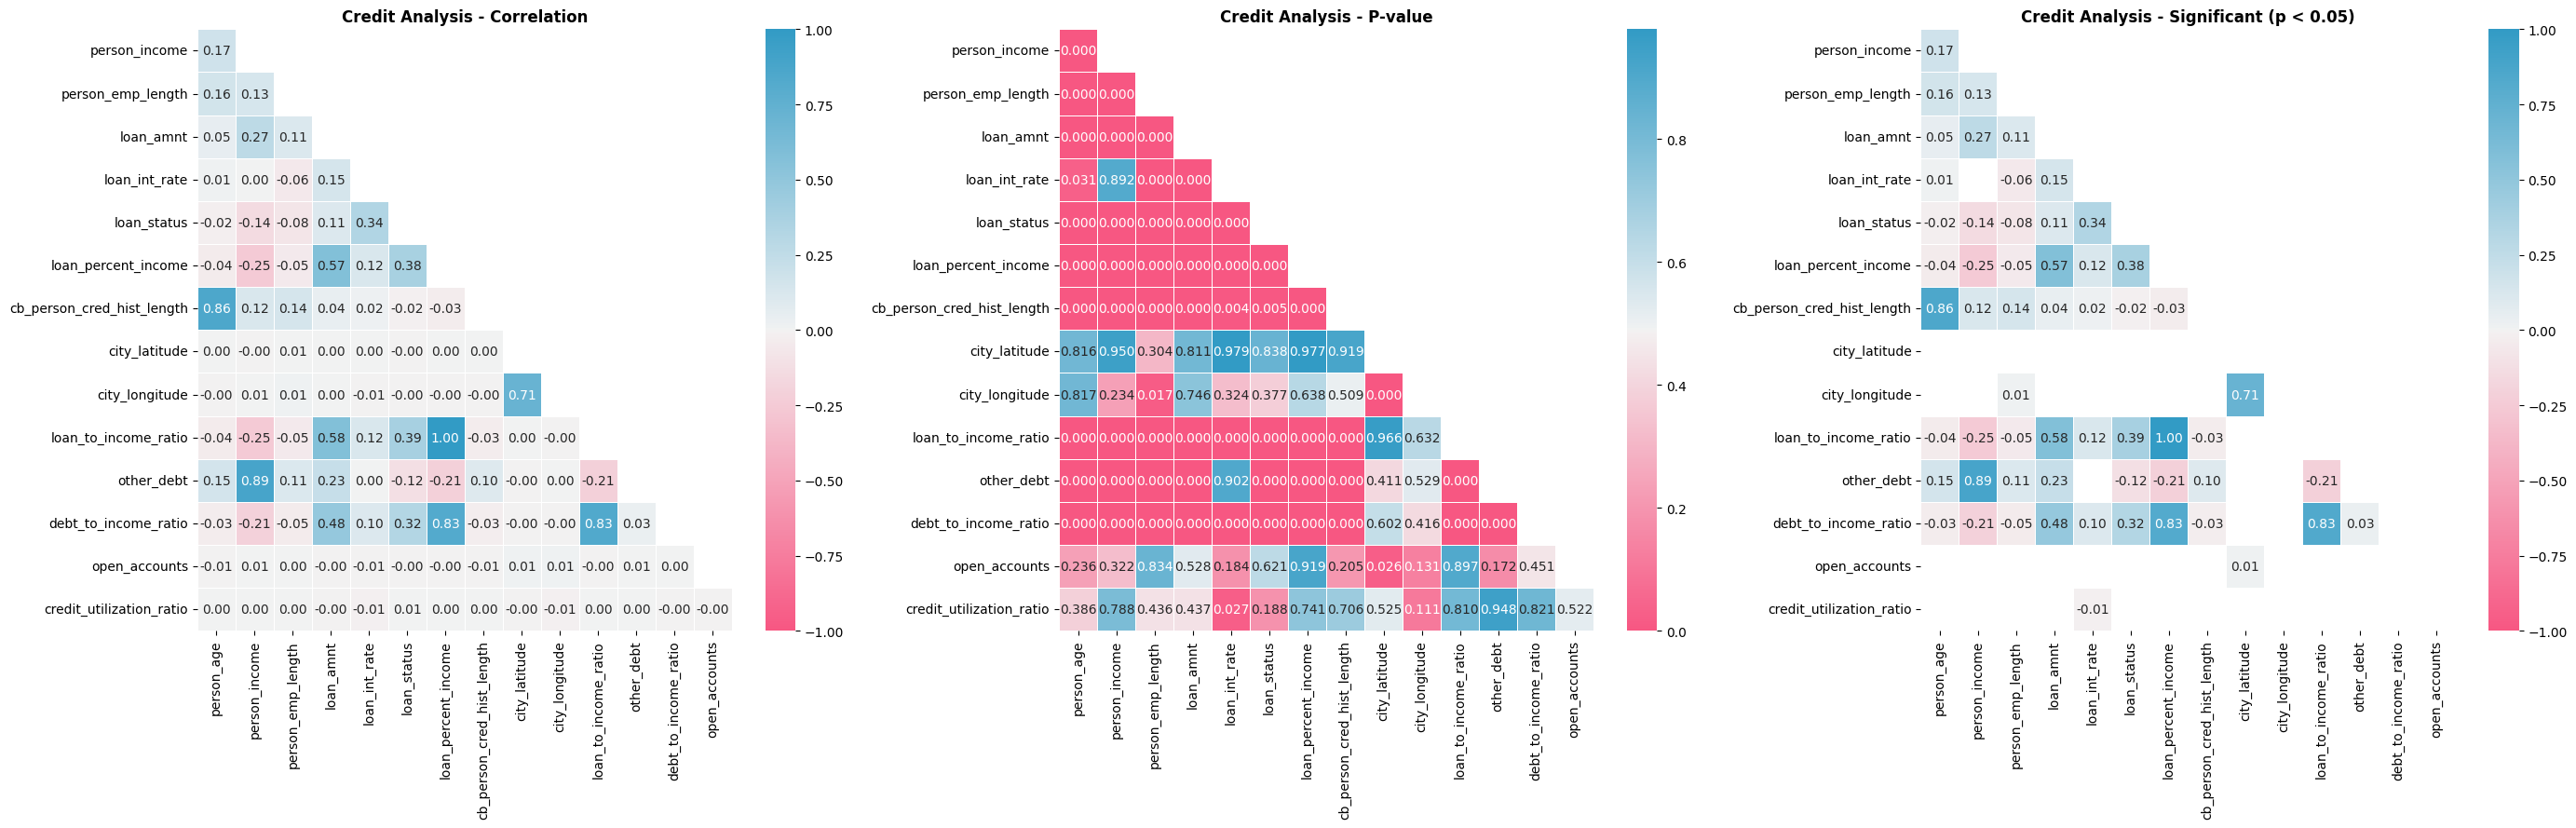

In [14]:
StatUtils.plot_correlation_with_pvalue_single(df_origin=df)

## Non-Linear Checking

In [15]:
mi_df = FeatureUtils.compute_mutual_information(X=df[num_features], y=df[CFG.TARGET_FEATURE])
logger.info("Non-linear checking\n" + mi_df.to_string())

2026-05-06 13:14:40 | INFO     | Non-linear checking
                       feature        mi   mi_norm
0                person_income  0.114016  1.000000
1         loan_to_income_ratio  0.113507  0.995534
2          loan_percent_income  0.084497  0.741100
3                loan_int_rate  0.069724  0.611530
4         debt_to_income_ratio  0.056717  0.497450
5                   other_debt  0.026407  0.231612
6                    loan_amnt  0.009673  0.084835
7            person_emp_length  0.002406  0.021105
8                   person_age  0.001672  0.014667
9   cb_person_cred_hist_length  0.000617  0.005410
10               open_accounts  0.000000  0.000000
11    credit_utilization_ratio  0.000000  0.000000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
">
📊 Integrated Feature Insights (Linear + Non-linear + Statistical)
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>Most features exhibit <b>weak linear correlations</b>, indicating low multicollinearity overall. However, Mutual Information (MI) reveals the presence of <b>non-linear relationships</b> that are not captured by correlation alone.</li>

<li><code>person_income</code> emerges as the <b>most informative feature</b> (highest MI), despite weak linear correlation with the target. This indicates a <b>non-linear relationship with default risk</b>, making it particularly valuable for tree-based models.</li>

<li>Financial burden indicators — <code>loan_to_income_ratio</code>, <code>loan_percent_income</code>, and <code>debt_to_income_ratio</code> — consistently show <b>strong importance in both correlation and MI</b>, confirming them as the <b>primary drivers of credit risk</b>.</li>

<li>The near-perfect correlation between <code>loan_percent_income</code> and <code>loan_to_income_ratio</code> indicates <b>feature redundancy</b>. This is critical for linear models, though tree-based models can still handle both features.</li>

<li><code>loan_int_rate</code> shows <b>moderate MI but weak correlation</b>, suggesting it contributes <b>non-linear predictive signal</b>, likely reflecting embedded risk pricing.</li>

<li><code>other_debt</code> provides <b>limited additional information</b>, as its correlation with <code>person_income</code> indicates a <b>scale effect</b> rather than independent risk contribution.</li>

<li>Demographic and historical features such as <code>person_age</code>, <code>person_emp_length</code>, and <code>cb_person_cred_hist_length</code> exhibit <b>minimal MI</b>, suggesting weak direct predictive value in this dataset.</li>

<li><code>credit_utilization_ratio</code> and <code>open_accounts</code> show <b>near-zero MI and no statistically significant difference across target groups</b>, indicating <b>no meaningful independent predictive signal</b>. Their contribution, if any, is likely through <b>interaction effects</b> in non-linear models.</li>

<li>Overall, the dataset is driven primarily by <b>financial burden (ratio-based) features</b>, while other variables provide either <b>secondary or non-linear contributions</b>.</li>

</ul>

</div>

## Categorical Feature Distributions

In [16]:
def plot_categorical_distribution_across_datasets(df: pd.DataFrame, feature: str) -> None:
    """
    Display distribution summary of a categorical feature with styled table.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    feature : str
        Categorical column to analyze.
    """

    # --- Summarize categorical feature ---
    summary = (
        df[feature]
        .value_counts()
        .rename_axis("Category")
        .reset_index(name="Data_Count")
    )

    # Calculate percentage distribution
    summary["Data_%"] = round(summary["Data_Count"] / summary["Data_Count"].sum() * 100, 2)

    # Ensure Category column is string
    summary["Category"] = summary["Category"].astype(str)

    # Fill NA if any
    summary[["Data_Count", "Data_%"]] = summary[["Data_Count", "Data_%"]].fillna(0)

    # ---- Styling with color gradient ----
    styled_table = (
        summary.style
        .background_gradient(cmap="Blues", subset=["Data_Count"])
        .background_gradient(cmap="Blues", subset=["Data_%"])
        .format({
            "Data_Count": "{:,}",
            "Data_%": "{:.2f}%"
        })
        .set_caption(f"Categorical Feature Distribution: {feature.title()}")
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]}
        ])
    )

    display(styled_table)
    print("*" * 80)

# ----- Run for all categorical features -----
for feature in cat_features:
    plot_categorical_distribution_across_datasets(df=df, feature=feature)

,Category,Data_Count,Data_%
0,RENT,"16,446",50.48%
1,MORTGAGE,"13,444",41.26%
2,OWN,"2,584",7.93%
3,OTHER,107,0.33%


********************************************************************************


,Category,Data_Count,Data_%
0,EDUCATION,"6,453",19.81%
1,MEDICAL,"6,071",18.63%
2,VENTURE,"5,719",17.55%
3,PERSONAL,"5,521",16.95%
4,DEBTCONSOLIDATION,"5,212",16.00%
5,HOMEIMPROVEMENT,"3,605",11.06%


********************************************************************************


,Category,Data_Count,Data_%
0,A,"10,777",33.08%
1,B,"10,451",32.08%
2,C,"6,458",19.82%
3,D,"3,626",11.13%
4,E,964,2.96%
5,F,241,0.74%
6,G,64,0.20%


...

********************************************************************************


,Category,Data_Count,Data_%
0,36,"12,944",39.73%
1,60,"9,923",30.46%
2,24,"6,374",19.56%
3,12,"3,340",10.25%


********************************************************************************


,Category,Data_Count,Data_%
0,0,"19,702",60.47%
1,1,"9,829",30.17%
2,2,"2,586",7.94%
3,3,405,1.24%
4,4,54,0.17%
5,5,4,0.01%
6,6,1,0.00%


********************************************************************************


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Distributions
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>The dataset is dominated by <b>non-homeowners</b>, with most customers either <b>RENT (~50%)</b> or <b>MORTGAGE (~41%)</b>, indicating moderate financial leverage.</li>

<li>Loan purposes are well distributed, with <b>education, medical, and venture</b> loans being the most common (~17–20% each), suggesting diverse borrowing needs.</li>

<li>The majority of loans fall into <b>high-quality grades (A & B ~65%)</b>, indicating that most borrowers are considered low-risk by lending standards.</li>

<li>Most customers have <b>no prior default history (~82%)</b>, reinforcing a generally reliable borrower base.</li>

<li>The dataset is <b>gender-balanced</b> (~50/50), minimizing gender bias in modeling.</li>

<li><b>Single individuals (~50%)</b> dominate the dataset, followed by married customers (~35%), suggesting varying financial responsibilities.</li>

<li>Most borrowers have <b>mid-level education</b>, with <b>High School (~40%)</b> and <b>Bachelor (~35%)</b> being the most common.</li>

<li><b>Full-time employment (~60%)</b> is the dominant employment type, indicating stable income for the majority of customers.</li>

<li>Geographically, the dataset is <b>evenly distributed across countries (UK, USA, Canada)</b>, providing balanced regional representation.</li>

<li>State and city distributions are relatively <b>uniform</b>, suggesting no strong geographic concentration or bias.</li>

<li><b>Loan terms</b> are concentrated around <b>36 months (~40%)</b> and <b>60 months (~30%)</b>, reflecting standard lending durations.</li>

<li>Most customers have <b>no past delinquencies (~60%)</b>, while a smaller portion (~30%) has only <b>1 prior delinquency</b>, indicating generally good repayment behavior.</li>

</ul>

</div>

## Bivariate Analysis

,loan_status,Count,Mean,Median,Std
0,0,25473,27.807129,26.000000,6.369669
1,1,7108,27.474676,26.000000,6.263642


2026-05-06 13:14:40 | INFO     | Checking normality of feature 'person_age' by groups of 'loan_status'...
2026-05-06 13:14:40 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:40 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:40 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:40 | DEBUG    | [loan_status=0] skew=2.7400, kurtosis=21.9279 → Highly skewed, Heavy/light tails
2026-05-06 13:14:40 | DEBUG    | [loan_status=1] skew=1.9864, kurtosis=5.5547 → Highly skewed, Heavy/light tails
2026-05-06 13:14:40 | INFO     | Generating Q–Q plots for visual assessment...


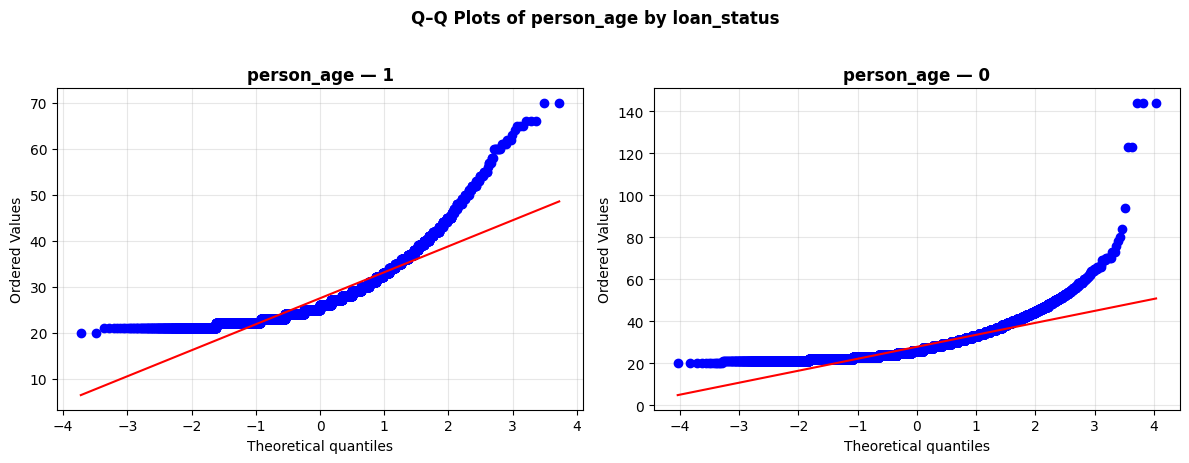

,Feature,Group,Skewness,Kurtosis,Remark
0,person_age,0,2.7400,21.9279,"Highly skewed, Heavy/light tails"
1,person_age,1,1.9864,5.5547,"Highly skewed, Heavy/light tails"


2026-05-06 13:14:40 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:40 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:40 | INFO     | Running Mann–Whitney U Test: 'person_age' by 'loan_status'...
2026-05-06 13:14:40 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:40 | INFO     | U statistic: 86323515.0
2026-05-06 13:14:40 | INFO     | p-value    : 0.000000
2026-05-06 13:14:40 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:40 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:40 | INFO     | Effect size (r): 0.0332
2026-05-06 13:14:40 | INFO     | Effect size interpretation: Negligible
2026-05-06 13:14:40 | INFO     | Cliff's Delta: 0.0465
2026-05-06 13:14:40 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


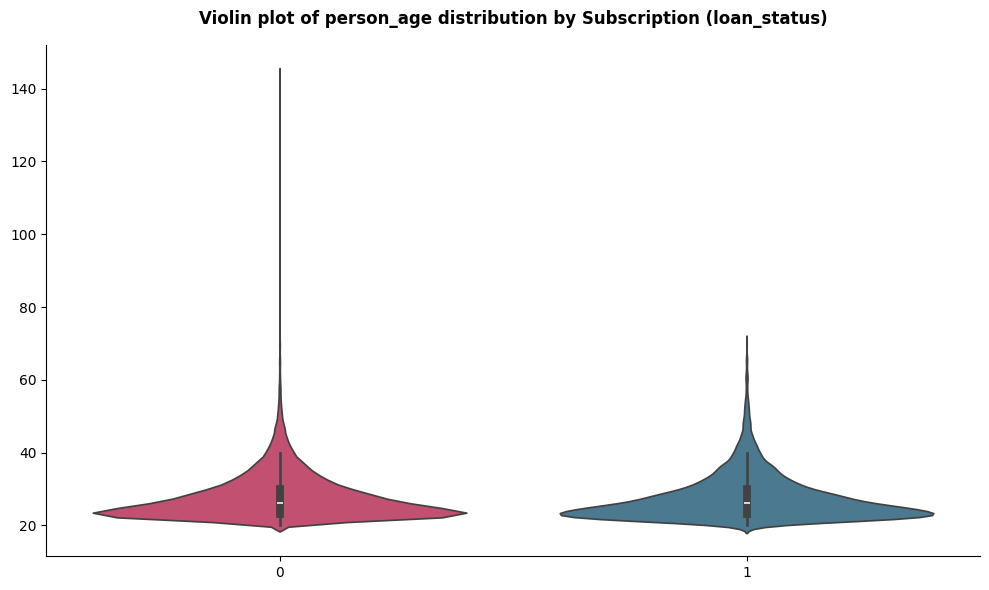

,loan_status,Count,Mean,Median,Std
0,0,25473,70804.361559,60000.000000,66568.802606
1,1,7108,49125.652223,41498.000000,36907.376527


2026-05-06 13:14:41 | INFO     | Checking normality of feature 'person_income' by groups of 'loan_status'...
2026-05-06 13:14:41 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:41 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:41 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:41 | DEBUG    | [loan_status=0] skew=33.5291, kurtosis=2577.7449 → Highly skewed, Heavy/light tails
2026-05-06 13:14:41 | DEBUG    | [loan_status=1] skew=5.4699, kurtosis=62.0899 → Highly skewed, Heavy/light tails
2026-05-06 13:14:41 | INFO     | Generating Q–Q plots for visual assessment...


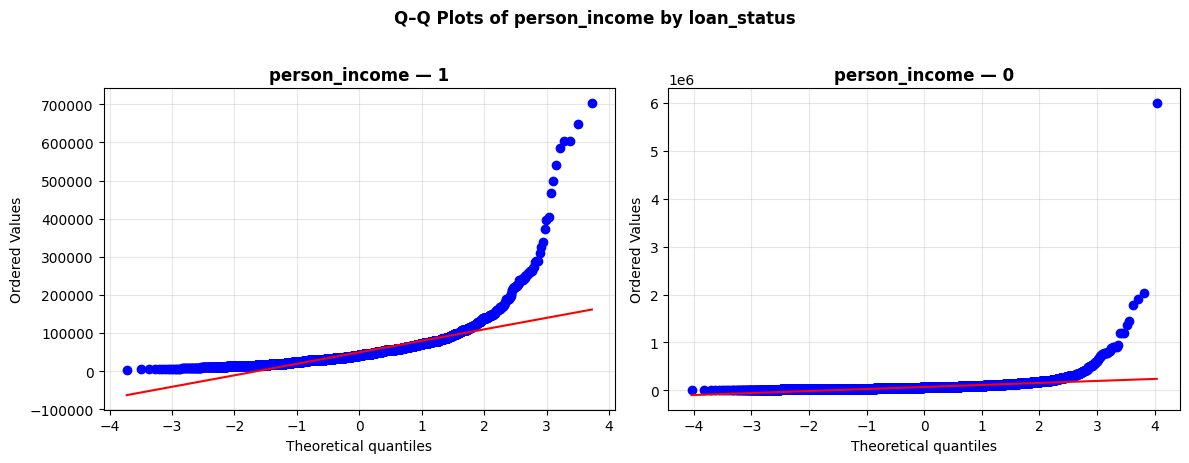

,Feature,Group,Skewness,Kurtosis,Remark
0,person_income,0,33.5291,2577.7449,"Highly skewed, Heavy/light tails"
1,person_income,1,5.4699,62.0899,"Highly skewed, Heavy/light tails"


2026-05-06 13:14:41 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:41 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:41 | INFO     | Running Mann–Whitney U Test: 'person_income' by 'loan_status'...
2026-05-06 13:14:41 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:41 | INFO     | U statistic: 56093141.5
2026-05-06 13:14:41 | INFO     | p-value    : 0.000000
2026-05-06 13:14:41 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:41 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:41 | INFO     | Effect size (r): 0.2721
2026-05-06 13:14:41 | INFO     | Effect size interpretation: Small
2026-05-06 13:14:41 | INFO     | Cliff's Delta: 0.3804
2026-05-06 13:14:41 | INFO     | Effect size (Cliff's Delta) interpretation: Medium


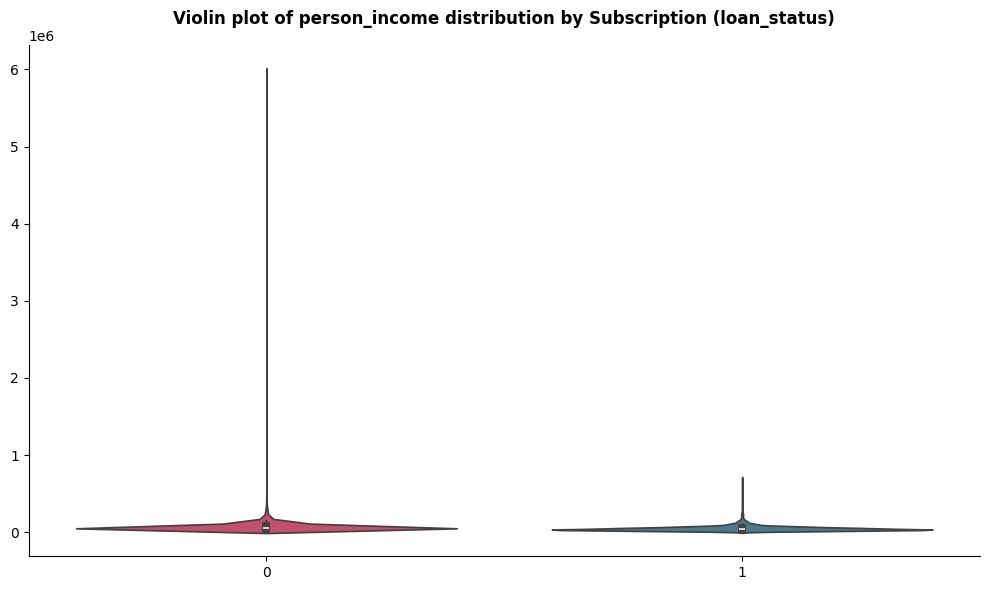

,loan_status,Count,Mean,Median,Std
0,0,24860,4.968745,4.000000,4.129022
1,1,6826,4.137562,3.000000,4.126956


2026-05-06 13:14:41 | INFO     | Checking normality of feature 'person_emp_length' by groups of 'loan_status'...
2026-05-06 13:14:41 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:41 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:41 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:41 | DEBUG    | [loan_status=0] skew=2.0762, kurtosis=28.7722 → Highly skewed, Heavy/light tails
2026-05-06 13:14:41 | DEBUG    | [loan_status=1] skew=4.7058, kurtosis=102.7128 → Highly skewed, Heavy/light tails
2026-05-06 13:14:41 | INFO     | Generating Q–Q plots for visual assessment...


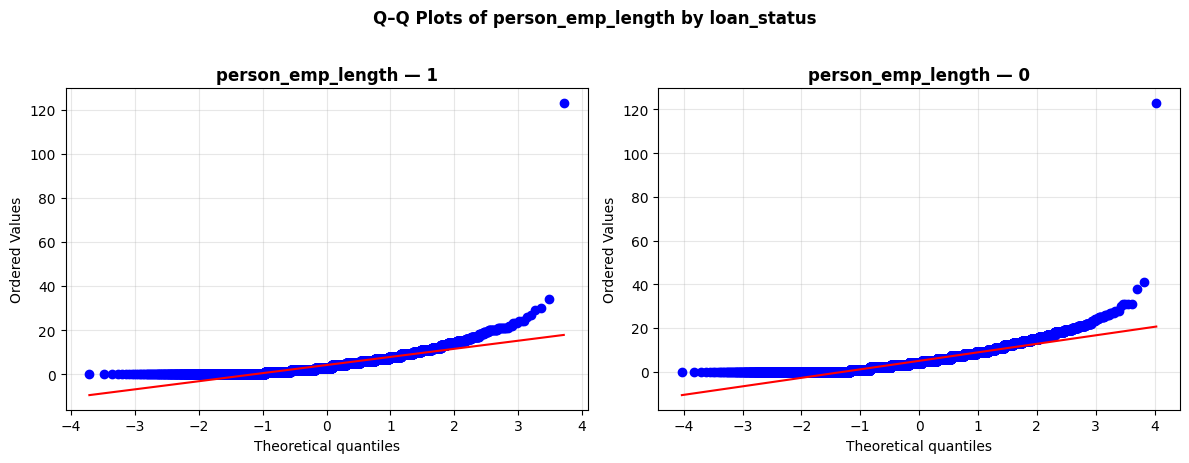

,Feature,Group,Skewness,Kurtosis,Remark
0,person_emp_length,0,2.0762,28.7722,"Highly skewed, Heavy/light tails"
1,person_emp_length,1,4.7058,102.7128,"Highly skewed, Heavy/light tails"


2026-05-06 13:14:42 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:42 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:42 | INFO     | Running Mann–Whitney U Test: 'person_emp_length' by 'loan_status'...
2026-05-06 13:14:42 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:42 | INFO     | U statistic: 73273849.0
2026-05-06 13:14:42 | INFO     | p-value    : 0.000000
2026-05-06 13:14:42 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:42 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:42 | INFO     | Effect size (r): 0.0971
2026-05-06 13:14:42 | INFO     | Effect size interpretation: Negligible
2026-05-06 13:14:42 | INFO     | Cliff's Delta: 0.1364
2026-05-06 13:14:42 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


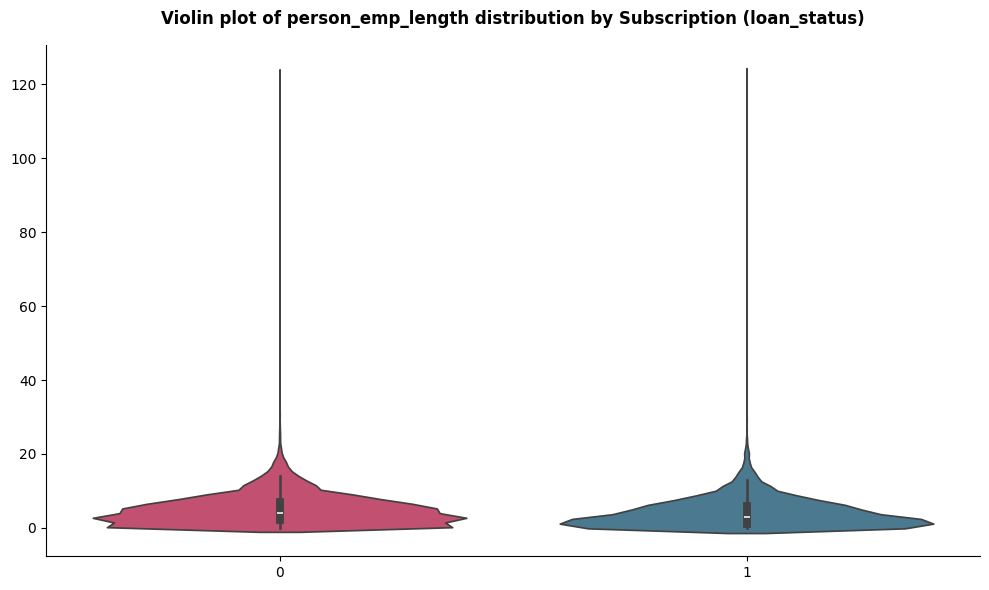

,loan_status,Count,Mean,Median,Std
0,1,7108,10850.502954,9600.000000,7143.345344
1,0,25473,9237.464178,8000.000000,6026.375457


2026-05-06 13:14:42 | INFO     | Checking normality of feature 'loan_amnt' by groups of 'loan_status'...
2026-05-06 13:14:42 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:42 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:42 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:42 | DEBUG    | [loan_status=0] skew=1.2699, kurtosis=1.8433 → Highly skewed, Heavy/light tails
2026-05-06 13:14:42 | DEBUG    | [loan_status=1] skew=0.8989, kurtosis=0.3265 → Moderately skewed, Normal tails
2026-05-06 13:14:42 | INFO     | Generating Q–Q plots for visual assessment...


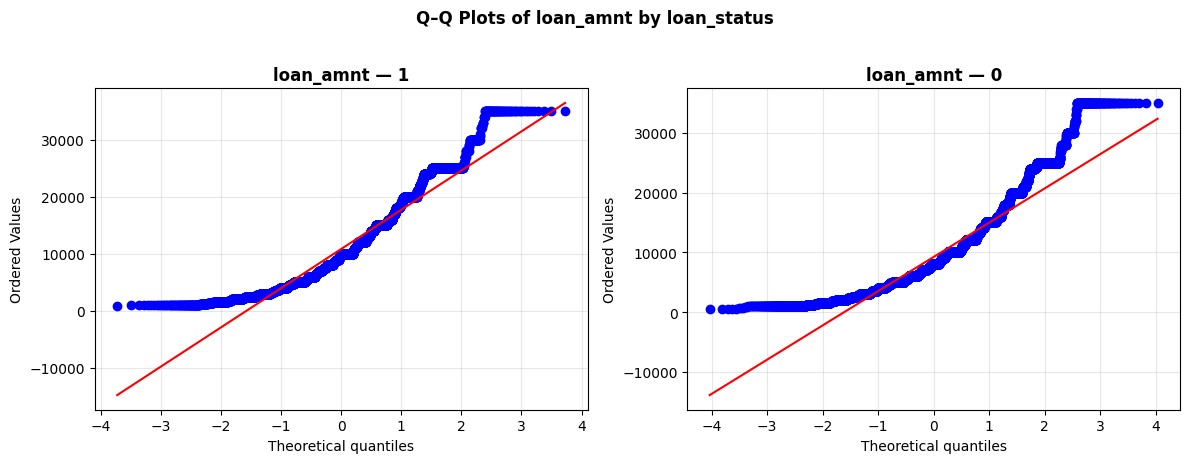

,Feature,Group,Skewness,Kurtosis,Remark
0,loan_amnt,0,1.2699,1.8433,"Highly skewed, Heavy/light tails"
1,loan_amnt,1,0.8989,0.3265,"Moderately skewed, Normal tails"


2026-05-06 13:14:42 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:42 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:42 | INFO     | Running Mann–Whitney U Test: 'loan_amnt' by 'loan_status'...
2026-05-06 13:14:42 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:42 | INFO     | U statistic: 101157877.5
2026-05-06 13:14:42 | INFO     | p-value    : 0.000000
2026-05-06 13:14:43 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:43 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:43 | INFO     | Effect size (r): 0.0840
2026-05-06 13:14:43 | INFO     | Effect size interpretation: Negligible
2026-05-06 13:14:43 | INFO     | Cliff's Delta: -0.1174
2026-05-06 13:14:43 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


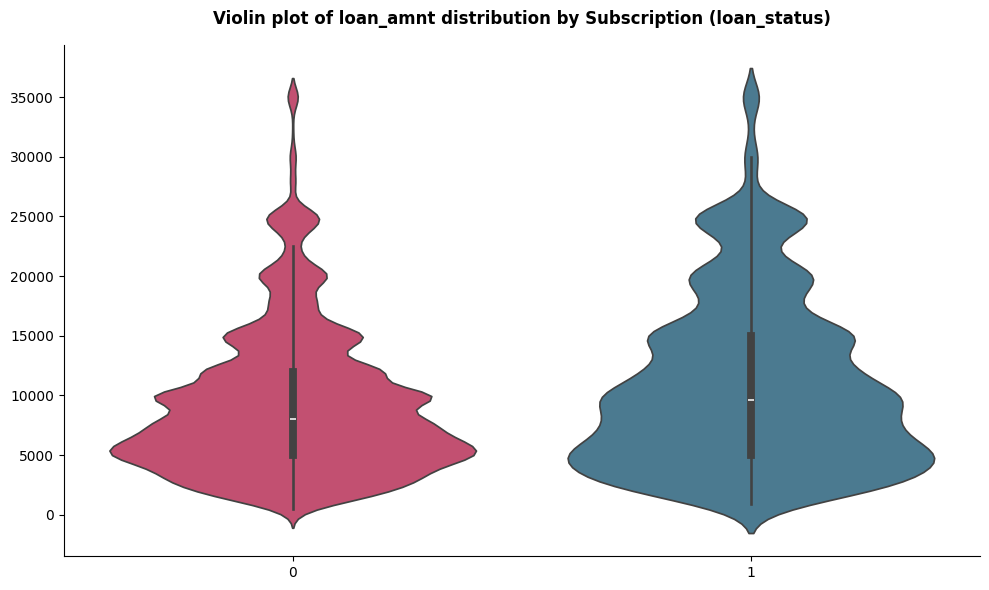

,loan_status,Count,Mean,Median,Std
0,1,6464,13.060207,13.490000,3.293167
1,0,23001,10.435999,10.590000,2.982190


2026-05-06 13:14:43 | INFO     | Checking normality of feature 'loan_int_rate' by groups of 'loan_status'...
2026-05-06 13:14:43 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:43 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:43 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:43 | DEBUG    | [loan_status=0] skew=0.2314, kurtosis=-0.6834 → Approximately symmetric, Normal tails
2026-05-06 13:14:43 | DEBUG    | [loan_status=1] skew=-0.2630, kurtosis=-0.5206 → Approximately symmetric, Normal tails
2026-05-06 13:14:43 | INFO     | Generating Q–Q plots for visual assessment...


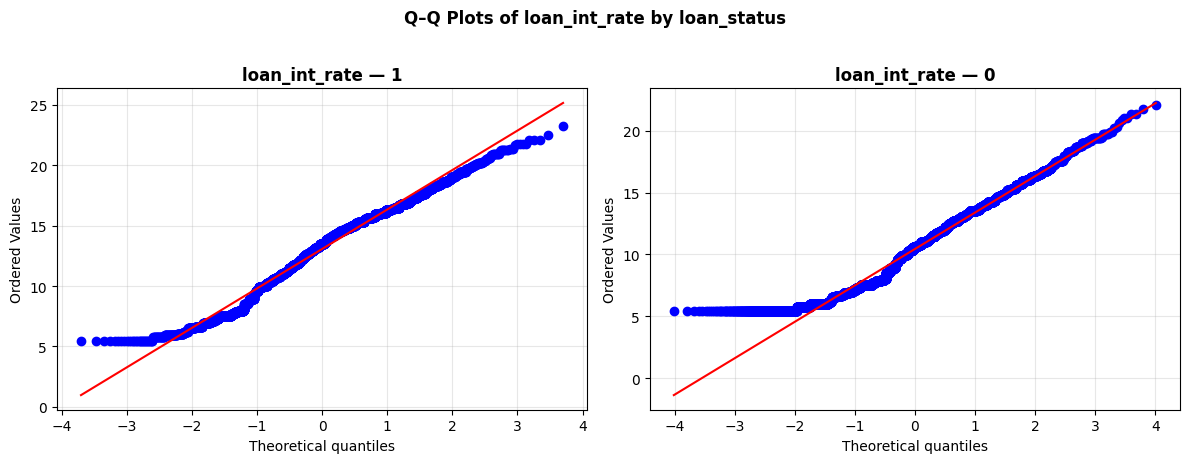

,Feature,Group,Skewness,Kurtosis,Remark
0,loan_int_rate,0,0.2314,-0.6834,"Approximately symmetric, Normal tails"
1,loan_int_rate,1,-0.2630,-0.5206,"Approximately symmetric, Normal tails"


2026-05-06 13:14:43 | INFO     | All groups approximately follow a normal distribution.
2026-05-06 13:14:43 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-05-06 13:14:43 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,66.9627
1,p-value,0.000000
2,Max/Min Variance Ratio,1.22


2026-05-06 13:14:43 | INFO     | Interpretation:
2026-05-06 13:14:43 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-05-06 13:14:43 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-05-06 13:14:43 | INFO     | Running Independent Two-Sample T-Test: 'loan_int_rate' ~ 'loan_status'
2026-05-06 13:14:43 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:43 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-05-06 13:14:44 | INFO     | Comparing groups: '1' vs '0'
2026-05-06 13:14:44 | INFO     | p-value: 0.000000
2026-05-06 13:14:44 | INFO     | Cohen's d: 0.835
2026-05-06 13:14:44 | DEBUG    | t-statistic: 57.757
2026-05-06 13:14:44 | DEBUG    | Group means → 1: 13.060, 0: 10.436
2026-05-06 13:14:44 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:44 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:

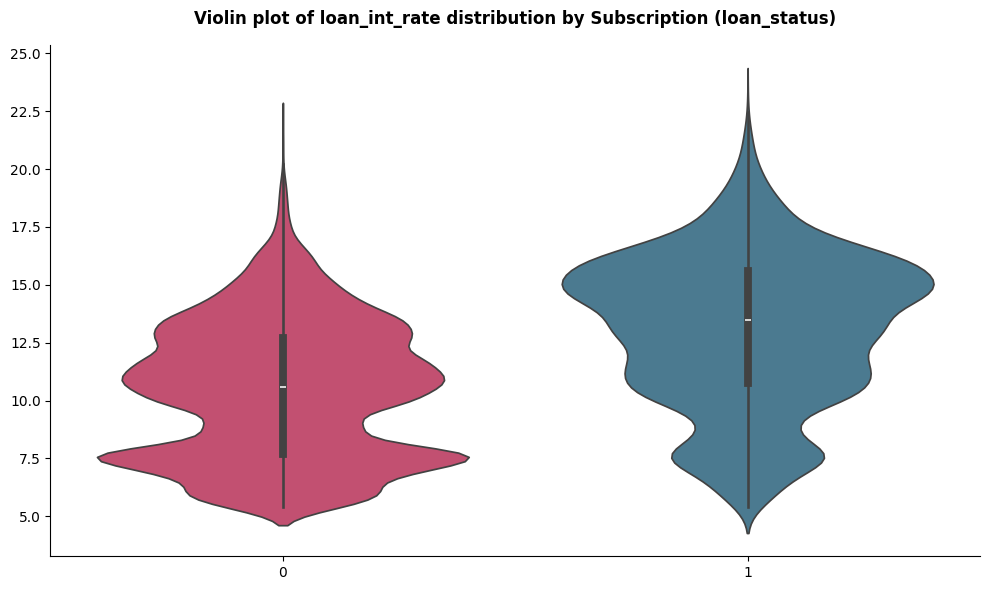

,loan_status,Count,Mean,Median,Std
0,1,7108,0.246889,0.240000,0.132148
1,0,25473,0.148805,0.130000,0.087252


2026-05-06 13:14:44 | INFO     | Checking normality of feature 'loan_percent_income' by groups of 'loan_status'...
2026-05-06 13:14:44 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:44 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:44 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:44 | DEBUG    | [loan_status=0] skew=1.0254, kurtosis=1.6735 → Highly skewed, Heavy/light tails
2026-05-06 13:14:44 | DEBUG    | [loan_status=1] skew=0.3550, kurtosis=-0.4501 → Approximately symmetric, Normal tails
2026-05-06 13:14:44 | INFO     | Generating Q–Q plots for visual assessment...


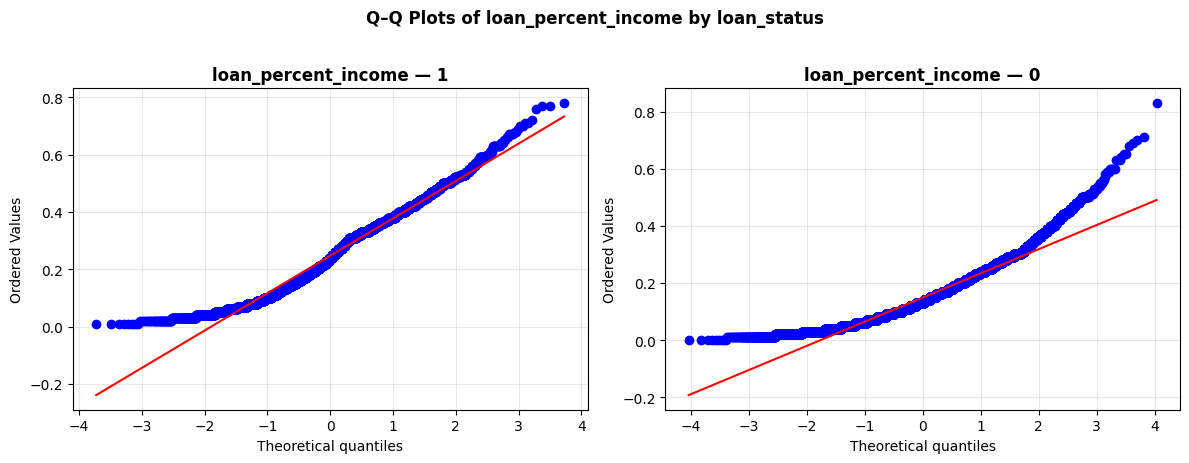

,Feature,Group,Skewness,Kurtosis,Remark
0,loan_percent_income,0,1.0254,1.6735,"Highly skewed, Heavy/light tails"
1,loan_percent_income,1,0.3550,-0.4501,"Approximately symmetric, Normal tails"


2026-05-06 13:14:44 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:44 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:44 | INFO     | Running Mann–Whitney U Test: 'loan_percent_income' by 'loan_status'...
2026-05-06 13:14:44 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:44 | INFO     | U statistic: 130515398.0
2026-05-06 13:14:44 | INFO     | p-value    : 0.000000
2026-05-06 13:14:44 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:44 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:44 | INFO     | Effect size (r): 0.3159
2026-05-06 13:14:44 | INFO     | Effect size interpretation: Medium
2026-05-06 13:14:44 | INFO     | Cliff's Delta: -0.4417
2026-05-06 13:14:44 | INFO     | Effect size (Cliff's Delta) interpretation: Medium


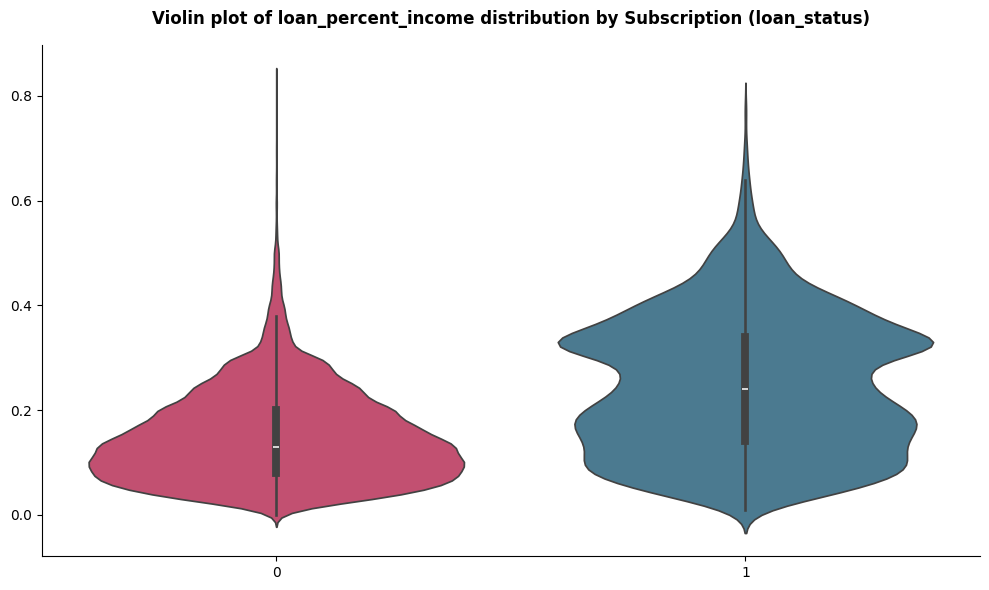

,loan_status,Count,Mean,Median,Std
0,1,7108,0.248750,0.239234,0.132125
1,0,25473,0.148733,0.133333,0.087202


2026-05-06 13:14:45 | INFO     | Checking normality of feature 'loan_to_income_ratio' by groups of 'loan_status'...
2026-05-06 13:14:45 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:45 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:45 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:45 | DEBUG    | [loan_status=0] skew=1.0286, kurtosis=1.6811 → Highly skewed, Heavy/light tails
2026-05-06 13:14:45 | DEBUG    | [loan_status=1] skew=0.3436, kurtosis=-0.4629 → Approximately symmetric, Normal tails
2026-05-06 13:14:45 | INFO     | Generating Q–Q plots for visual assessment...


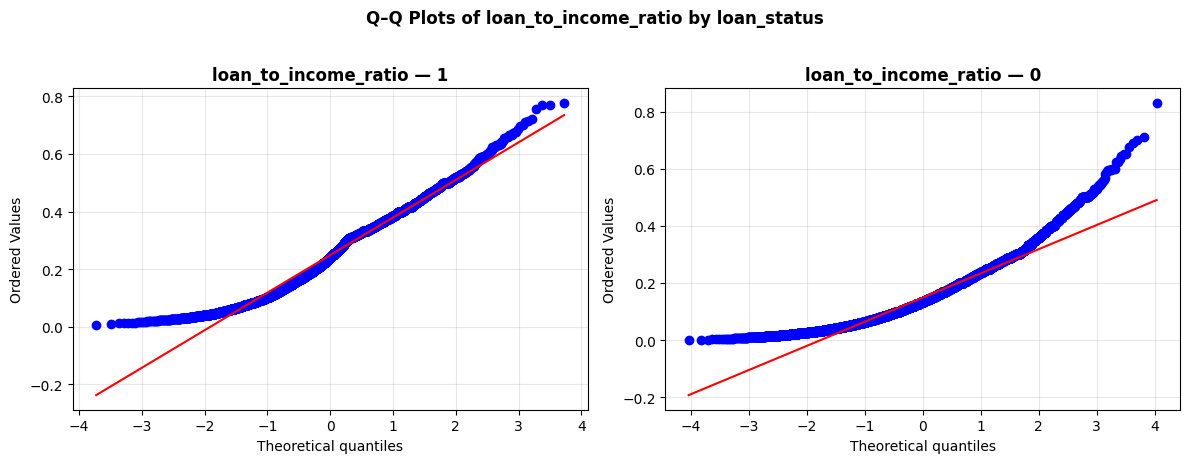

,Feature,Group,Skewness,Kurtosis,Remark
0,loan_to_income_ratio,0,1.0286,1.6811,"Highly skewed, Heavy/light tails"
1,loan_to_income_ratio,1,0.3436,-0.4629,"Approximately symmetric, Normal tails"


2026-05-06 13:14:45 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:45 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:45 | INFO     | Running Mann–Whitney U Test: 'loan_to_income_ratio' by 'loan_status'...
2026-05-06 13:14:45 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:45 | INFO     | U statistic: 131319126.0
2026-05-06 13:14:45 | INFO     | p-value    : 0.000000
2026-05-06 13:14:45 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:45 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:45 | INFO     | Effect size (r): 0.3223
2026-05-06 13:14:45 | INFO     | Effect size interpretation: Medium
2026-05-06 13:14:45 | INFO     | Cliff's Delta: -0.4505
2026-05-06 13:14:45 | INFO     | Effect size (Cliff's Delta) interpretation: Medium


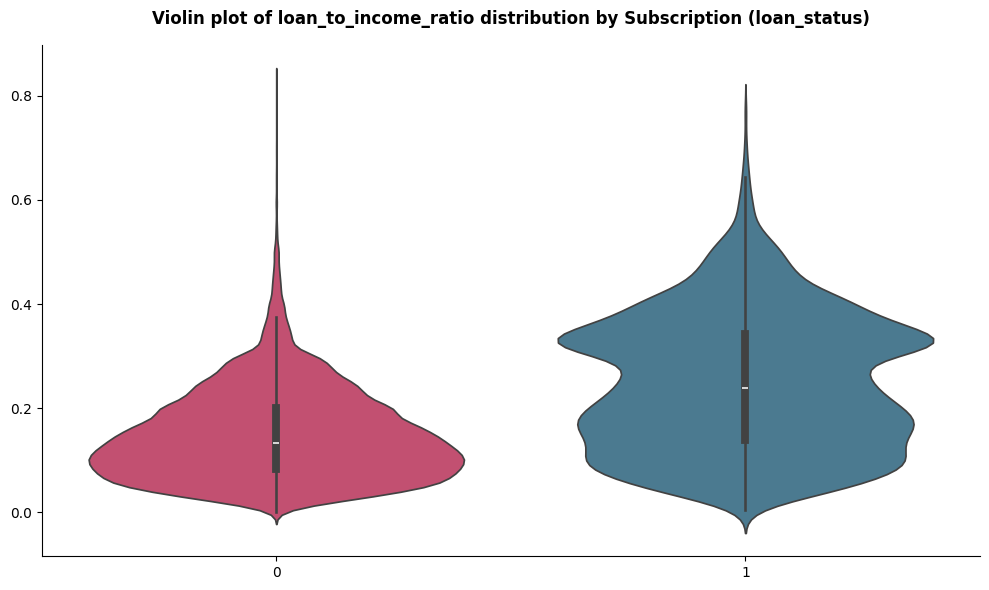

,loan_status,Count,Mean,Median,Std
0,0,25473,5.837475,4.000000,4.040900
1,1,7108,5.685003,4.000000,4.103208


2026-05-06 13:14:45 | INFO     | Checking normality of feature 'cb_person_cred_hist_length' by groups of 'loan_status'...
2026-05-06 13:14:45 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:45 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:45 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:45 | DEBUG    | [loan_status=0] skew=1.6173, kurtosis=3.4796 → Highly skewed, Heavy/light tails
2026-05-06 13:14:45 | DEBUG    | [loan_status=1] skew=1.8187, kurtosis=4.5456 → Highly skewed, Heavy/light tails
2026-05-06 13:14:45 | INFO     | Generating Q–Q plots for visual assessment...


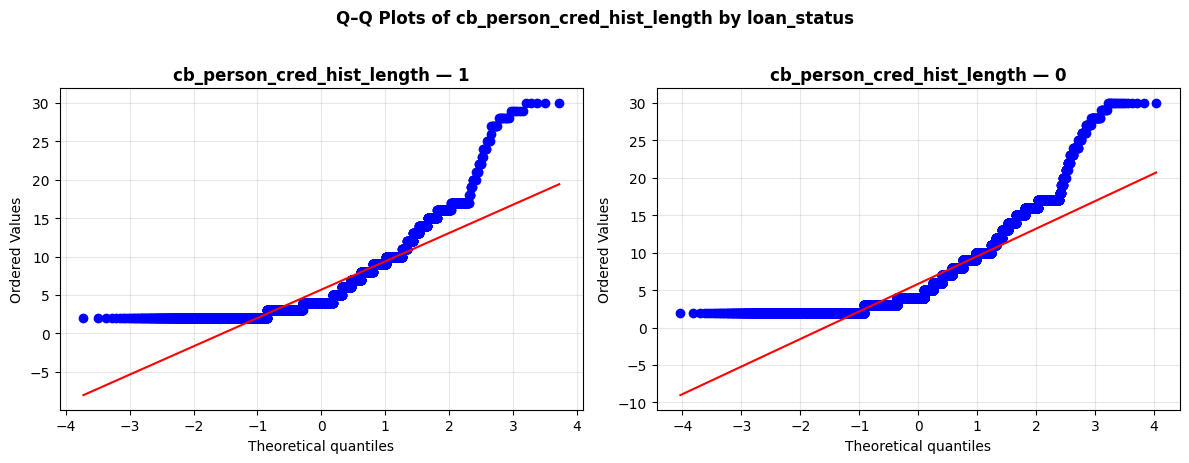

,Feature,Group,Skewness,Kurtosis,Remark
0,cb_person_cred_hist_length,0,1.6173,3.4796,"Highly skewed, Heavy/light tails"
1,cb_person_cred_hist_length,1,1.8187,4.5456,"Highly skewed, Heavy/light tails"


2026-05-06 13:14:46 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:46 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:46 | INFO     | Running Mann–Whitney U Test: 'cb_person_cred_hist_length' by 'loan_status'...
2026-05-06 13:14:46 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:46 | INFO     | U statistic: 87550955.5
2026-05-06 13:14:46 | INFO     | p-value    : 0.000018
2026-05-06 13:14:46 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:46 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:46 | INFO     | Effect size (r): 0.0235
2026-05-06 13:14:46 | INFO     | Effect size interpretation: Negligible
2026-05-06 13:14:46 | INFO     | Cliff's Delta: 0.0329
2026-05-06 13:14:46 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


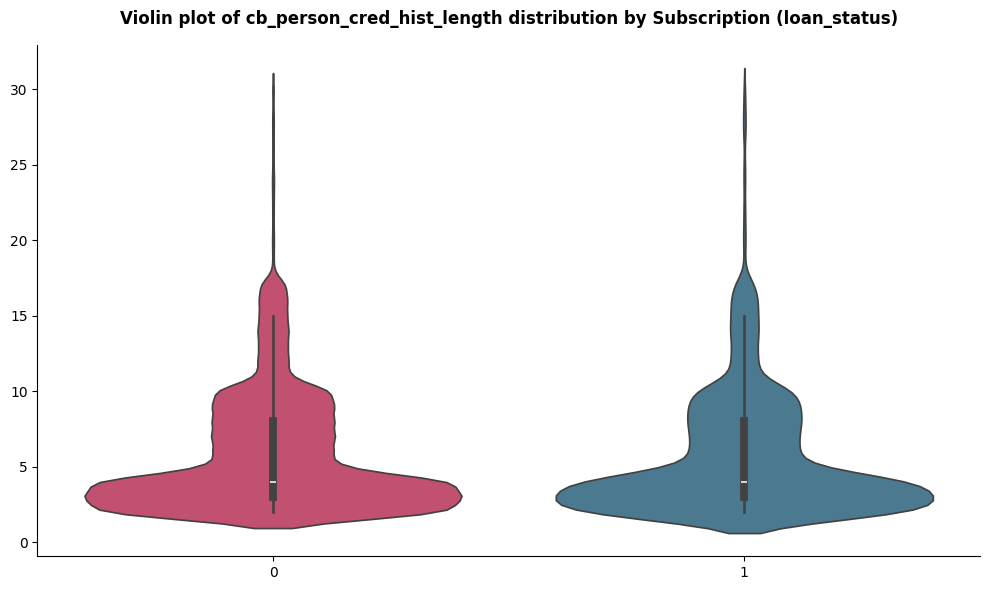

,loan_status,Count,Mean,Median,Std
0,0,25473,12384.334961,9727.985352,14022.312500
1,1,7108,8642.306641,6692.345703,8145.106934


2026-05-06 13:14:46 | INFO     | Checking normality of feature 'other_debt' by groups of 'loan_status'...
2026-05-06 13:14:46 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:46 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:46 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:46 | DEBUG    | [loan_status=0] skew=28.9781, kurtosis=2042.5092 → Highly skewed, Heavy/light tails
2026-05-06 13:14:46 | DEBUG    | [loan_status=1] skew=5.9520, kurtosis=79.7972 → Highly skewed, Heavy/light tails
2026-05-06 13:14:46 | INFO     | Generating Q–Q plots for visual assessment...


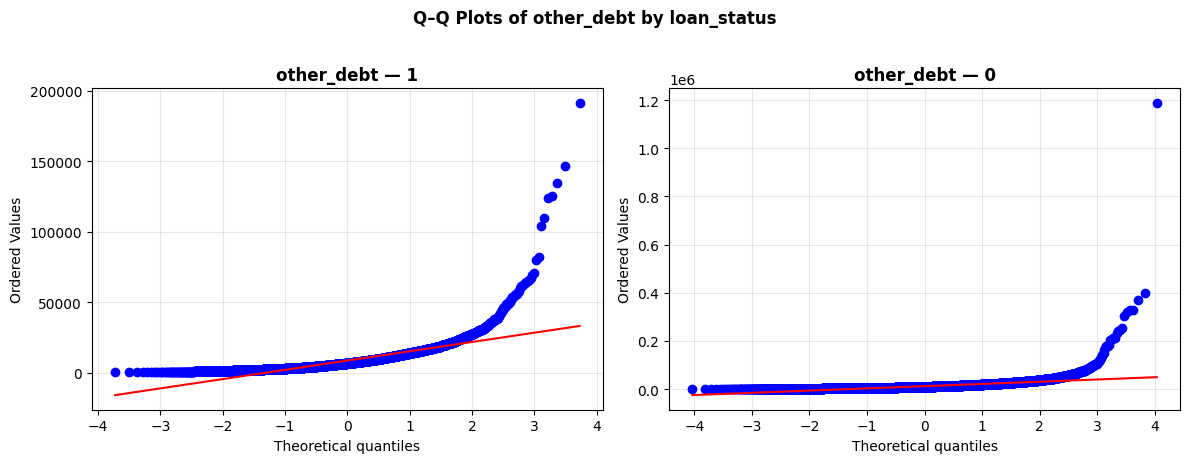

,Feature,Group,Skewness,Kurtosis,Remark
0,other_debt,0,28.9781,2042.5092,"Highly skewed, Heavy/light tails"
1,other_debt,1,5.9520,79.7972,"Highly skewed, Heavy/light tails"


2026-05-06 13:14:47 | WARNING  | Normality assumption violated in at least one group.
2026-05-06 13:14:47 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-05-06 13:14:47 | INFO     | Running Mann–Whitney U Test: 'other_debt' by 'loan_status'...
2026-05-06 13:14:47 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:47 | INFO     | U statistic: 64740966.0
2026-05-06 13:14:47 | INFO     | p-value    : 0.000000
2026-05-06 13:14:47 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:47 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-06 13:14:47 | INFO     | Effect size (r): 0.2038
2026-05-06 13:14:47 | INFO     | Effect size interpretation: Small
2026-05-06 13:14:47 | INFO     | Cliff's Delta: 0.2849
2026-05-06 13:14:47 | INFO     | Effect size (Cliff's Delta) interpretation: Small


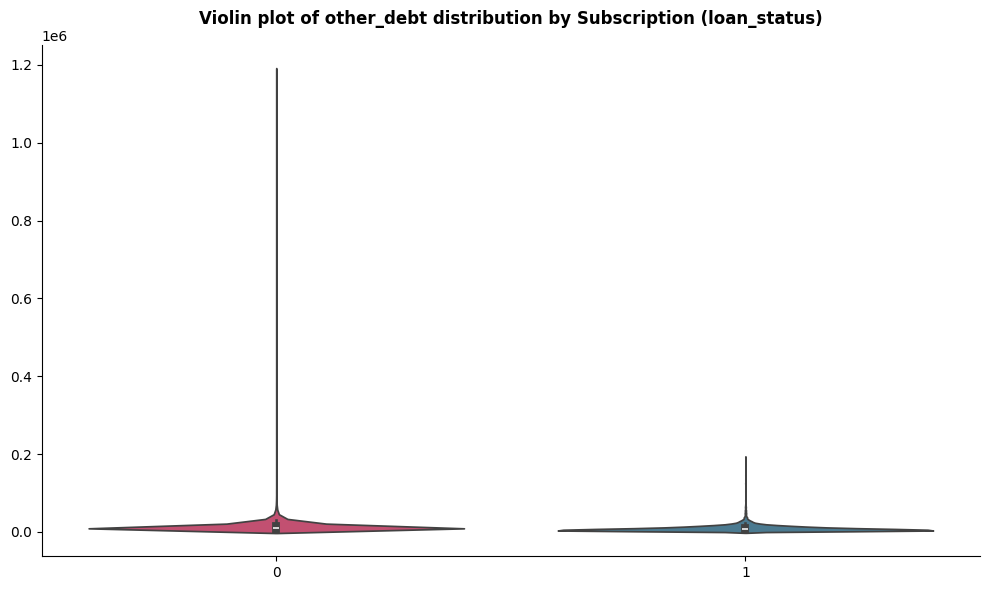

,loan_status,Count,Mean,Median,Std
0,1,7108,0.423967,0.417944,0.150899
1,0,25473,0.323231,0.317628,0.113366


2026-05-06 13:14:47 | INFO     | Checking normality of feature 'debt_to_income_ratio' by groups of 'loan_status'...
2026-05-06 13:14:47 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:47 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:47 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:47 | DEBUG    | [loan_status=0] skew=0.4725, kurtosis=0.3764 → Approximately symmetric, Normal tails
2026-05-06 13:14:47 | DEBUG    | [loan_status=1] skew=0.2597, kurtosis=-0.2494 → Approximately symmetric, Normal tails
2026-05-06 13:14:47 | INFO     | Generating Q–Q plots for visual assessment...


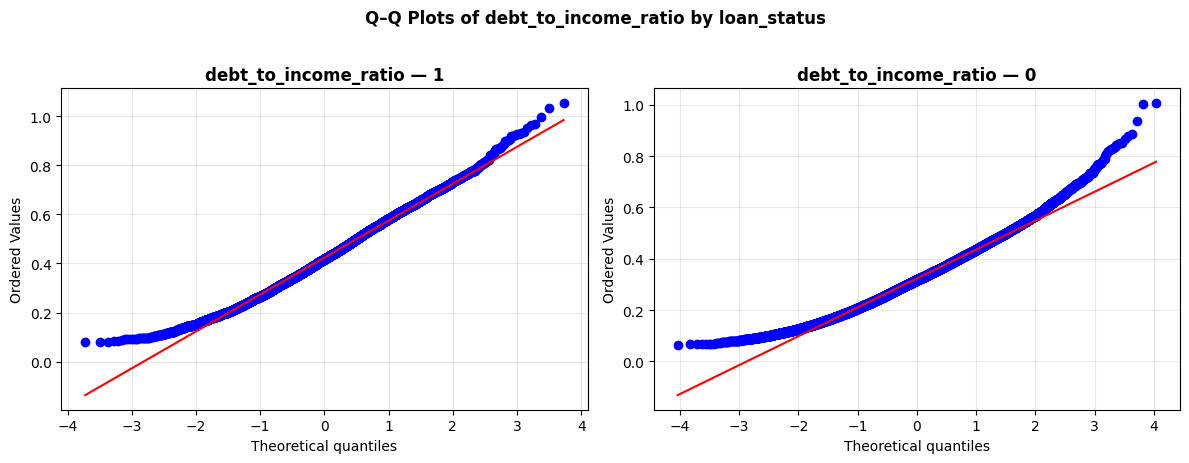

,Feature,Group,Skewness,Kurtosis,Remark
0,debt_to_income_ratio,0,0.4725,0.3764,"Approximately symmetric, Normal tails"
1,debt_to_income_ratio,1,0.2597,-0.2494,"Approximately symmetric, Normal tails"


2026-05-06 13:14:47 | INFO     | All groups approximately follow a normal distribution.
2026-05-06 13:14:47 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-05-06 13:14:47 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,1078.2762
1,p-value,0.000000
2,Max/Min Variance Ratio,1.77


2026-05-06 13:14:47 | INFO     | Interpretation:
2026-05-06 13:14:47 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-05-06 13:14:47 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-05-06 13:14:47 | INFO     | Running Independent Two-Sample T-Test: 'debt_to_income_ratio' ~ 'loan_status'
2026-05-06 13:14:47 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:47 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-05-06 13:14:47 | INFO     | Comparing groups: '1' vs '0'
2026-05-06 13:14:47 | INFO     | p-value: 0.000000
2026-05-06 13:14:47 | INFO     | Cohen's d: 0.755
2026-05-06 13:14:47 | DEBUG    | t-statistic: 52.313
2026-05-06 13:14:47 | DEBUG    | Group means → 1: 0.424, 0: 0.323
2026-05-06 13:14:47 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-05-06 13:14:47 | INFO     | Conclusion: Significant difference between the two groups.
2026-05-0

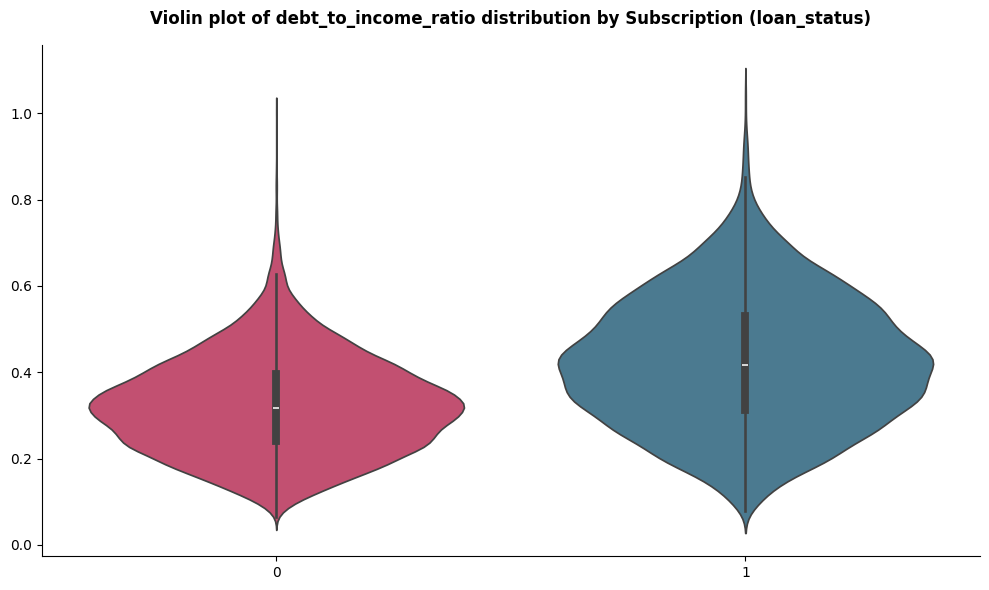

,loan_status,Count,Mean,Median,Std
0,0,25473,8.048286,8.000000,4.331499
1,1,7108,8.019555,8.000000,4.316067


2026-05-06 13:14:48 | INFO     | Checking normality of feature 'open_accounts' by groups of 'loan_status'...
2026-05-06 13:14:48 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:48 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:48 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:48 | DEBUG    | [loan_status=0] skew=-0.0107, kurtosis=-1.2178 → Approximately symmetric, Normal tails
2026-05-06 13:14:48 | DEBUG    | [loan_status=1] skew=0.0058, kurtosis=-1.1989 → Approximately symmetric, Normal tails
2026-05-06 13:14:48 | INFO     | Generating Q–Q plots for visual assessment...


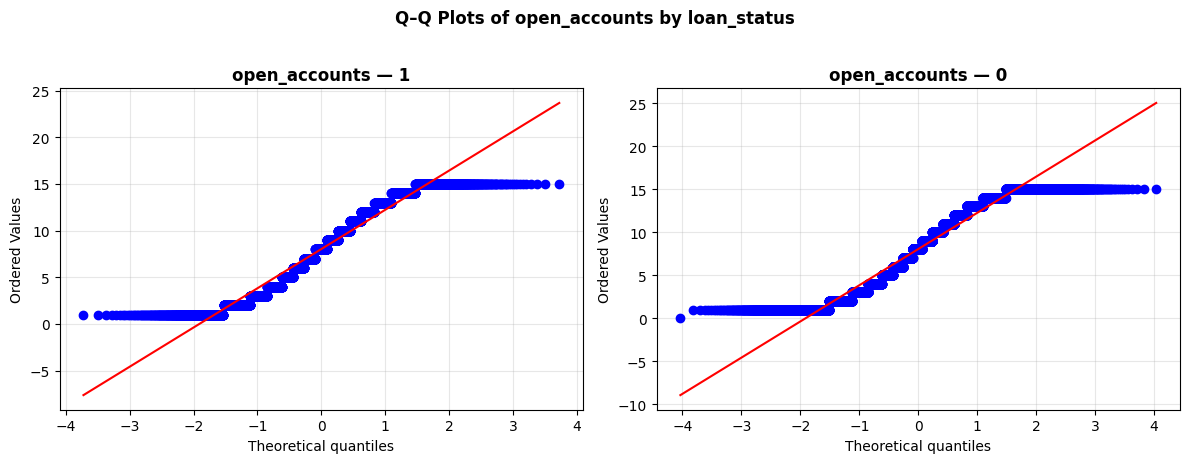

,Feature,Group,Skewness,Kurtosis,Remark
0,open_accounts,0,-0.0107,-1.2178,"Approximately symmetric, Normal tails"
1,open_accounts,1,0.0058,-1.1989,"Approximately symmetric, Normal tails"


2026-05-06 13:14:48 | INFO     | All groups approximately follow a normal distribution.
2026-05-06 13:14:48 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-05-06 13:14:48 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,1.6981
1,p-value,0.192540
2,Max/Min Variance Ratio,1.01


2026-05-06 13:14:48 | INFO     | Interpretation:
2026-05-06 13:14:48 | INFO     | - Status: Variances are statistically and practically homogeneous.
2026-05-06 13:14:48 | INFO     | - Recommendation: Use One-Way ANOVA or Independent Two-Sample T-Test.
2026-05-06 13:14:48 | INFO     | Running Independent Two-Sample T-Test: 'open_accounts' ~ 'loan_status'
2026-05-06 13:14:48 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:48 | DEBUG    | Test Type: Student’s T-Test (equal variances)
2026-05-06 13:14:48 | INFO     | Comparing groups: '1' vs '0'
2026-05-06 13:14:48 | INFO     | p-value: 0.620703
2026-05-06 13:14:48 | INFO     | Cohen's d: -0.007
2026-05-06 13:14:48 | DEBUG    | t-statistic: -0.495
2026-05-06 13:14:48 | DEBUG    | Group means → 1: 8.020, 0: 8.048
2026-05-06 13:14:48 | WARNING  | Result: p-value > 0.05 → Fail to reject H0
2026-05-06 13:14:48 | WARNING  | Conclusion: No statistically significant difference detected.


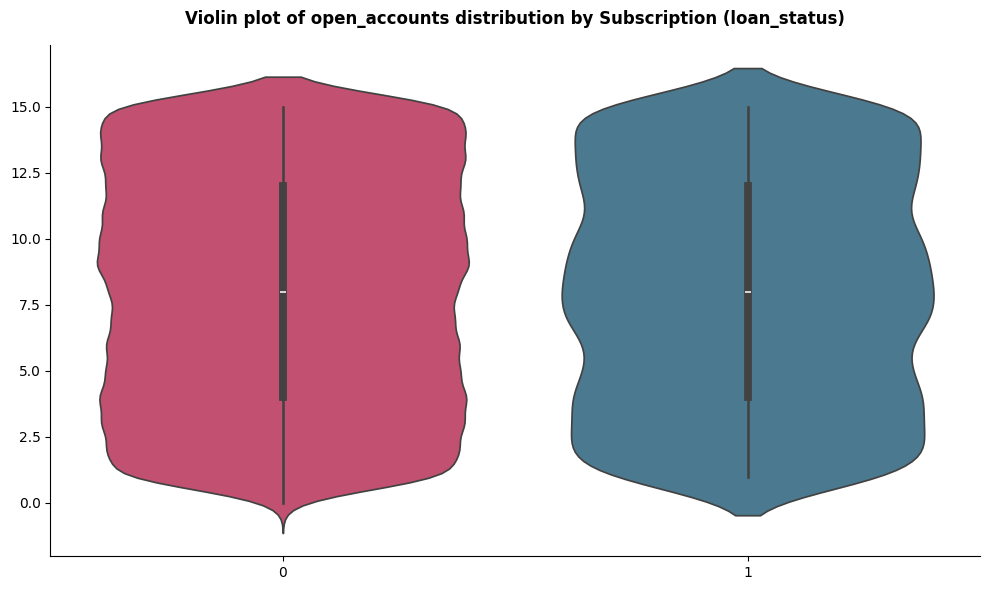

,loan_status,Count,Mean,Median,Std
0,1,7108,0.503465,0.504247,0.261262
1,0,25473,0.498885,0.499371,0.259041


2026-05-06 13:14:49 | INFO     | Checking normality of feature 'credit_utilization_ratio' by groups of 'loan_status'...
2026-05-06 13:14:49 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-05-06 13:14:49 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:49 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-05-06 13:14:49 | DEBUG    | [loan_status=0] skew=0.0037, kurtosis=-1.1941 → Approximately symmetric, Normal tails
2026-05-06 13:14:49 | DEBUG    | [loan_status=1] skew=-0.0142, kurtosis=-1.2148 → Approximately symmetric, Normal tails
2026-05-06 13:14:49 | INFO     | Generating Q–Q plots for visual assessment...


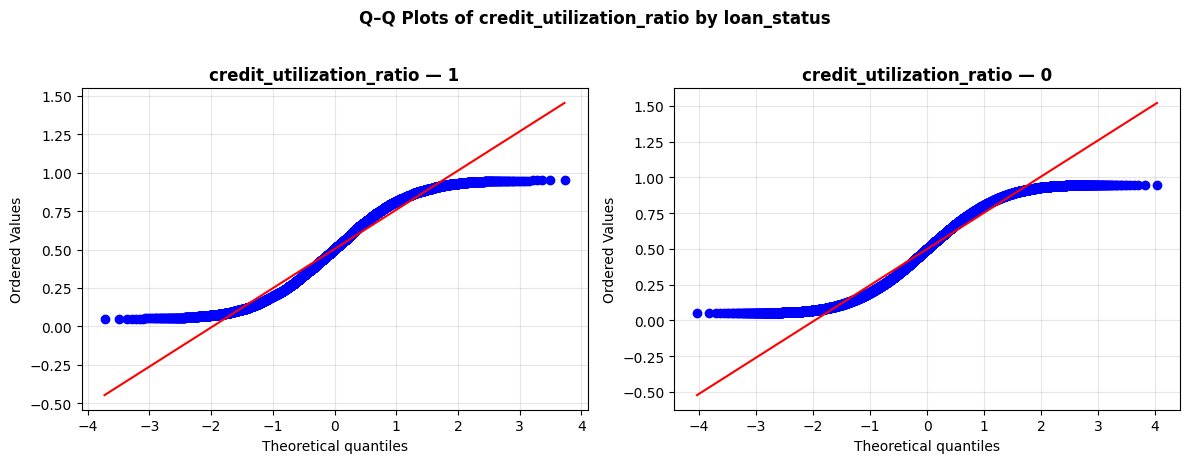

,Feature,Group,Skewness,Kurtosis,Remark
0,credit_utilization_ratio,0,0.0037,-1.1941,"Approximately symmetric, Normal tails"
1,credit_utilization_ratio,1,-0.0142,-1.2148,"Approximately symmetric, Normal tails"


2026-05-06 13:14:49 | INFO     | All groups approximately follow a normal distribution.
2026-05-06 13:14:49 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-05-06 13:14:49 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,1.5282
1,p-value,0.216395
2,Max/Min Variance Ratio,1.02


2026-05-06 13:14:49 | INFO     | Interpretation:
2026-05-06 13:14:49 | INFO     | - Status: Variances are statistically and practically homogeneous.
2026-05-06 13:14:49 | INFO     | - Recommendation: Use One-Way ANOVA or Independent Two-Sample T-Test.
2026-05-06 13:14:49 | INFO     | Running Independent Two-Sample T-Test: 'credit_utilization_ratio' ~ 'loan_status'
2026-05-06 13:14:49 | DEBUG    | Number of groups detected: 2
2026-05-06 13:14:49 | DEBUG    | Test Type: Student’s T-Test (equal variances)
2026-05-06 13:14:49 | INFO     | Comparing groups: '1' vs '0'
2026-05-06 13:14:49 | INFO     | p-value: 0.188288
2026-05-06 13:14:49 | INFO     | Cohen's d: 0.018
2026-05-06 13:14:49 | DEBUG    | t-statistic: 1.316
2026-05-06 13:14:49 | DEBUG    | Group means → 1: 0.503, 0: 0.499
2026-05-06 13:14:49 | WARNING  | Result: p-value > 0.05 → Fail to reject H0
2026-05-06 13:14:49 | WARNING  | Conclusion: No statistically significant difference detected.


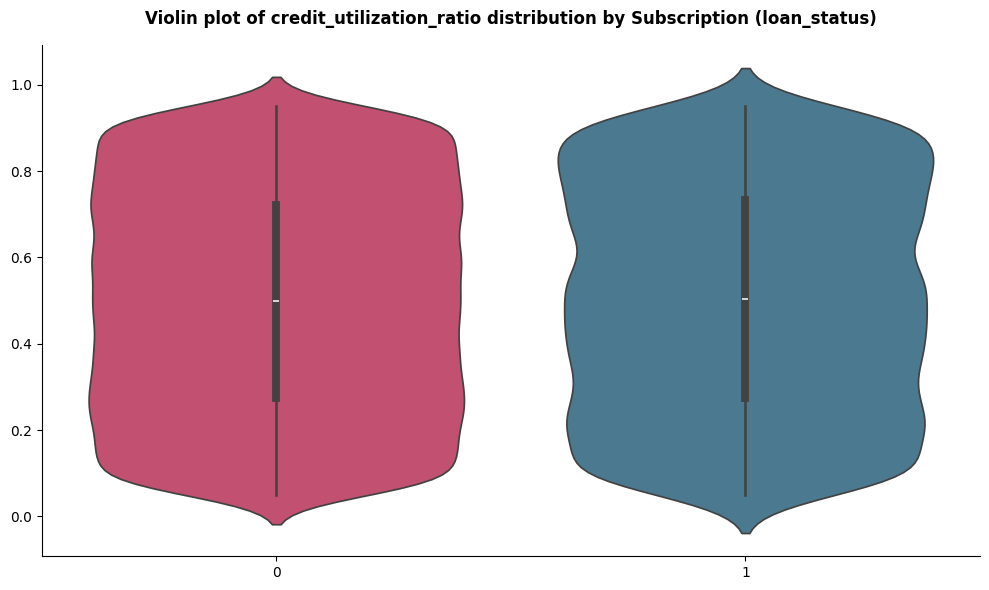

In [17]:
for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature.title()} by Loan Status</b></h2>"))
    StatUtils.analyze_numeric_feature_by_target(feature=feature, df=df, target_feature=CFG.TARGET_FEATURE, logger=logger)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Feature-Level Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Person_Age</b>: Age is nearly identical between the two groups (mean ~27), so it is <b>not a strong discriminator</b> for default.  
Although statistically significant (p-value ≈ 0), the <b>effect size is very small → negligible practical impact</b>.</li>

<li><b>Person_Income</b>: Clear difference — <b>Non-default customers have significantly higher income (~70k vs ~49k)</b> → income is an <b>important feature</b>.</li>

<li><b>Person_Emp_Length</b>: Slight difference — <b>Non-default customers have longer employment (~5 years vs ~4 years)</b> → weak signal.  
Despite statistical significance, the <b>effect size is negligible</b> and the distribution is highly skewed → low practical impact.</li>

<li><b>Loan_Amnt</b>: Loan amount is <b>higher in the Default group (~10.8k vs ~9.2k)</b> → larger loans are associated with higher risk.</li>

<li><b>Loan_Int_Rate</b>: Clear difference — <b>Default group has higher interest rates (~13% vs ~10.4%)</b> → <b>very strong feature</b>.  
Large effect size (d≈0.83) → <b>key driver of default risk</b>.</li>

<li><b>Loan_Percent_Income</b>: <b>Higher in Default (~0.25 vs ~0.15)</b> → borrowers exceed repayment capacity more often → <b>important feature</b>.  
Medium effect size.</li>

<li><b>Loan_To_Income_Ratio</b>: Very similar to the previous feature → <b>important but redundant</b> with <code>loan_percent_income</code>.  
Medium effect size.</li>

<li><b>Cb_Person_Cred_Hist_Length</b>: Nearly identical between groups (~5.8 vs ~5.7) → <b>not a strong discriminator</b>.  
Despite statistical significance, <b>effect size is very small → low practical impact</b>.</li>

<li><b>Other_Debt</b>: Counterintuitive result — <b>Non-default has higher total debt (~12.3k vs ~8.6k)</b> → absolute debt is <b>not a reliable risk indicator</b>.  
Highly skewed with extreme outliers → <b>low practical value</b>; ratios are more meaningful.</li>

<li><b>Debt_To_Income_Ratio</b>: <b>Higher in Default (~0.42 vs ~0.32)</b> → financial burden is a key risk factor.  
Large effect size (d≈0.75) → <b>one of the most important features</b>.</li>

<li><b>Open_Accounts</b>: Nearly identical (~8) → <b>no meaningful difference</b>.  
p-value > 0.05 and effect size ≈ 0 → <b>not predictive</b>.</li>

<li><b>Credit_Utilization_Ratio</b>: Nearly identical (~0.50) → <b>no meaningful difference</b>.  
p-value > 0.05 and effect size ≈ 0 → <b>does not contribute to prediction</b>.</li>

</ul>

</div>

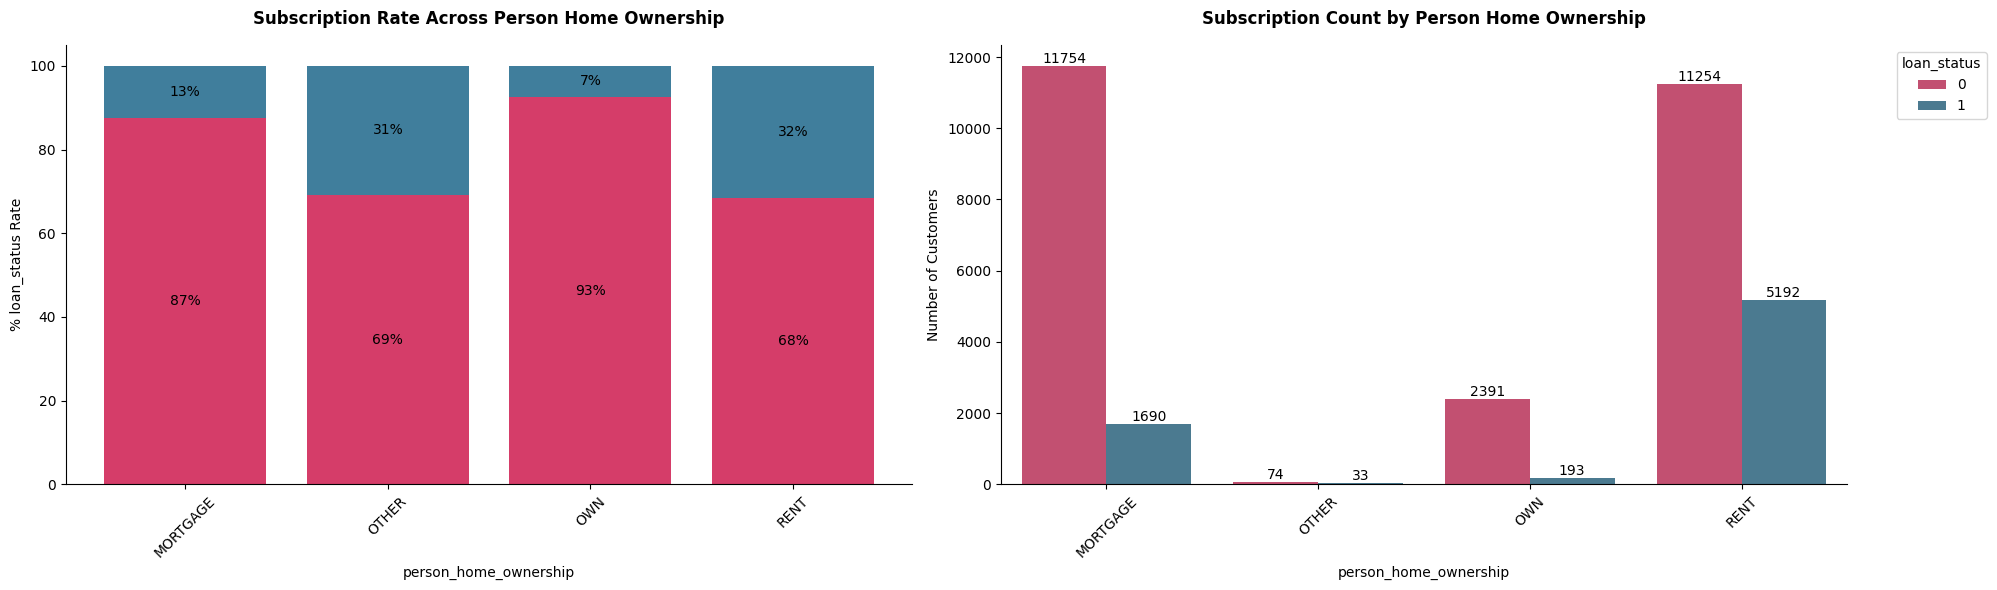

2026-05-06 13:14:50 | INFO     | Chi-Square Test of Independence: 'person_home_ownership' vs. 'loan_status'...
2026-05-06 13:14:50 | INFO     | Chi-squared statistic: 1907.981
2026-05-06 13:14:50 | INFO     | Degrees of freedom: 3
2026-05-06 13:14:50 | INFO     | p-value: 0.000000
2026-05-06 13:14:50 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-06 13:14:50 | INFO     | Variables 'person_home_ownership' and 'loan_status' are statistically associated.
2026-05-06 13:14:50 | DEBUG    | Displaying standardized residuals heatmap.


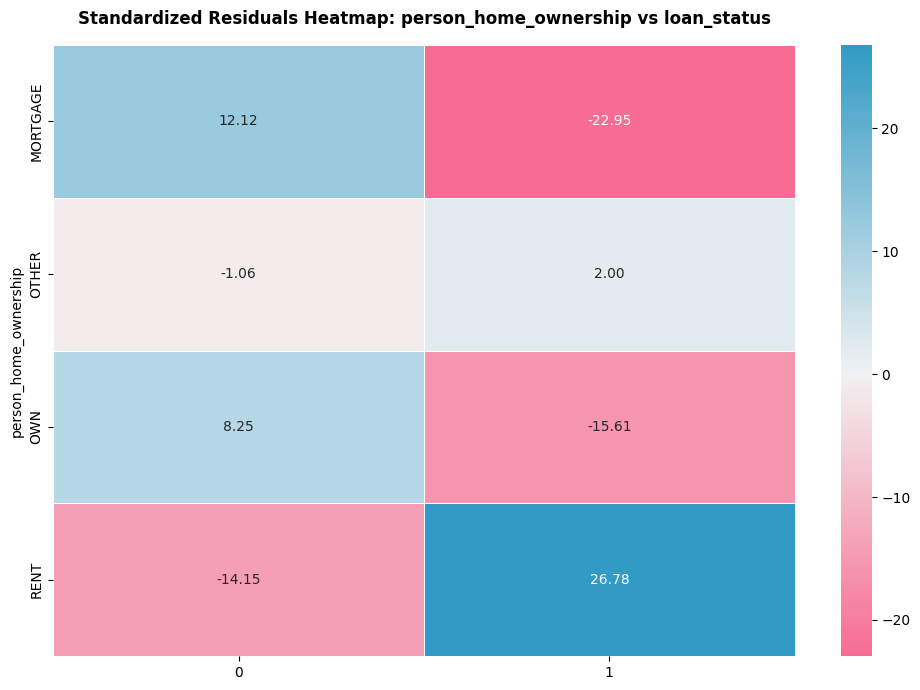

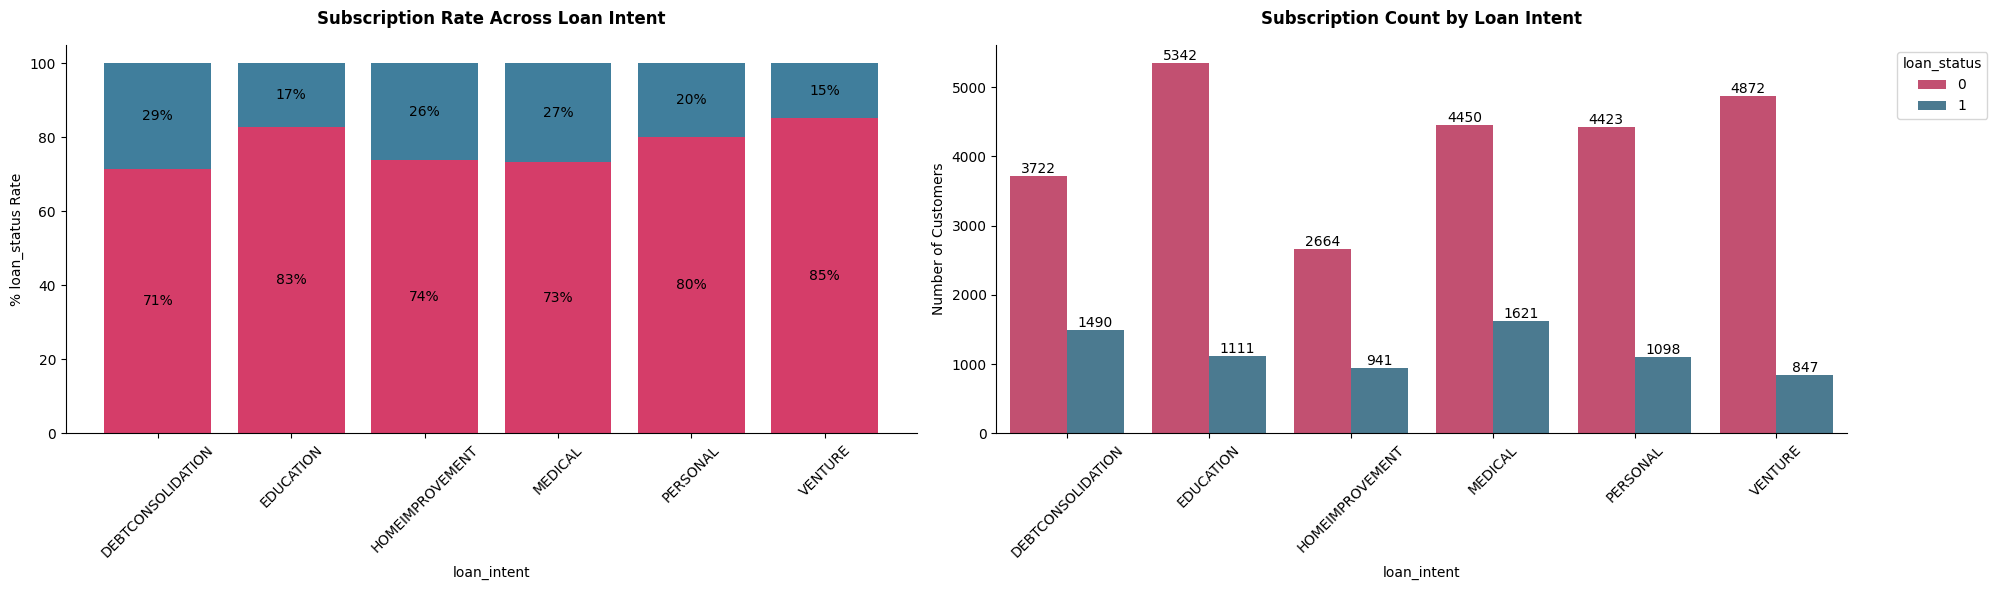

2026-05-06 13:14:51 | INFO     | Chi-Square Test of Independence: 'loan_intent' vs. 'loan_status'...
2026-05-06 13:14:51 | INFO     | Chi-squared statistic: 520.512
2026-05-06 13:14:51 | INFO     | Degrees of freedom: 5
2026-05-06 13:14:51 | INFO     | p-value: 0.000000
2026-05-06 13:14:51 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-06 13:14:51 | INFO     | Variables 'loan_intent' and 'loan_status' are statistically associated.
2026-05-06 13:14:51 | DEBUG    | Displaying standardized residuals heatmap.


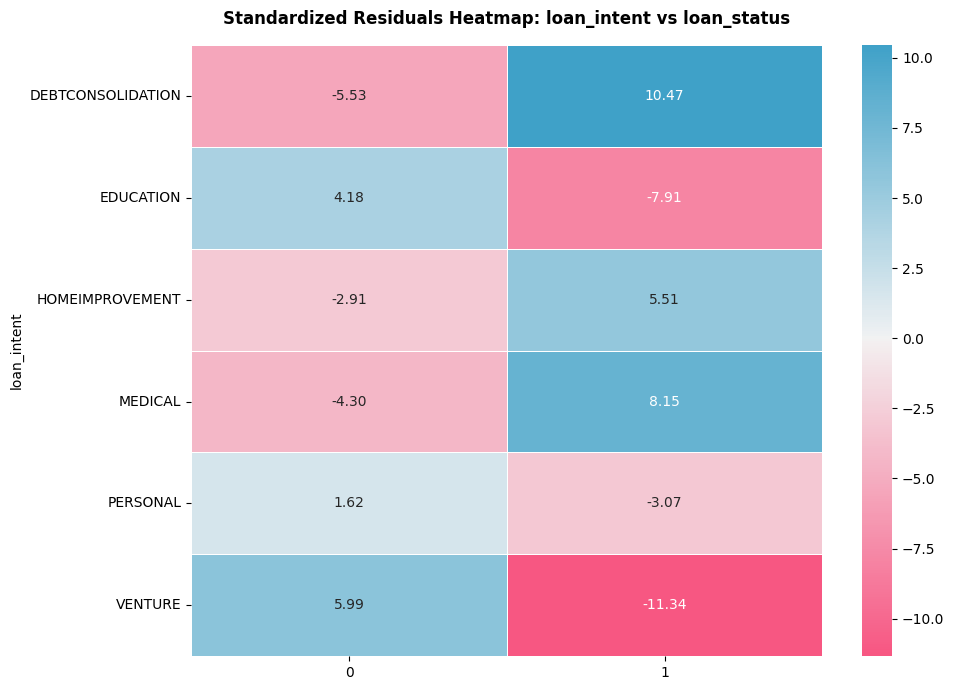

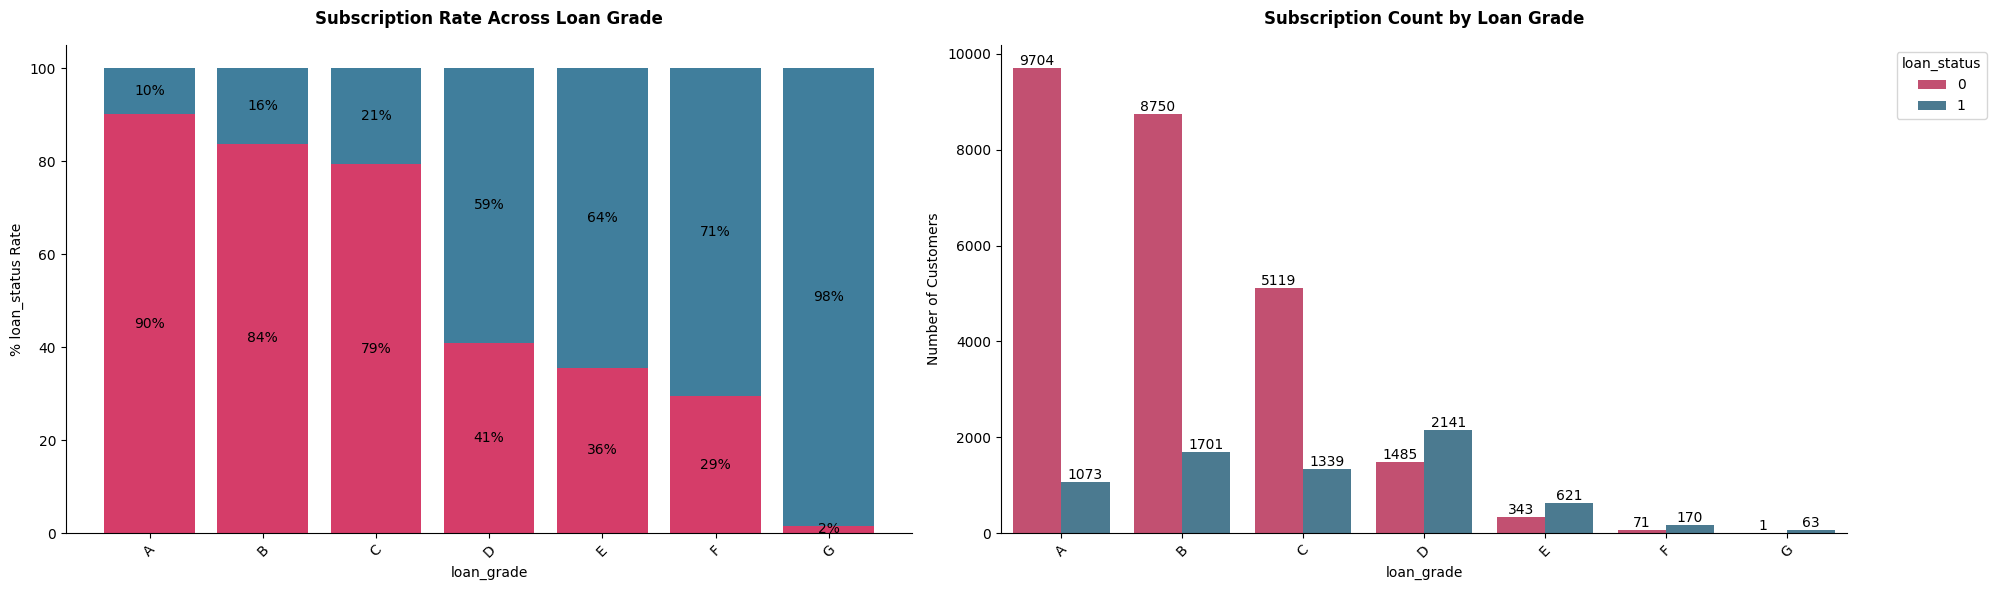

2026-05-06 13:14:51 | INFO     | Chi-Square Test of Independence: 'loan_grade' vs. 'loan_status'...
2026-05-06 13:14:51 | INFO     | Chi-squared statistic: 5609.184
2026-05-06 13:14:51 | INFO     | Degrees of freedom: 6
2026-05-06 13:14:51 | INFO     | p-value: 0.000000
2026-05-06 13:14:51 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-06 13:14:51 | INFO     | Variables 'loan_grade' and 'loan_status' are statistically associated.
2026-05-06 13:14:51 | DEBUG    | Displaying standardized residuals heatmap.


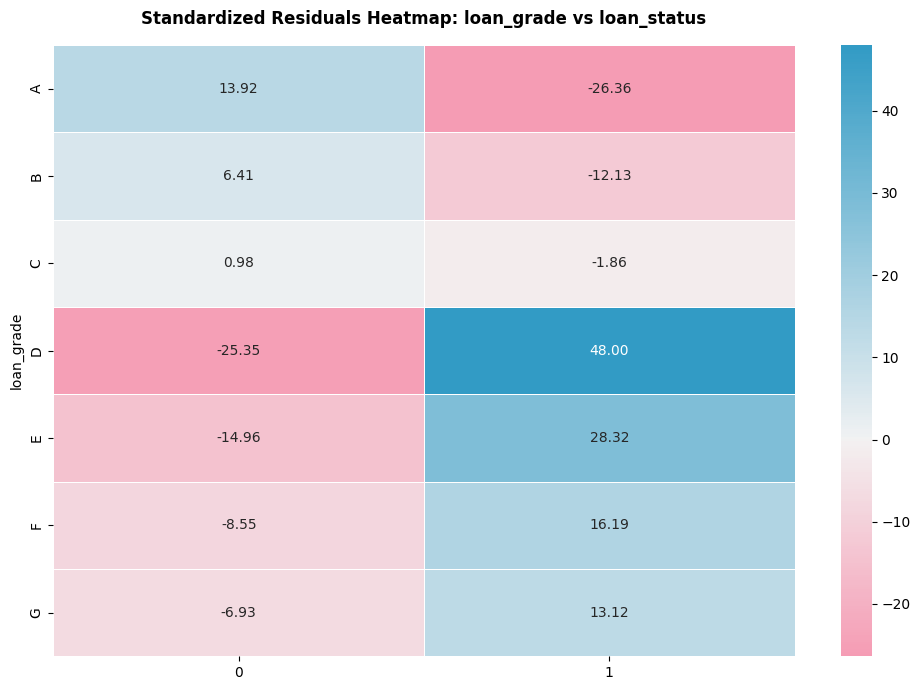

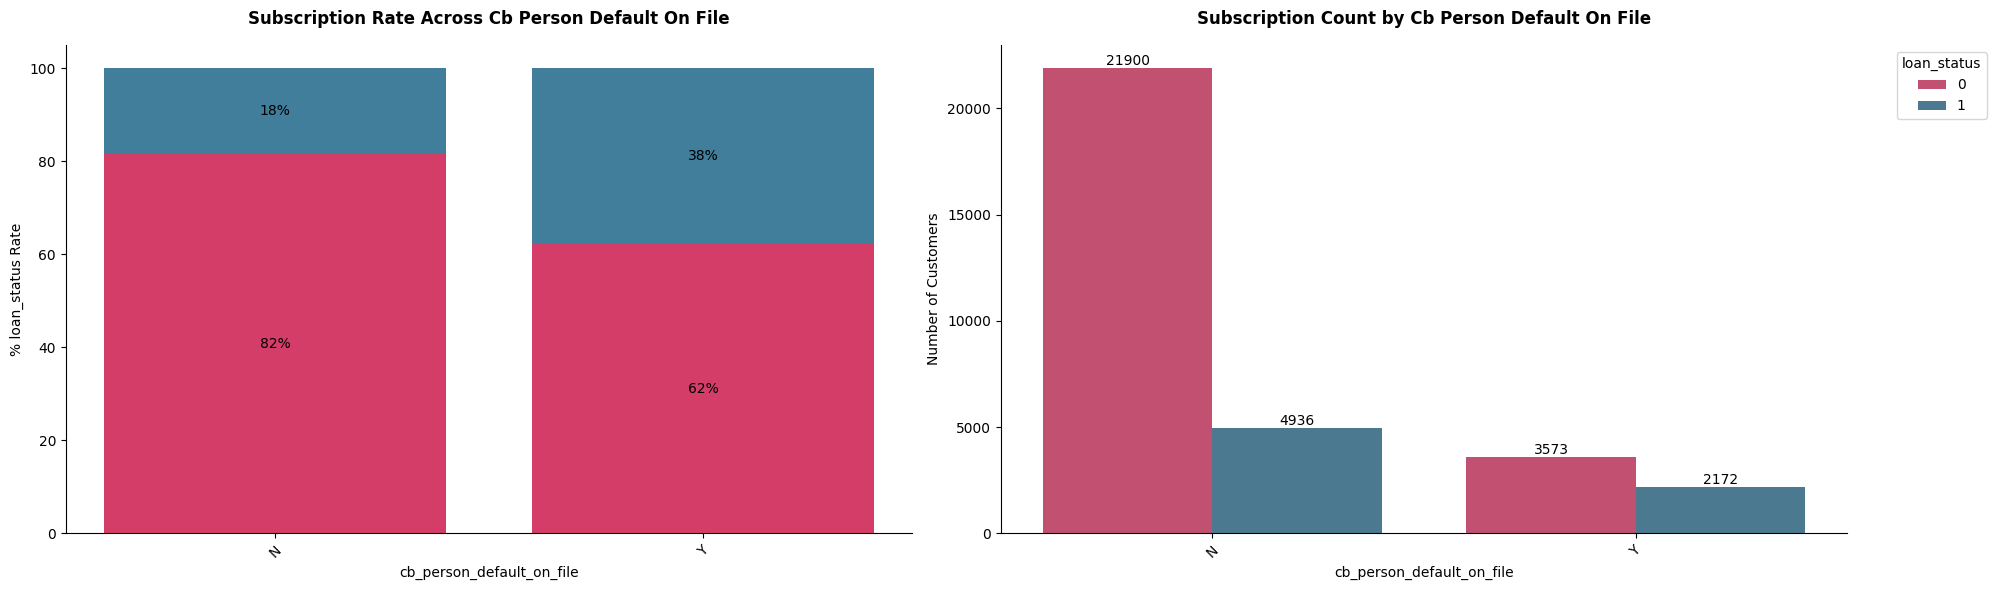

2026-05-06 13:14:52 | INFO     | Chi-Square Test of Independence: 'cb_person_default_on_file' vs. 'loan_status'...
2026-05-06 13:14:52 | INFO     | Chi-squared statistic: 1044.440
2026-05-06 13:14:52 | INFO     | Degrees of freedom: 1
2026-05-06 13:14:52 | INFO     | p-value: 0.000000
2026-05-06 13:14:52 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-06 13:14:52 | INFO     | Variables 'cb_person_default_on_file' and 'loan_status' are statistically associated.
2026-05-06 13:14:52 | DEBUG    | Displaying standardized residuals heatmap.


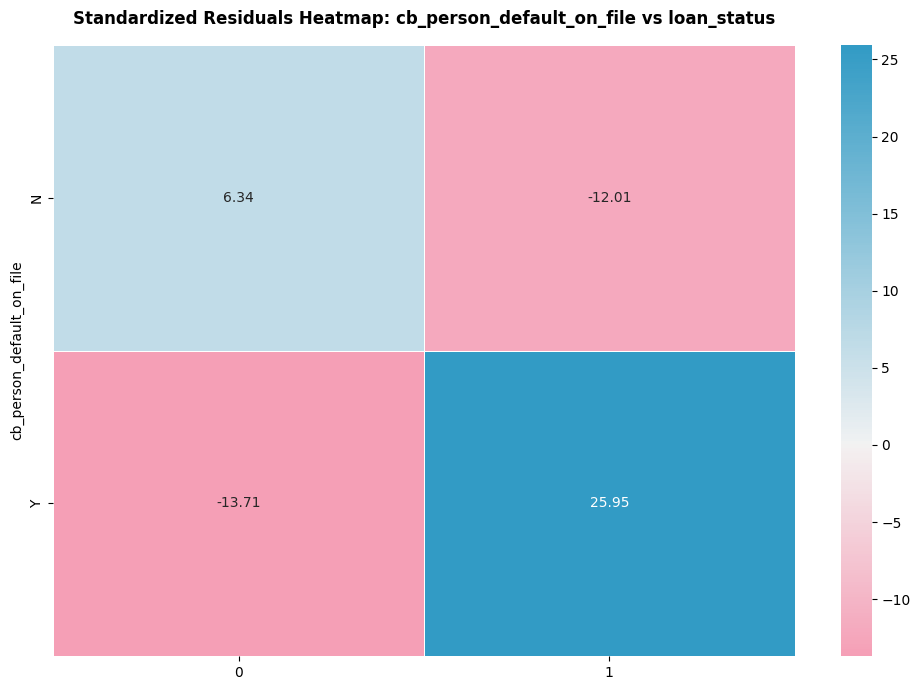

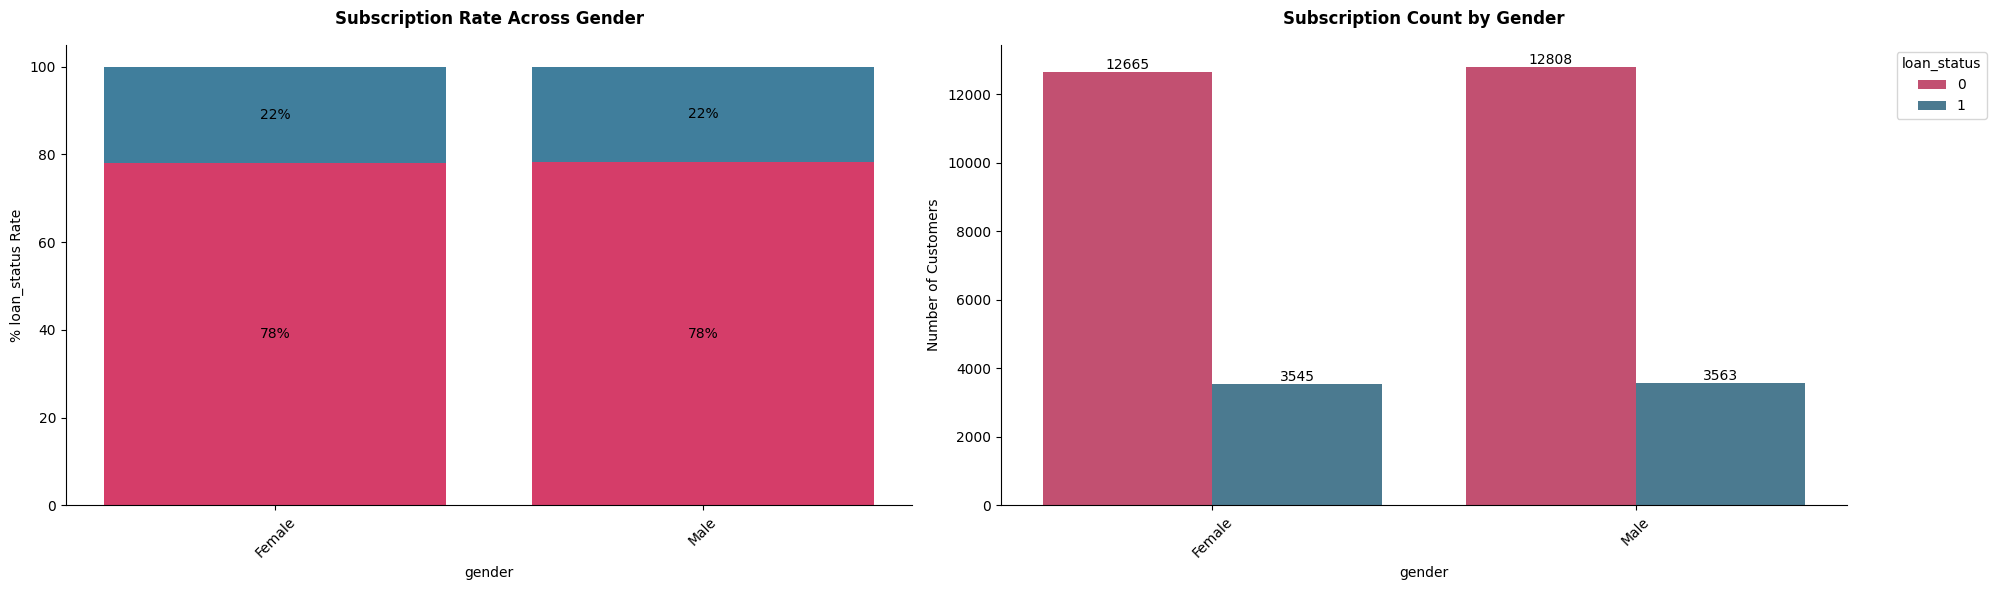

2026-05-06 13:14:52 | INFO     | Chi-Square Test of Independence: 'gender' vs. 'loan_status'...
2026-05-06 13:14:52 | INFO     | Chi-squared statistic: 0.047
2026-05-06 13:14:52 | INFO     | Degrees of freedom: 1
2026-05-06 13:14:52 | INFO     | p-value: 0.828754
2026-05-06 13:14:52 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:52 | WARNING  | No statistically significant association detected between 'gender' and 'loan_status'.


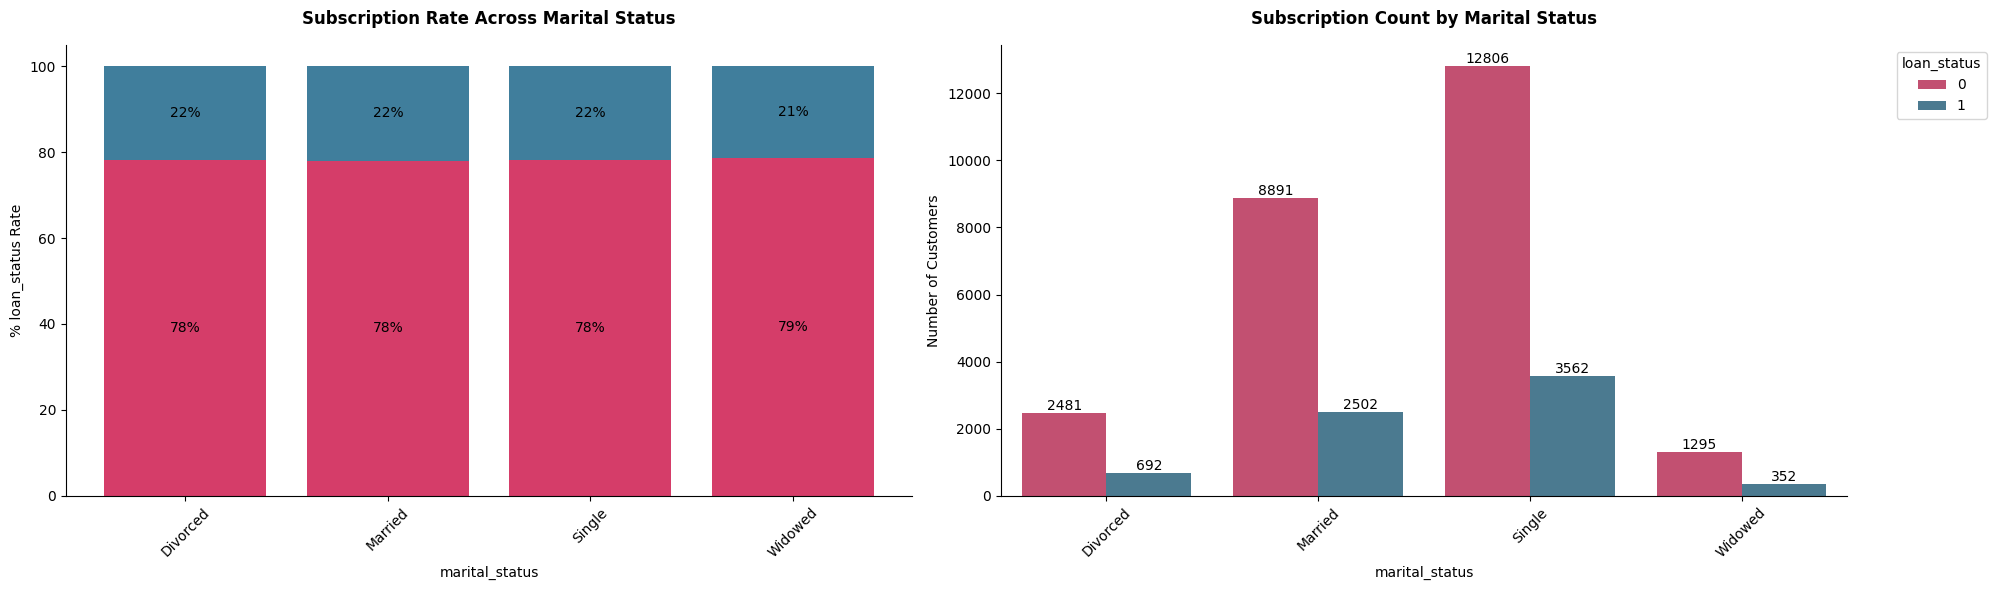

2026-05-06 13:14:53 | INFO     | Chi-Square Test of Independence: 'marital_status' vs. 'loan_status'...
2026-05-06 13:14:53 | INFO     | Chi-squared statistic: 0.358
2026-05-06 13:14:53 | INFO     | Degrees of freedom: 3
2026-05-06 13:14:53 | INFO     | p-value: 0.948688
2026-05-06 13:14:53 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:53 | WARNING  | No statistically significant association detected between 'marital_status' and 'loan_status'.


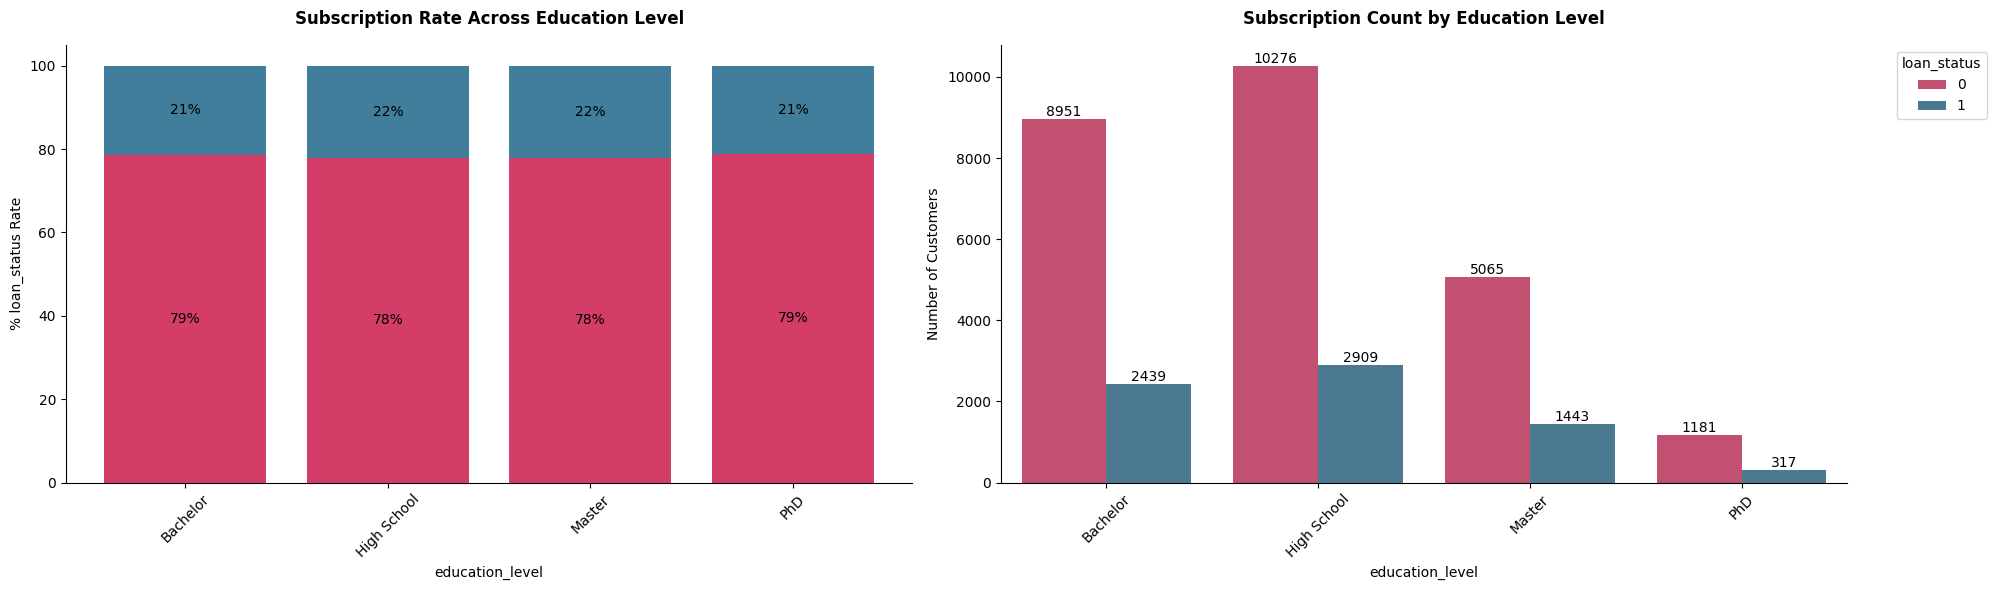

2026-05-06 13:14:53 | INFO     | Chi-Square Test of Independence: 'education_level' vs. 'loan_status'...
2026-05-06 13:14:53 | INFO     | Chi-squared statistic: 2.415
2026-05-06 13:14:53 | INFO     | Degrees of freedom: 3
2026-05-06 13:14:53 | INFO     | p-value: 0.490891
2026-05-06 13:14:53 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:53 | WARNING  | No statistically significant association detected between 'education_level' and 'loan_status'.


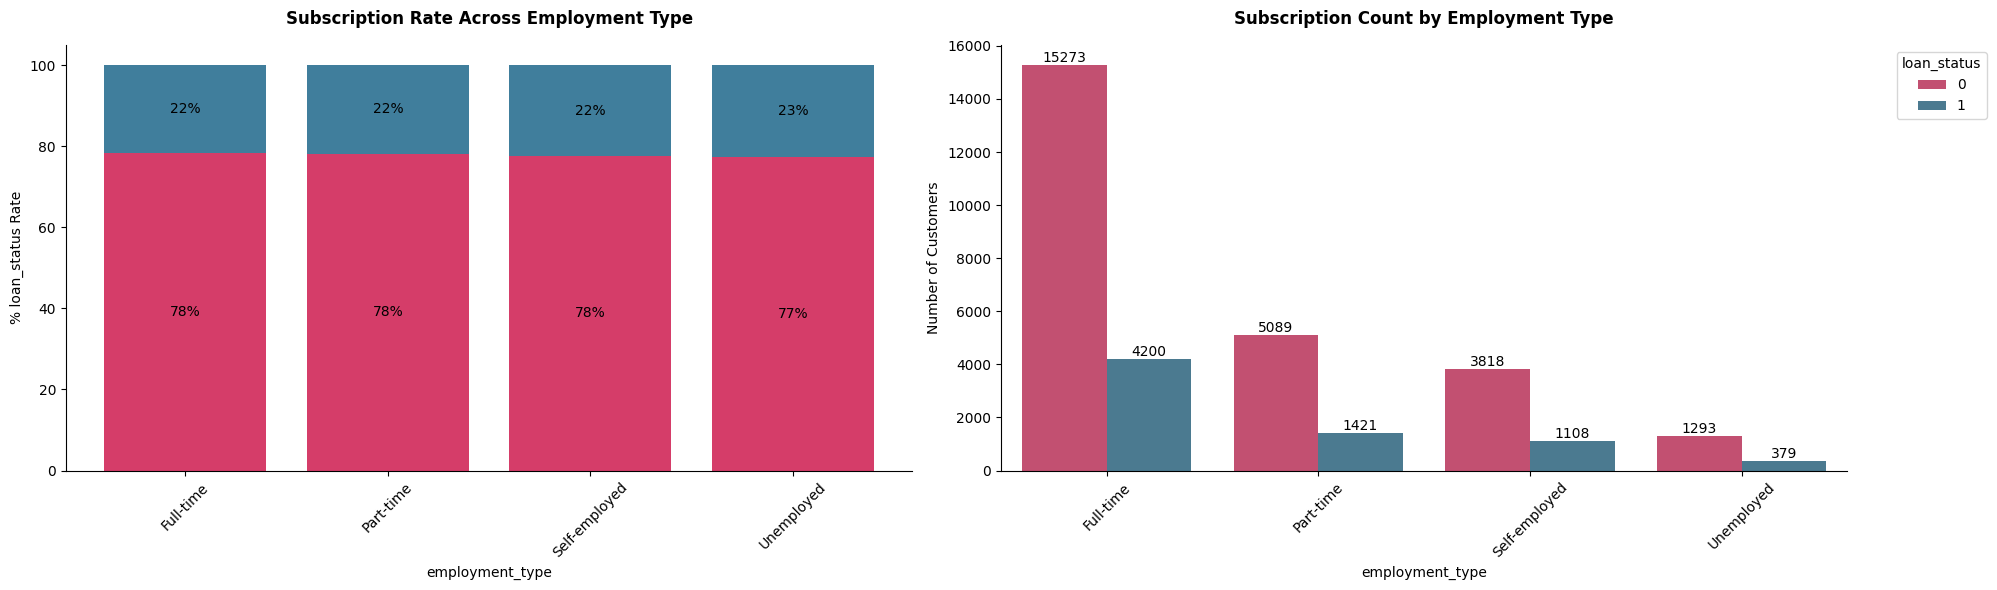

2026-05-06 13:14:54 | INFO     | Chi-Square Test of Independence: 'employment_type' vs. 'loan_status'...
2026-05-06 13:14:54 | INFO     | Chi-squared statistic: 2.735
2026-05-06 13:14:54 | INFO     | Degrees of freedom: 3
2026-05-06 13:14:54 | INFO     | p-value: 0.434350
2026-05-06 13:14:54 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:54 | WARNING  | No statistically significant association detected between 'employment_type' and 'loan_status'.


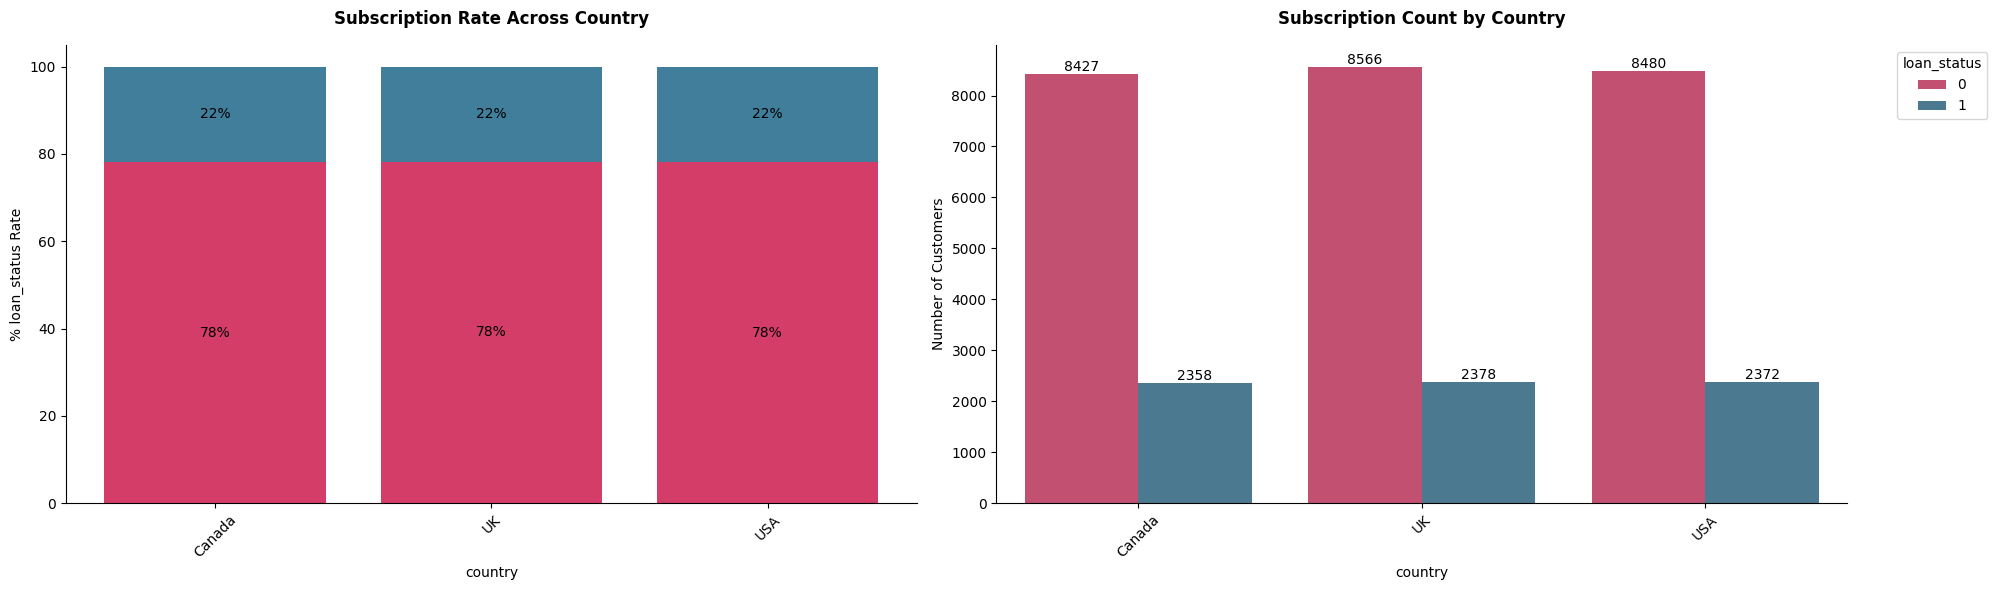

2026-05-06 13:14:54 | INFO     | Chi-Square Test of Independence: 'country' vs. 'loan_status'...
2026-05-06 13:14:54 | INFO     | Chi-squared statistic: 0.074
2026-05-06 13:14:54 | INFO     | Degrees of freedom: 2
2026-05-06 13:14:54 | INFO     | p-value: 0.963558
2026-05-06 13:14:54 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:54 | WARNING  | No statistically significant association detected between 'country' and 'loan_status'.


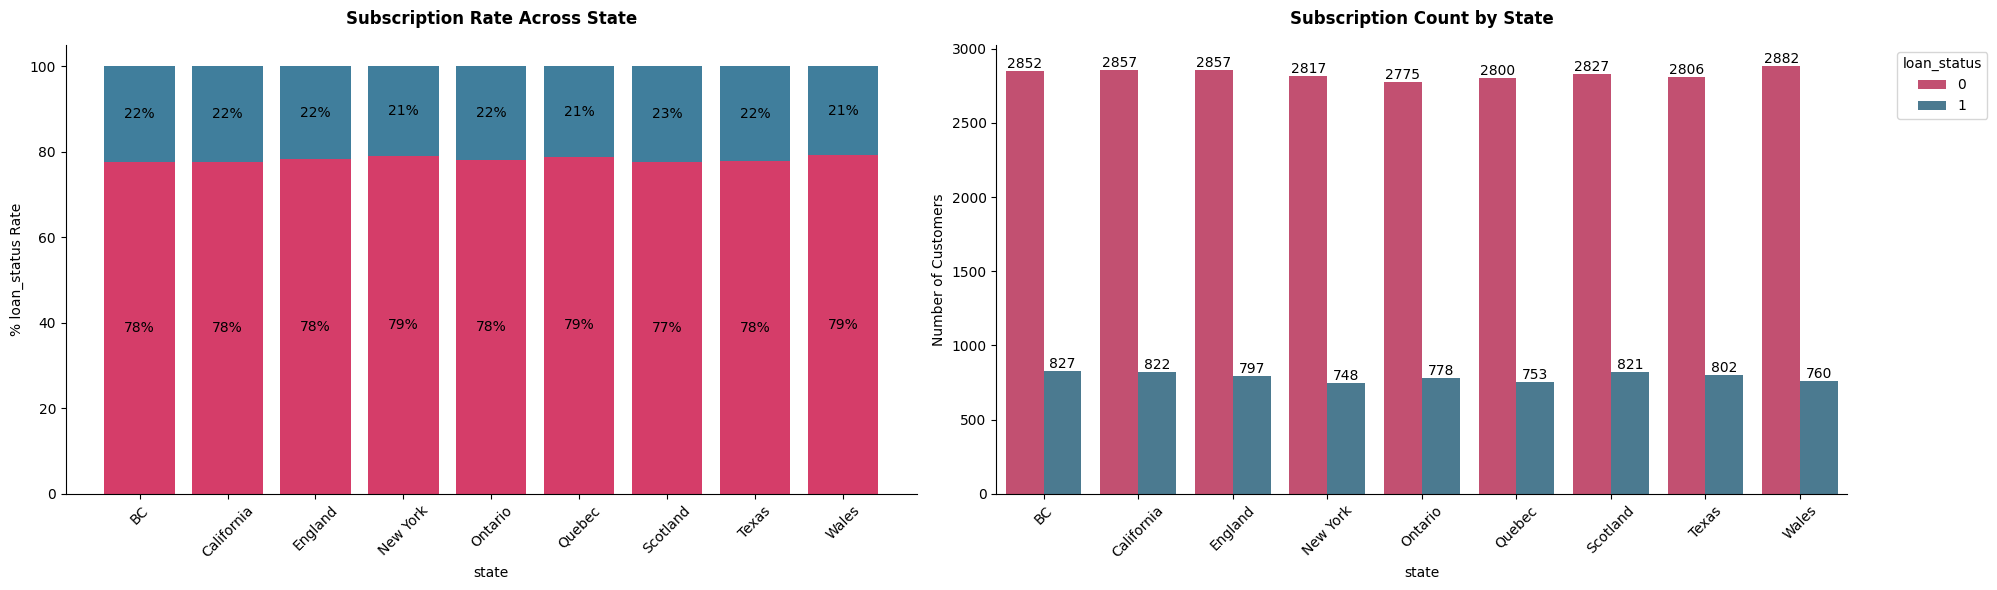

2026-05-06 13:14:54 | INFO     | Chi-Square Test of Independence: 'state' vs. 'loan_status'...
2026-05-06 13:14:55 | INFO     | Chi-squared statistic: 7.120
2026-05-06 13:14:55 | INFO     | Degrees of freedom: 8
2026-05-06 13:14:55 | INFO     | p-value: 0.523784
2026-05-06 13:14:55 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:55 | WARNING  | No statistically significant association detected between 'state' and 'loan_status'.


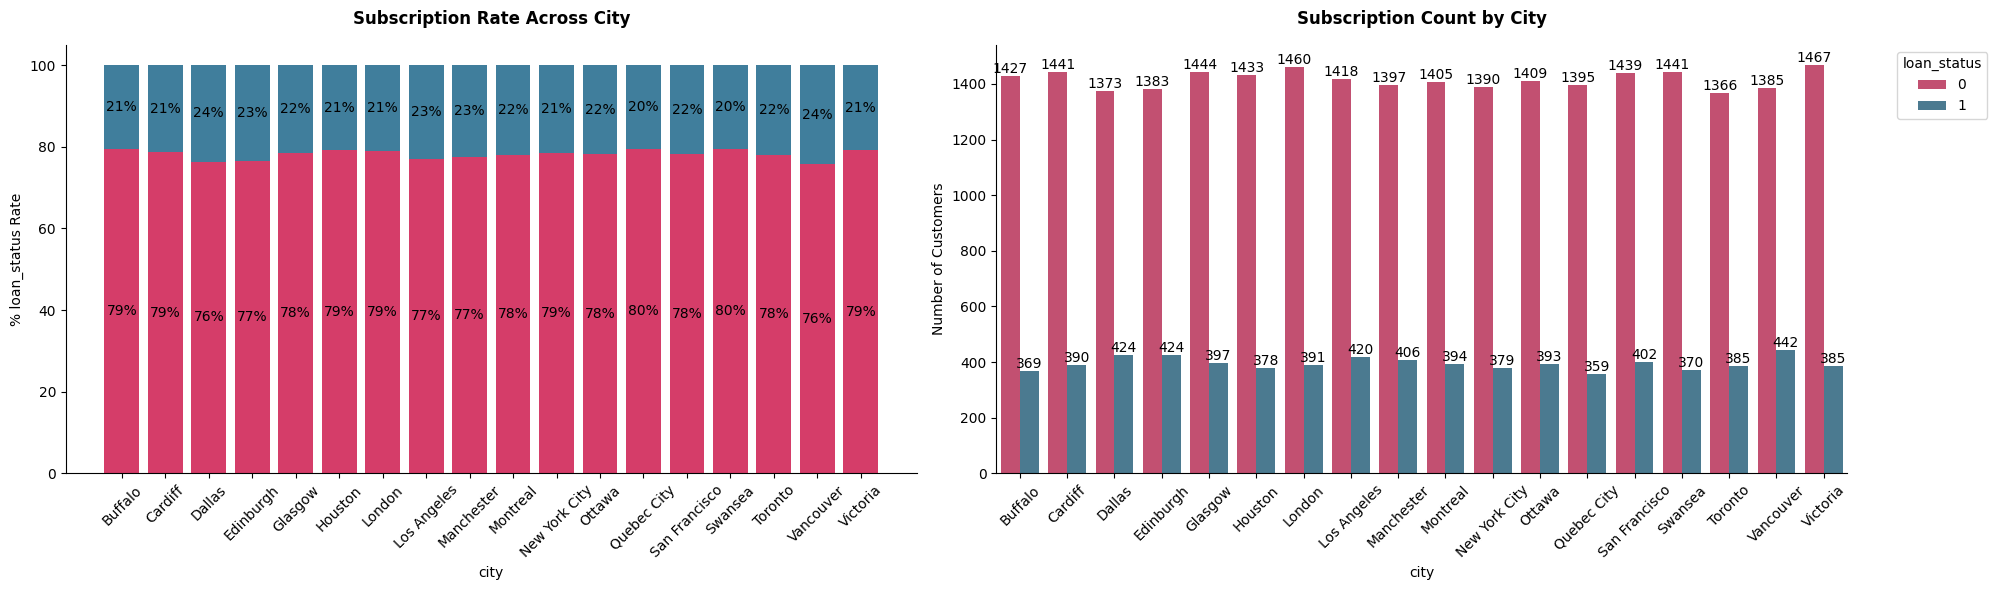

2026-05-06 13:14:55 | INFO     | Chi-Square Test of Independence: 'city' vs. 'loan_status'...
2026-05-06 13:14:55 | INFO     | Chi-squared statistic: 22.708
2026-05-06 13:14:55 | INFO     | Degrees of freedom: 17
2026-05-06 13:14:55 | INFO     | p-value: 0.159006
2026-05-06 13:14:55 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:55 | WARNING  | No statistically significant association detected between 'city' and 'loan_status'.


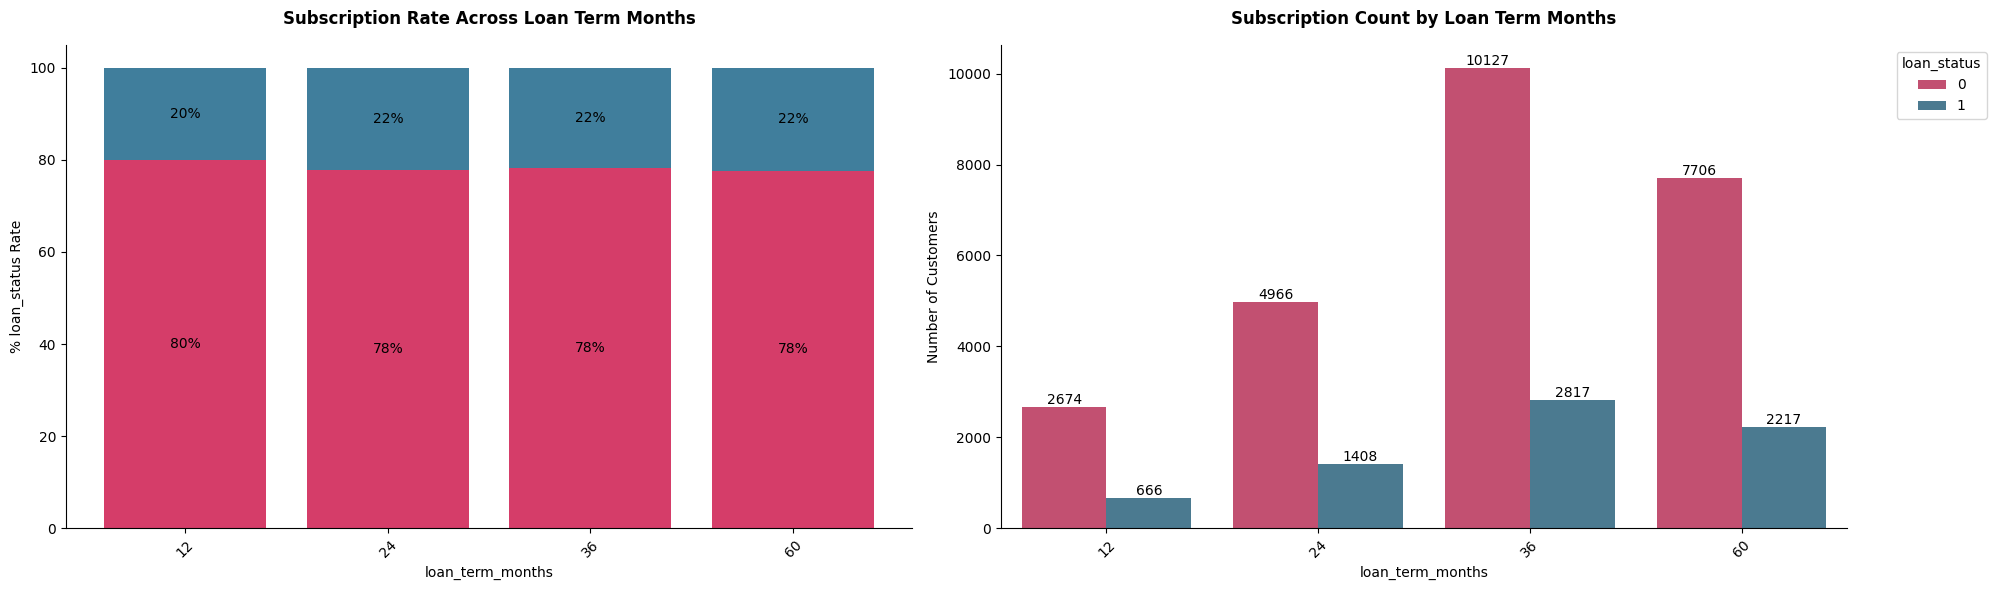

2026-05-06 13:14:56 | INFO     | Chi-Square Test of Independence: 'loan_term_months' vs. 'loan_status'...
2026-05-06 13:14:56 | INFO     | Chi-squared statistic: 8.802
2026-05-06 13:14:56 | INFO     | Degrees of freedom: 3
2026-05-06 13:14:56 | INFO     | p-value: 0.032046
2026-05-06 13:14:56 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-05-06 13:14:56 | INFO     | Variables 'loan_term_months' and 'loan_status' are statistically associated.
2026-05-06 13:14:56 | DEBUG    | Displaying standardized residuals heatmap.


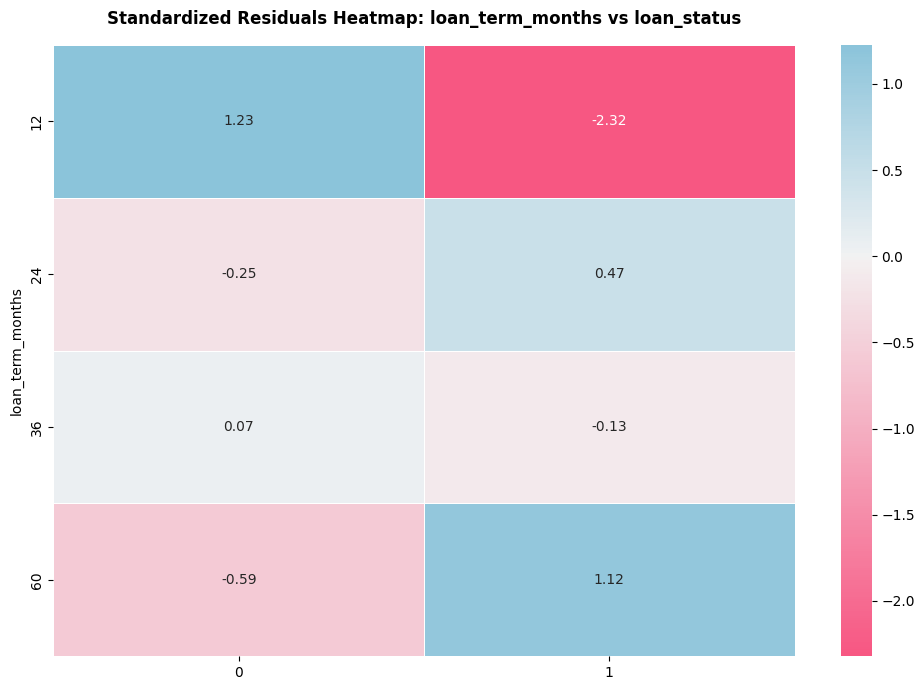

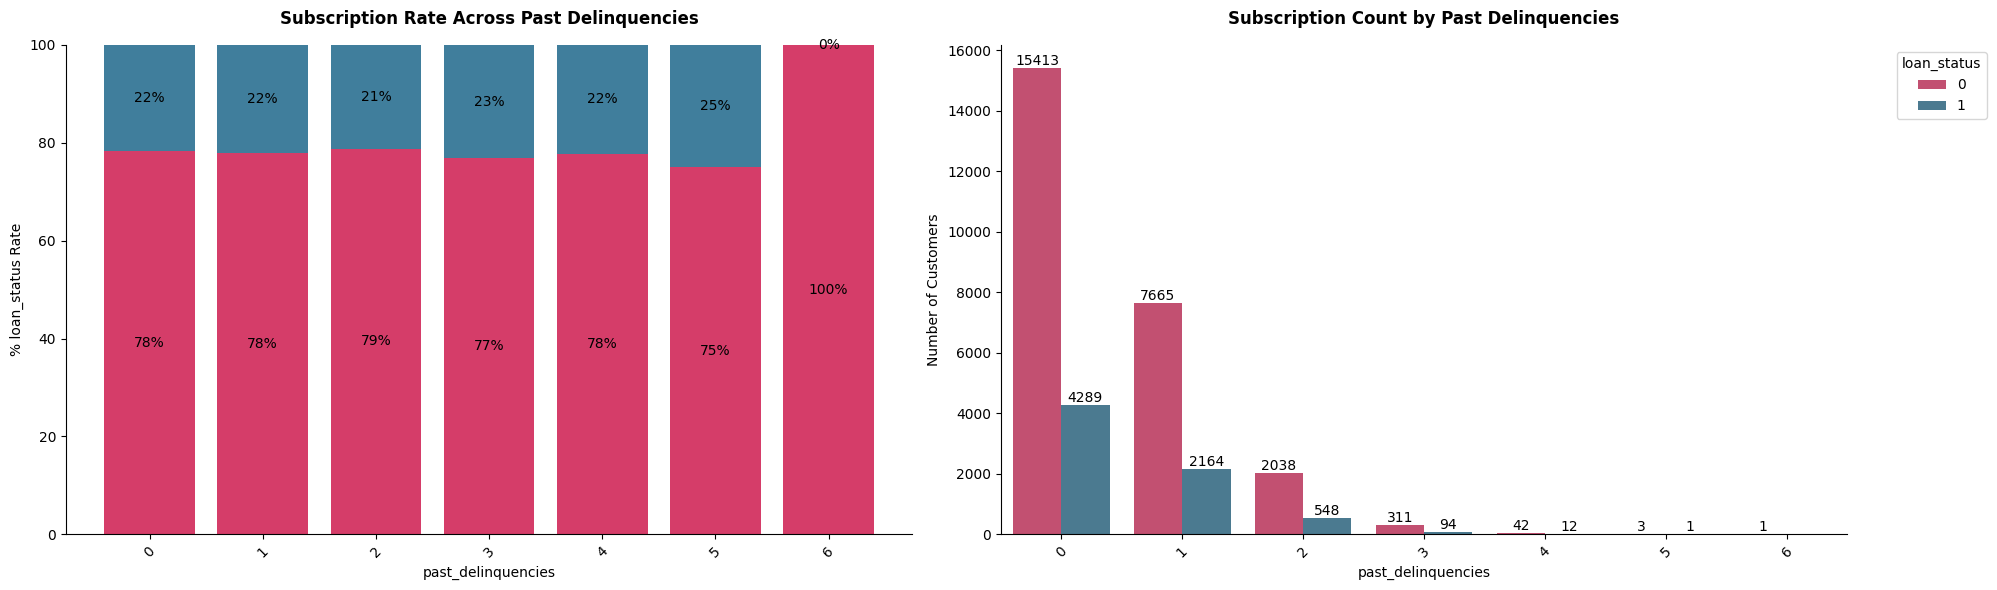

2026-05-06 13:14:56 | INFO     | Chi-Square Test of Independence: 'past_delinquencies' vs. 'loan_status'...
2026-05-06 13:14:56 | INFO     | Chi-squared statistic: 1.618
2026-05-06 13:14:56 | INFO     | Degrees of freedom: 6
2026-05-06 13:14:56 | INFO     | p-value: 0.951256
2026-05-06 13:14:57 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-05-06 13:14:57 | WARNING  | No statistically significant association detected between 'past_delinquencies' and 'loan_status'.


In [18]:
for feature in cat_features:
    StatUtils.analyze_categorical_feature_vs_target(cat = feature, target_feature=CFG.TARGET_FEATURE,
                                                    logger=logger, df=df)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>person_home_ownership</b>: Renters are the <b>highest-risk group (~32% default)</b>, while homeowners (especially <b>OWN ~7%</b>) are the safest → <b>strong risk indicator</b>.</li>

<li><b>Loan_Intent</b>: Clearly associated with default → <b>DEBTCONSOLIDATION &amp; MEDICAL</b> have higher risk, while <b>EDUCATION &amp; VENTURE</b> are safer segments.</li>

<li><b>Loan_Grade</b>: <b>Strongest risk driver</b> → default rate increases sharply from <b>A (~10%) → G (~98%)</b>.</li>

<li><b>Cb_Person_Default_On_File</b>: Prior default (<b>Y</b>) has much higher risk (<b>~38% vs ~18%</b>) → <b>strong and intuitive predictor</b>.</li>

<li><b>Gender</b>: Default rates are identical (~22%), p-value &gt; 0.05 → <b>no predictive power</b>.</li>

<li><b>Marital_Status</b>: Nearly identical (~21–22%), p-value &gt; 0.05 → <b>no meaningful relationship</b>.</li>

<li><b>Education_Level</b>: Very similar (~21–22%), p-value &gt; 0.05 → <b>no meaningful impact</b>.</li>

<li><b>Employment_Type</b>: Nearly identical (~22–23%), p-value &gt; 0.05 → <b>no meaningful impact</b>.</li>

<li><b>Country</b>: Almost identical (~22%), p-value &gt; 0.05 → <b>no meaningful impact</b>.</li>

<li><b>State</b>: Very similar (~21–23%), p-value &gt; 0.05 → <b>no meaningful impact</b>.</li>

<li><b>City</b>: Consistent (~20–24%), p-value &gt; 0.05 → <b>no meaningful impact</b>.</li>

<li><b>Loan_Term_Months</b>: Statistically significant but weak (p &lt; 0.05), with similar default rates (~20–22%).</li>

<li><b>Past_Delinquencies</b>: No significant relationship (p-value &gt; 0.05), default rates remain consistent (~21–25%).</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Overall Picuture
</div>

| Feature                                                                | Key Insight                                                                                                                  |
| ---------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| **loan_grade**                                                         | **Clear risk segmentation** → lower grades (D–G) have much higher default rates → useful for approval and pricing decisions. |
| **loan_int_rate**                                                      | **Higher interest rates indicate higher risk borrowers** → strong signal of default likelihood.                              |
| **debt_to_income_ratio**                                               | **Core risk driver** → customers with higher financial burden are much more likely to default.                               |
| **loan_percent_income**                                                | **Repayment pressure matters** → higher loan-to-income ratio increases default risk.                                         |
| **person_income**                                                      | **Higher income = safer borrowers** → strong indicator of repayment ability.                                                 |
| **person_home_ownership**                                              | **Housing stability matters** → renters are riskier, while homeowners are significantly safer.                               |
| **cb_person_default_on_file**                                          | **Past behavior predicts future risk** → customers with prior default are much more likely to default again.                 |
| **loan_intent**                                                        | **Loan purpose impacts risk** → debt consolidation & medical loans are riskier; education & venture are safer.               |
| **loan_amnt**                                                          | **Larger loans increase exposure** → slightly higher default risk.                                                           |
| **loan_to_income_ratio**                                               | **Overlaps with loan_percent_income** → similar signal, should keep one to avoid redundancy.                                 |
| **loan_term_months**                                                   | **Minimal impact** → default rates are similar across different loan durations.                                              |
| **person_age**                                                         | **Low business impact** → similar behavior across age groups.                                                                |
| **person_emp_length**                                                  | **Weak signal of stability** → longer employment slightly reduces risk but not significant.                                  |
| **cb_person_cred_hist_length**                                         | **Limited usefulness** → credit history length alone does not explain default well.                                          |
| **other_debt**                                                         | **Misleading signal** → absolute debt is less meaningful than ratios due to skew.                                            |
| **open_accounts**                                                      | **No meaningful impact** → similar behavior across groups.                                                                   |
| **credit_utilization_ratio**                                           | **No clear signal** → does not differentiate default behavior.                                                               |
| **past_delinquencies**                                                 | **Weak predictor** → less informative than prior default flag.                                                               |
| **gender / marital_status / education_level / country / state / city** | **No business impact** → default rates are consistent across demographic and geographic groups.                              |

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Pre-processing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Pre-processing
    </h1>
</div>

## Handle skewness

In [19]:
logger.info("-" * 80)
skew_feature = DataValidator.check_skewness(data=df, dataset_name=CFG.DATASET_NAME, 
                                            numerical_features=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-05-06 13:14:57 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:57 | INFO     | Skewness analysis for Credit Risk Dataset
2026-05-06 13:14:57 | INFO     | Total numerical features checked: 12
2026-05-06 13:14:57 | DEBUG    | ----------------------------------------------------------------------
2026-05-06 13:14:57 | DEBUG    | Feature                        | Skewness  | Remark
2026-05-06 13:14:57 | DEBUG    | ----------------------------------------------------------------------
2026-05-06 13:14:57 | DEBUG    | person_income                  |  +32.8653 | Highly skewed
2026-05-06 13:14:57 | DEBUG    | other_debt                     |  +28.4619 | Highly skewed
2026-05-06 13:14:57 | DEBUG    | person_emp_length              |   +2.6145 | Highly skewed
2026-05-06 13:14:57 | DEBUG    | person_age                     |   +2.5814 | Highly skewed
2026-05-06 13:14:57 | DEBUG    | cb_person_cred_hist_length     |   +1.6618 | Hi

In [20]:
processed_df, transformed_columns, sparse_columns, skewed_columns = FeatureUtils.fea_HandleSkewedFeatures(df=df, num_features=skew_feature, logger=logger)

2026-05-06 13:14:57 | INFO     | Starting skewed feature handling
2026-05-06 13:14:57 | DEBUG    | Total numerical features provided: 9
2026-05-06 13:14:57 | DEBUG    | Excluded columns: []
2026-05-06 13:14:57 | INFO     | Scanning 9 numerical columns
2026-05-06 13:14:57 | INFO     | Detected 9 skewed features
2026-05-06 13:14:57 | DEBUG    | Processing column: cb_person_cred_hist_length
2026-05-06 13:14:57 | INFO     | cb_person_cred_hist_length: applying Yeo-Johnson transformation
2026-05-06 13:14:57 | DEBUG    | Processing column: loan_percent_income
2026-05-06 13:14:57 | INFO     | loan_percent_income: applying Yeo-Johnson transformation
2026-05-06 13:14:57 | DEBUG    | Processing column: loan_to_income_ratio
2026-05-06 13:14:57 | INFO     | loan_to_income_ratio: applying Yeo-Johnson transformation
2026-05-06 13:14:57 | DEBUG    | Processing column: debt_to_income_ratio
2026-05-06 13:14:57 | INFO     | debt_to_income_ratio: applying Yeo-Johnson transformation
2026-05-06 13:14:57 | 

In [21]:
num_features = ["PT_person_age", "PT_person_income", "PT_person_emp_length", "PT_loan_amnt", "loan_int_rate", "PT_loan_percent_income", 
                "PT_loan_to_income_ratio", "PT_cb_person_cred_hist_length", "PT_other_debt",  "PT_debt_to_income_ratio", "open_accounts", 
                "credit_utilization_ratio"]
logger.info("-" * 80)
skew_feature = DataValidator.check_skewness(data=processed_df, dataset_name=CFG.DATASET_NAME, 
                                            numerical_features=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-05-06 13:14:57 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:57 | INFO     | Skewness analysis for Credit Risk Dataset
2026-05-06 13:14:57 | INFO     | Total numerical features checked: 12
2026-05-06 13:14:57 | DEBUG    | ----------------------------------------------------------------------
2026-05-06 13:14:57 | DEBUG    | Feature                        | Skewness  | Remark
2026-05-06 13:14:57 | DEBUG    | ----------------------------------------------------------------------
2026-05-06 13:14:57 | DEBUG    | loan_int_rate                  |   +0.2086 | Approximately symmetric
2026-05-06 13:14:57 | DEBUG    | PT_person_age                  |   +0.1589 | Approximately symmetric
2026-05-06 13:14:57 | DEBUG    | PT_cb_person_cred_hist_length  |   +0.0956 | Approximately symmetric
2026-05-06 13:14:57 | DEBUG    | PT_loan_to_income_ratio        |   +0.0906 | Approximately symmetric
2026-05-06 13:14:57 | DEBUG    | PT_loan

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight
</div>

<b>Observations from the Skewness Analysis:</b>

<b>Before Transformation:</b>

<ul style="line-height: 1.8; padding-left: 20px;">
<li>Most numerical features were <b>heavily right-skewed</b>, especially <code>person_income</code> and <code>other_debt</code> (extreme skew &gt; 25).</li>
<li>A total of <b>9 out of 12 features</b> showed significant skewness (|skew| &gt; 0.5), indicating <b>non-normal distributions and presence of outliers</b>.</li>
<li>Only a few features such as <code>loan_int_rate</code>, <code>open_accounts</code>, and <code>credit_utilization_ratio</code> were approximately symmetric.</li>
</ul>

<b>After Transformation (Yeo-Johnson / Power Transform):</b>

<ul style="line-height: 1.8; padding-left: 20px;">
<li>All transformed features (<code>PT_*</code>) became <b>approximately symmetric</b> (skew ≈ 0).</li>
<li><b>No highly skewed features remain</b>, indicating a successful normalization process.</li>
<li>Extreme skewness in key financial variables (<code>person_income</code>, <code>other_debt</code>) was <b>effectively corrected</b>.</li>
<li>Original symmetric features (<code>loan_int_rate</code>, <code>open_accounts</code>, <code>credit_utilization_ratio</code>) remained stable.</li>
</ul>

<b>Conclusion:</b>

<ul style="line-height: 1.8; padding-left: 20px;">
<li>The transformation significantly <b>improved feature distributions</b>, reducing the impact of outliers.</li>
<li>This enhances <b>model stability, convergence, and performance</b>, especially for linear and distance-based models.</li>
<li>The dataset is now better suited for <b>machine learning modeling</b> with reduced bias from skewed features.</li>
</ul>

</div>

## Re-check Outlier

In [22]:
logger.info("Start checking outlier dataset")
logger.info("-" * 80)
outlier_data = DataValidator.checkOutlier(df=processed_df, dataset_name=CFG.DATASET_NAME, 
                                          list_feature=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Outlier checking successfully completed across datasets.")

2026-05-06 13:14:57 | INFO     | Start checking outlier dataset
2026-05-06 13:14:57 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:57 | INFO     | Checking outliers for Credit Risk Dataset...
2026-05-06 13:14:57 | INFO     | --------------------------------------------------------------------------------
2026-05-06 13:14:57 | DEBUG    | [Credit Risk Dataset] PT_person_age: No outliers detected
2026-05-06 13:14:57 | WARNING  | [Credit Risk Dataset] PT_person_income: 568 outliers detected (lower=-2.553, upper=2.553)
2026-05-06 13:14:57 | WARNING  | [Credit Risk Dataset] PT_person_emp_length: 44 outliers detected (lower=-2.547, upper=2.697)
2026-05-06 13:14:57 | WARNING  | [Credit Risk Dataset] PT_loan_amnt: 8 outliers detected (lower=-2.591, upper=2.553)
2026-05-06 13:14:57 | WARNING  | [Credit Risk Dataset] loan_int_rate: 6 outliers detected (lower=-0.455, upper=21.825)
2026-05-06 13:14:57 | DEBUG    | [Credit Risk Dataset]

## Create Test Set

In [23]:
X = processed_df.drop(columns=CFG.TARGET_FEATURE)
y = processed_df[CFG.TARGET_FEATURE]

split = StratifiedShuffleSplit(n_splits=CFG.SPLIT["n_splits"], test_size=CFG.SPLIT["test_size"], 
                               random_state=CFG.RANDOM_STATE)

for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

## Scale and Encode

In [24]:
list_feature_num_stand = ["PT_person_age", "PT_loan_percent_income", "PT_loan_to_income_ratio", "PT_cb_person_cred_hist_length", "open_accounts", 
                          "credit_utilization_ratio"]
list_feature_num_robust = ["PT_person_income", "PT_person_emp_length", "PT_loan_amnt", "loan_int_rate", "PT_other_debt", 
                           "PT_debt_to_income_ratio"]

num_robust_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

num_stand_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num_robust", num_robust_transformer, list_feature_num_robust),
    ("num_standard", num_stand_transformer, list_feature_num_stand),
    ("cat_onehot", cat_onehot_transformer, cat_features)
])

preprocessor.fit(X_train)
X_train_prepared = preprocessor.transform(X_train)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num_standard__", "").replace("num_robust__", "").replace("cat_onehot__", "").replace("PT_", "") for col in list_feature_prepared]

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Metric
    </h1>
</div>


**AUC-ROC Overview**

**AUC-ROC** evaluates a model’s ability to **distinguish between two classes**.

* **ROC curve** plots **TPR vs FPR**
* **AUC** = Area under ROC curve → **ranking quality of predictions**

**Why AUC-ROC?**

* Robust to **class imbalance**
* Measures **ranking ability**, not fixed threshold (0.5)
* Common metric in **credit risk & fraud prediction**

> Higher AUC → better separation between *Paid* vs *Default*

**Interpretation**

| AUC Score     | Meaning                  |
| ------------- | ------------------------ |
| **1.0**       | Perfect model            |
| **0.9+**      | Excellent discrimination |
| **0.7 – 0.9** | Good                     |
| **0.5**       | Random guessing          |
| **< 0.5**     | Worse than random        |

(Source: [ROC AUC](https://en.wikipedia.org/wiki/Receiver_operating_characteristic))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

## CatBoostClassifier

In [25]:
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(
    lambda trial: objective_catboost(trial, X_train_prepared, y_train, logger),
    n_trials=10, show_progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

2026-05-06 13:16:31 | INFO     | Trial 0 finished | Mean AUC: 0.94147
2026-05-06 13:17:22 | INFO     | Trial 1 finished | Mean AUC: 0.90992
2026-05-06 13:19:00 | INFO     | Trial 2 finished | Mean AUC: 0.93835
2026-05-06 13:20:33 | INFO     | Trial 3 finished | Mean AUC: 0.91347
2026-05-06 13:21:15 | INFO     | Trial 4 finished | Mean AUC: 0.94299
2026-05-06 13:23:29 | INFO     | Trial 5 finished | Mean AUC: 0.91087
2026-05-06 13:24:39 | INFO     | Trial 6 finished | Mean AUC: 0.93099
2026-05-06 13:25:56 | INFO     | Trial 7 finished | Mean AUC: 0.89885
2026-05-06 13:27:47 | INFO     | Trial 8 finished | Mean AUC: 0.91551
2026-05-06 13:28:48 | INFO     | Trial 9 finished | Mean AUC: 0.94477


2026-05-06 13:28:48 | INFO     | Starting OOF training with CatBoostClassifier
2026-05-06 13:28:48 | INFO     | Fold 1/5
2026-05-06 13:29:01 | INFO     | Fold 1 AUC: 0.94905
2026-05-06 13:29:01 | INFO     | Fold 2/5
2026-05-06 13:29:14 | INFO     | Fold 2 AUC: 0.94606
2026-05-06 13:29:14 | INFO     | Fold 3/5
2026-05-06 13:29:27 | INFO     | Fold 3 AUC: 0.93448
2026-05-06 13:29:27 | INFO     | Fold 4/5
2026-05-06 13:29:40 | INFO     | Fold 4 AUC: 0.94238
2026-05-06 13:29:40 | INFO     | Fold 5/5
2026-05-06 13:29:53 | INFO     | Fold 5 AUC: 0.94604
2026-05-06 13:29:53 | INFO     | OOF training completed
2026-05-06 13:29:53 | INFO     | OOF AUC: 0.94347
2026-05-06 13:29:53 | INFO     | Fold AUCs: [0.9490502786545519, 0.946056587113964, 0.9344766930518908, 0.9423787292311343, 0.9460351479245243]


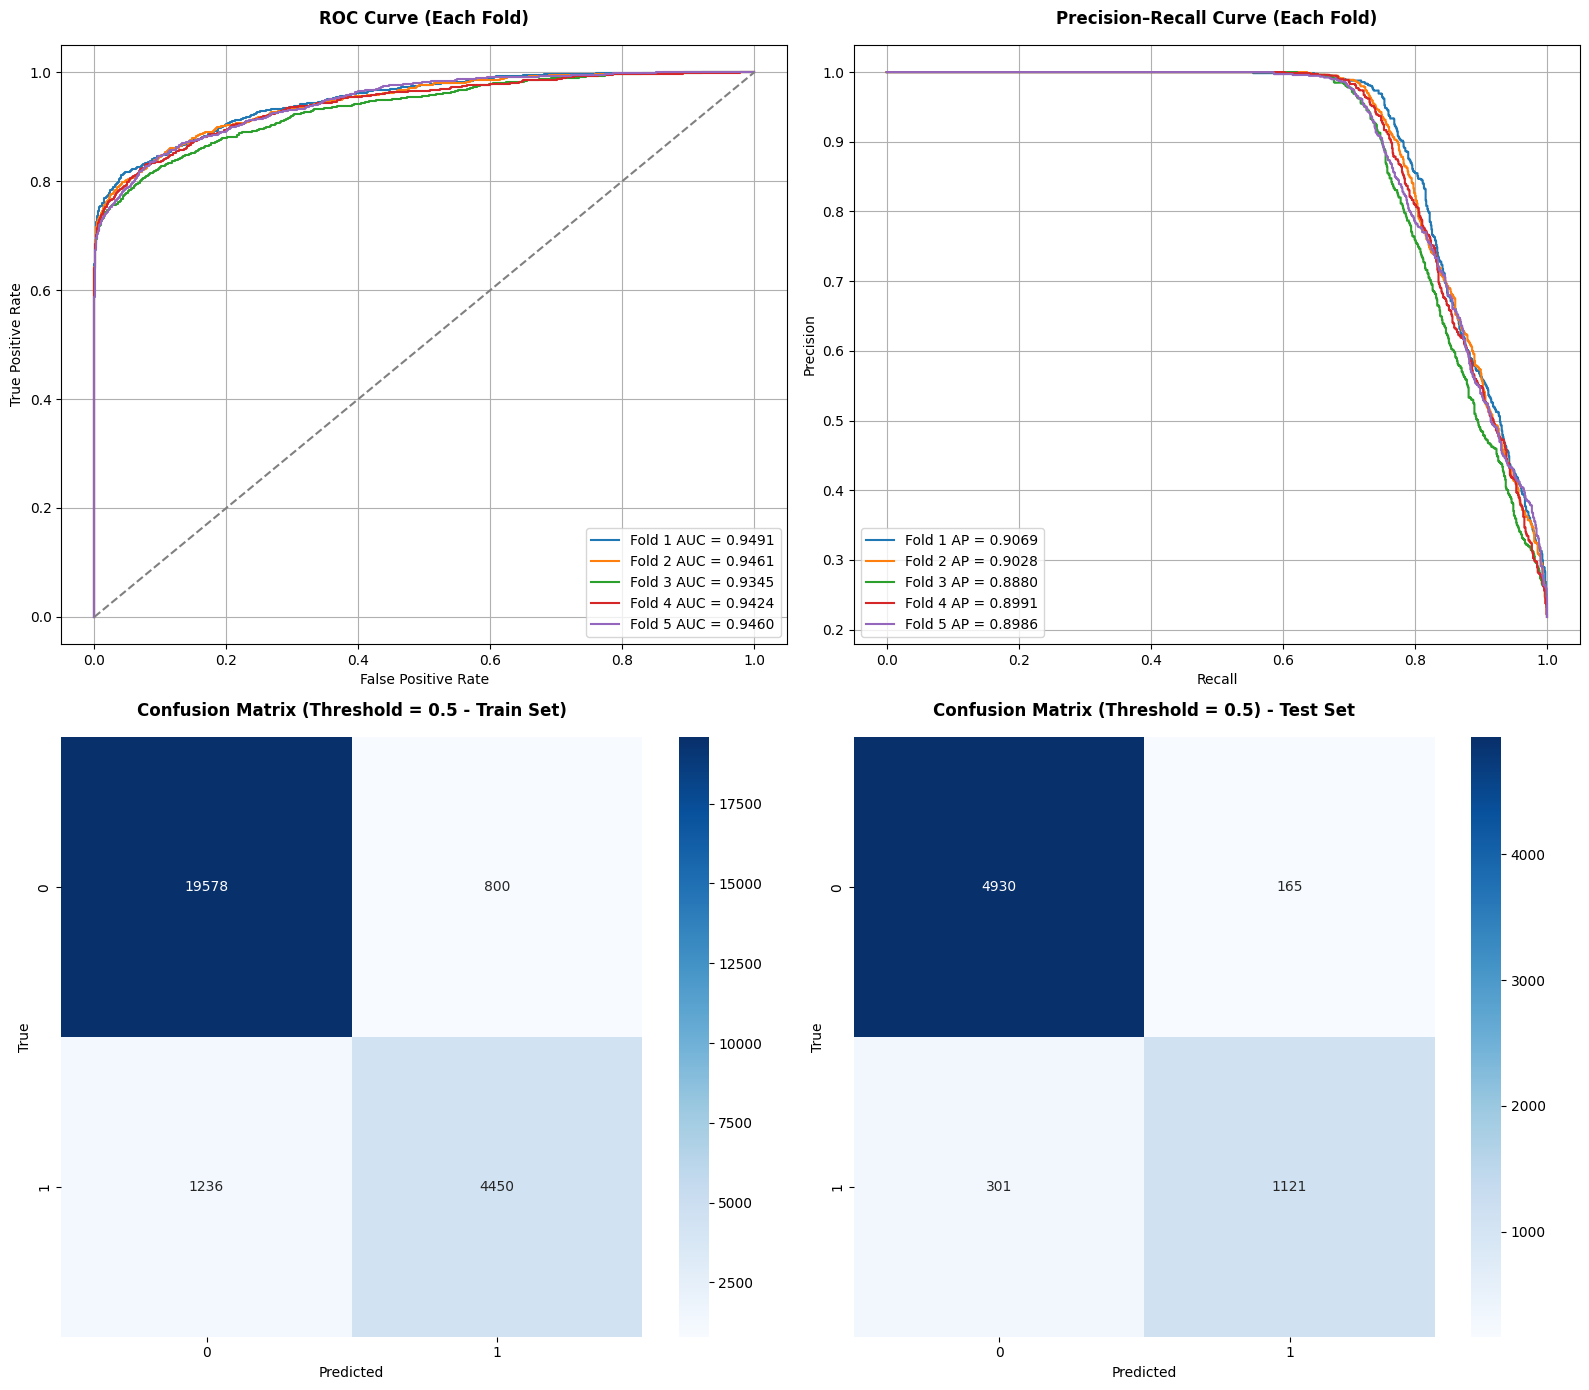

In [26]:
model_cb = CatBoostClassifier(**study_cat.best_params, loss_function="Logloss", auto_class_weights="Balanced", random_seed=CFG.RANDOM_STATE,
                              verbose = 0, thread_count=-1, eval_metric="AUC", grow_policy="SymmetricTree", task_type="CPU",
                              allow_writing_files = False)
X_test_prepared = preprocessor.transform(X_test)
oof_pred_cb, test_pred_cb, fold_auc_cb, fold_models_cb = run_oof(model = model_cb, X = X_train_prepared, y = y_train.values, 
                                                                 X_test = X_test_prepared, y_test=y_test, logger=logger)

## LGBMClassifier

In [27]:
study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(lambda trial: objective_lgbm(trial, X_train_prepared, y_train, logger),
    n_trials=10, show_progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

2026-05-06 13:33:10 | INFO     | Trial 0 finished | Mean AUC: 0.94391
2026-05-06 13:37:14 | INFO     | Trial 1 finished | Mean AUC: 0.94291
2026-05-06 13:39:25 | INFO     | Trial 2 finished | Mean AUC: 0.94000
2026-05-06 13:42:29 | INFO     | Trial 3 finished | Mean AUC: 0.94460
2026-05-06 13:43:40 | INFO     | Trial 4 finished | Mean AUC: 0.94230
2026-05-06 13:44:37 | INFO     | Trial 5 finished | Mean AUC: 0.93255
2026-05-06 13:45:50 | INFO     | Trial 6 finished | Mean AUC: 0.93315
2026-05-06 13:46:43 | INFO     | Trial 7 finished | Mean AUC: 0.94424
2026-05-06 13:47:57 | INFO     | Trial 8 finished | Mean AUC: 0.94533
2026-05-06 13:48:36 | INFO     | Trial 9 finished | Mean AUC: 0.94259


2026-05-06 13:48:36 | INFO     | Starting OOF training with LGBMClassifier
2026-05-06 13:48:36 | INFO     | Fold 1/5
2026-05-06 13:48:36 | INFO     | Fold 1 AUC: 0.92773
2026-05-06 13:48:36 | INFO     | Fold 2/5
2026-05-06 13:48:36 | INFO     | Fold 2 AUC: 0.92469
2026-05-06 13:48:36 | INFO     | Fold 3/5
2026-05-06 13:48:37 | INFO     | Fold 3 AUC: 0.92015
2026-05-06 13:48:37 | INFO     | Fold 4/5
2026-05-06 13:48:37 | INFO     | Fold 4 AUC: 0.91903
2026-05-06 13:48:37 | INFO     | Fold 5/5
2026-05-06 13:48:37 | INFO     | Fold 5 AUC: 0.92375
2026-05-06 13:48:37 | INFO     | OOF training completed
2026-05-06 13:48:37 | INFO     | OOF AUC: 0.92276
2026-05-06 13:48:37 | INFO     | Fold AUCs: [0.9277313928929927, 0.9246874252871777, 0.9201543798868119, 0.9190325293540491, 0.923746593931938]


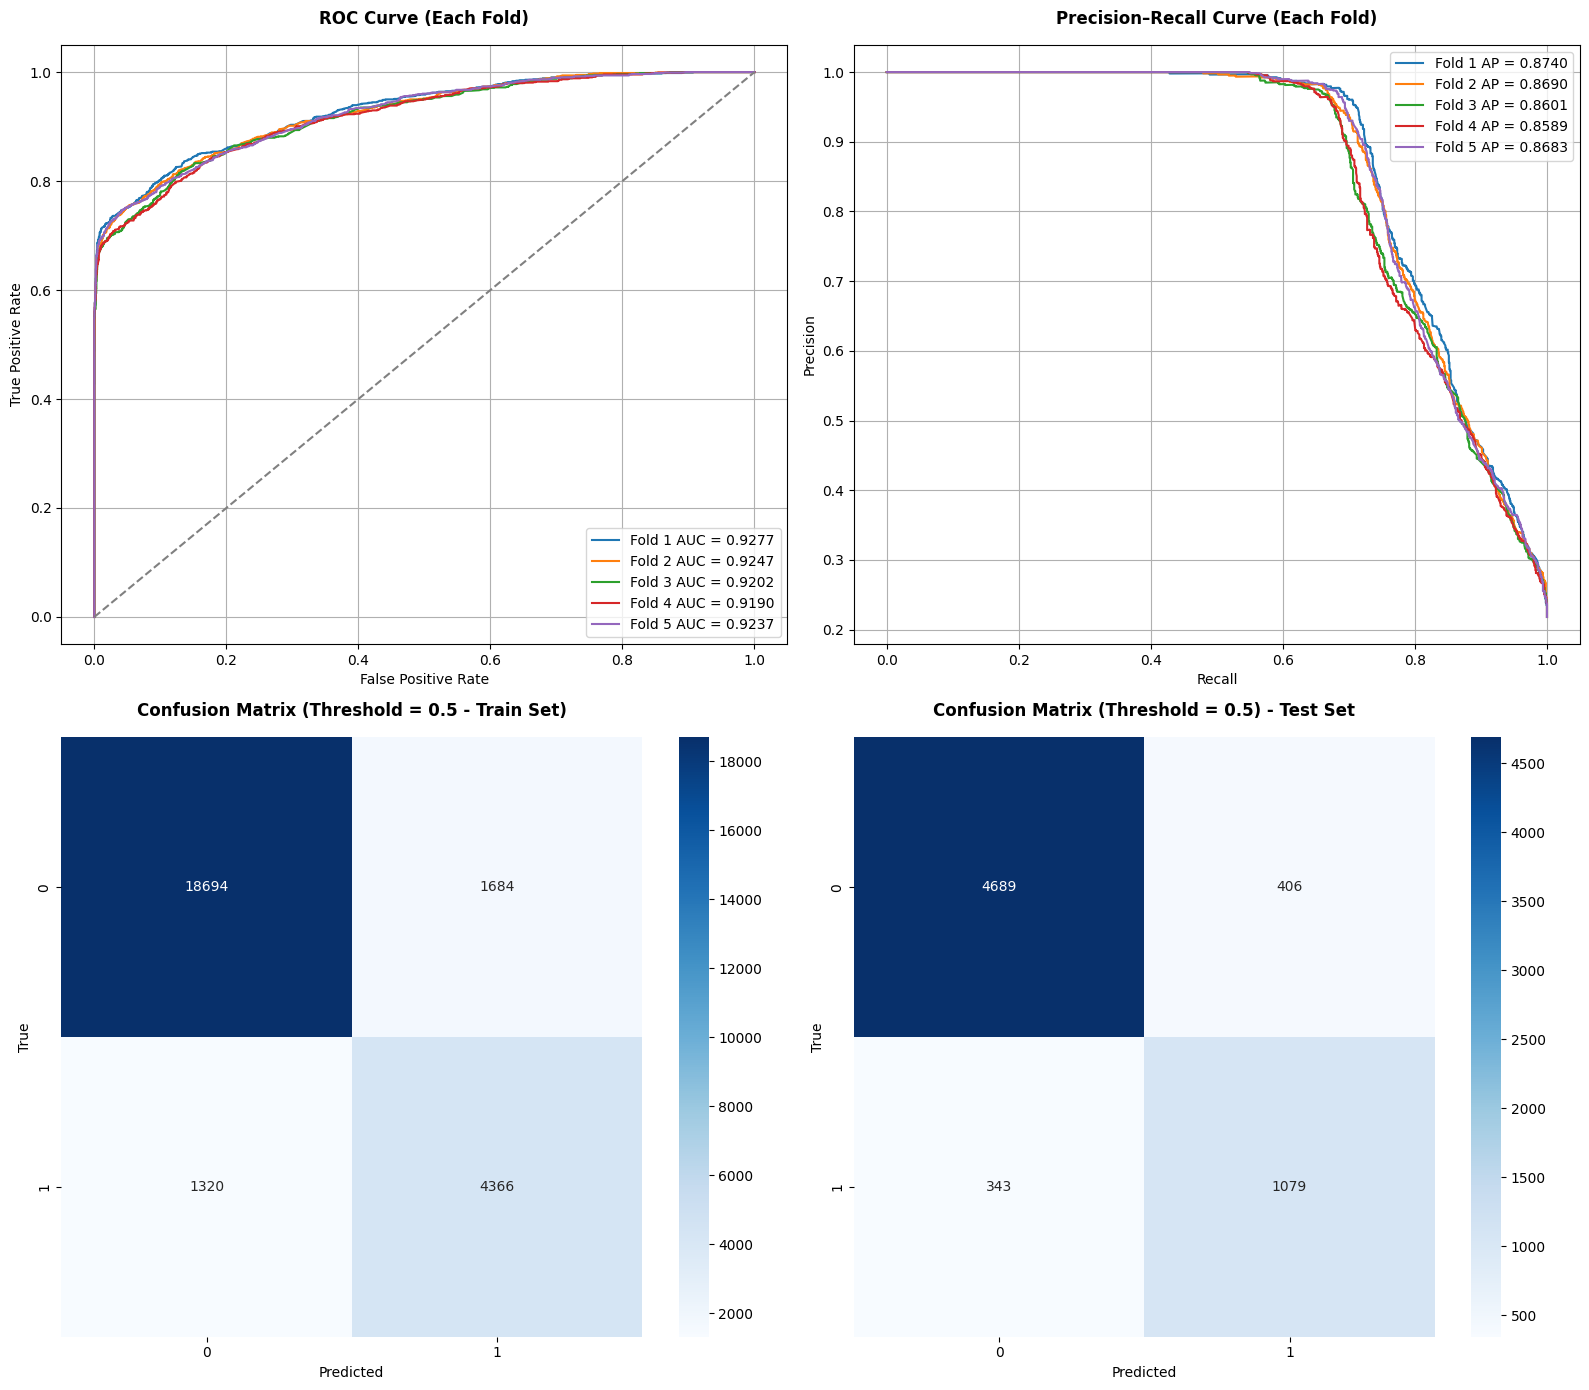

In [28]:
model_lgbm = LGBMClassifier(**study_lgbm.best_params, objective="binary", metric="auc",
                            verbosity=-1, n_jobs=-1, boosting_type="gbdt",
                            class_weight="balanced", random_state=CFG.RANDOM_STATE)
oof_pred_lgbm, test_pred_lgbm, fold_auc_lgbm, fold_models_lgbm = run_oof(model = model_lgbm, X = X_train_prepared, y = y_train.values, 
                                                                         X_test = X_test_prepared, y_test=y_test, logger=logger)

## HistGradientBoostingClassifier

In [29]:
X_train_dense = X_train_prepared.toarray()

study_hgbc = optuna.create_study(direction="maximize")
study_hgbc.optimize(lambda trial: objective_histgb(trial, X_train_dense, y_train, logger),
    n_trials=10, show_progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

2026-05-06 13:48:49 | INFO     | Trial 0 finished | Mean AUC: 0.93041
2026-05-06 13:49:10 | INFO     | Trial 1 finished | Mean AUC: 0.93783
2026-05-06 13:49:16 | INFO     | Trial 2 finished | Mean AUC: 0.93102
2026-05-06 13:49:31 | INFO     | Trial 3 finished | Mean AUC: 0.93755
2026-05-06 13:49:48 | INFO     | Trial 4 finished | Mean AUC: 0.93675
2026-05-06 13:50:09 | INFO     | Trial 5 finished | Mean AUC: 0.93541
2026-05-06 13:50:32 | INFO     | Trial 6 finished | Mean AUC: 0.93684
2026-05-06 13:50:44 | INFO     | Trial 7 finished | Mean AUC: 0.93961
2026-05-06 13:50:57 | INFO     | Trial 8 finished | Mean AUC: 0.93168
2026-05-06 13:51:21 | INFO     | Trial 9 finished | Mean AUC: 0.93821


2026-05-06 13:51:21 | INFO     | Starting OOF training with HistGradientBoostingClassifier
2026-05-06 13:51:21 | INFO     | Fold 1/5
2026-05-06 13:51:24 | INFO     | Fold 1 AUC: 0.94524
2026-05-06 13:51:24 | INFO     | Fold 2/5
2026-05-06 13:51:28 | INFO     | Fold 2 AUC: 0.94208
2026-05-06 13:51:28 | INFO     | Fold 3/5
2026-05-06 13:51:31 | INFO     | Fold 3 AUC: 0.93305
2026-05-06 13:51:31 | INFO     | Fold 4/5
2026-05-06 13:51:32 | INFO     | Fold 4 AUC: 0.93567
2026-05-06 13:51:32 | INFO     | Fold 5/5
2026-05-06 13:51:34 | INFO     | Fold 5 AUC: 0.94203
2026-05-06 13:51:34 | INFO     | OOF training completed
2026-05-06 13:51:34 | INFO     | OOF AUC: 0.93922
2026-05-06 13:51:34 | INFO     | Fold AUCs: [0.9452357710104324, 0.9420787362021331, 0.9330452277441021, 0.9356749005358664, 0.9420304212463105]


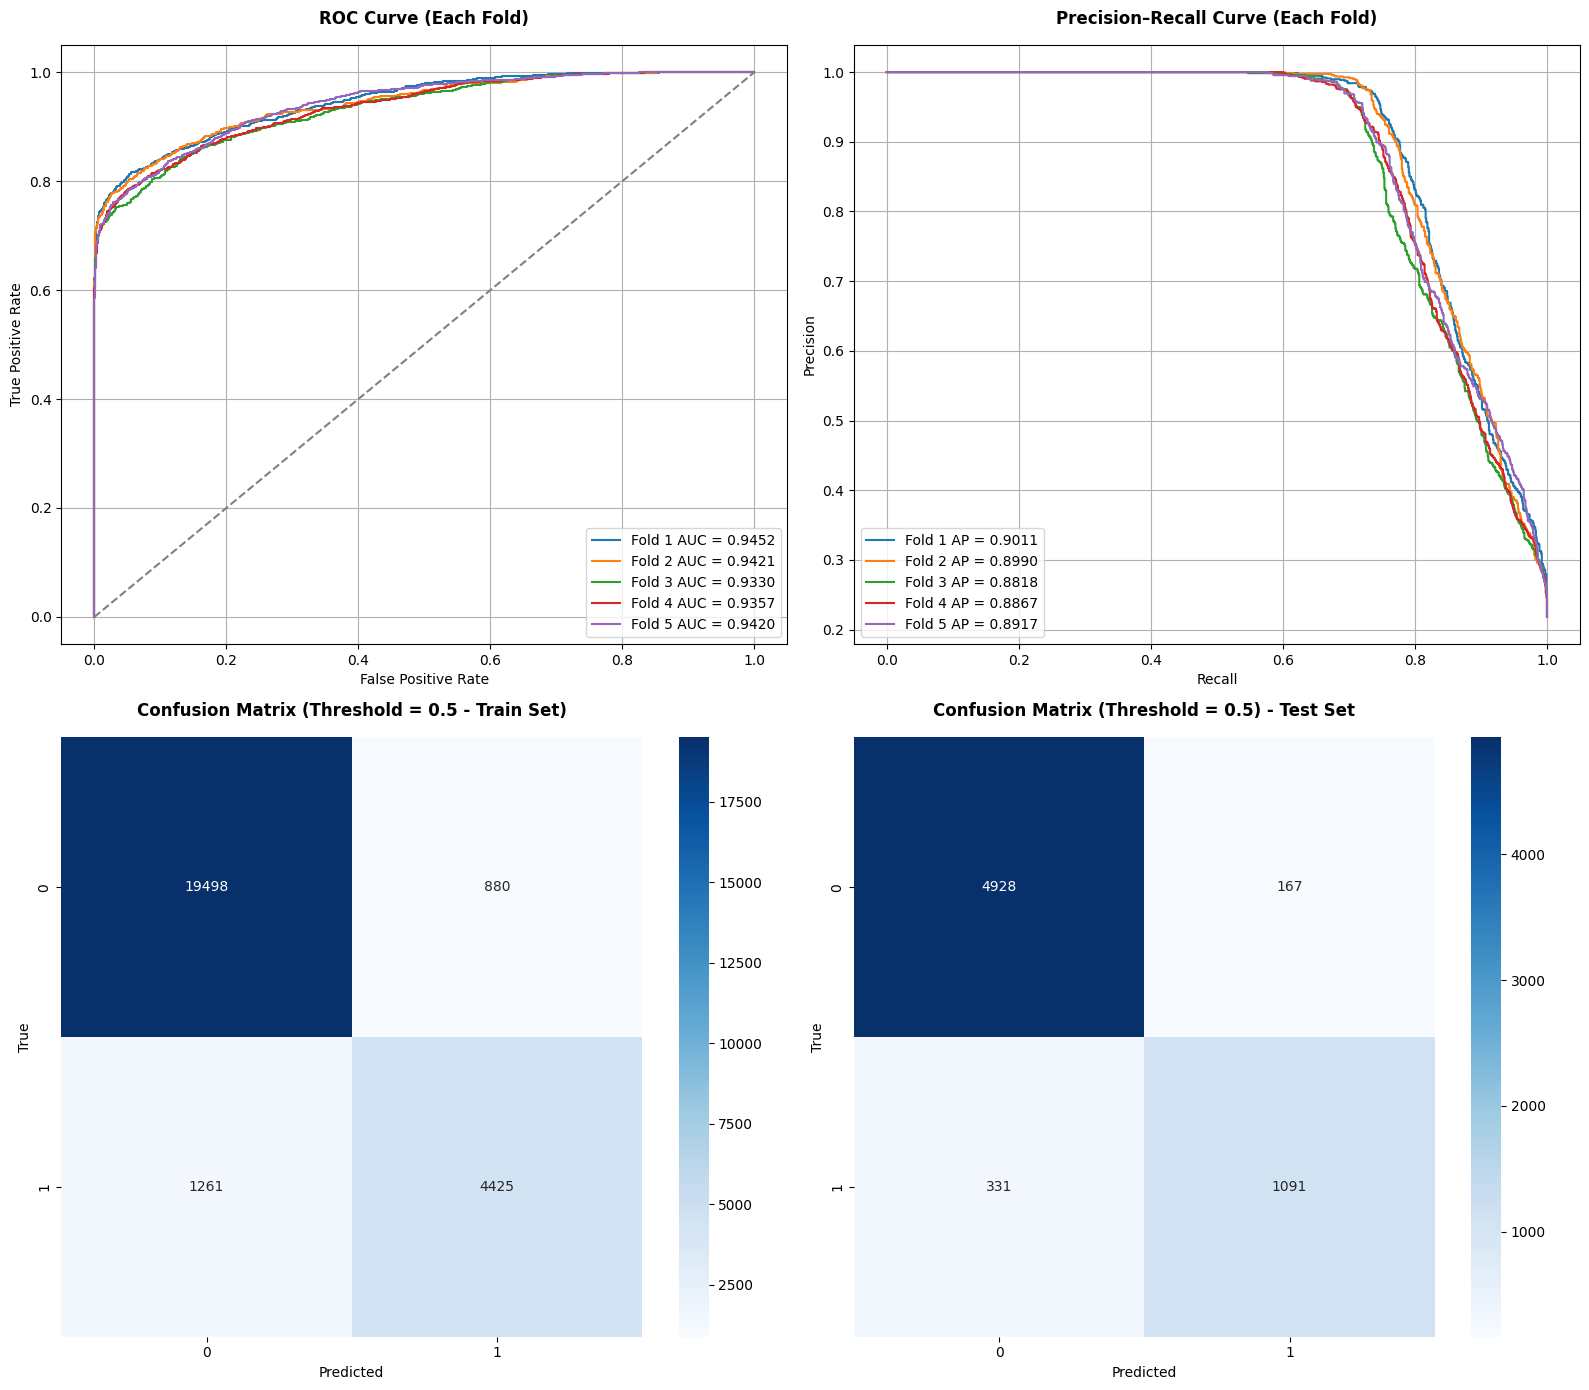

In [30]:
model_hgbc = HistGradientBoostingClassifier(**study_hgbc.best_params, n_iter_no_change=50, validation_fraction=0.1, early_stopping=True,
                                            class_weight="balanced", random_state=CFG.RANDOM_STATE)

X_test_dense = X_test_prepared.toarray()
oof_pred_hgbc, test_pred_hgbc, fold_auc_hgbc, fold_models_hgbc = run_oof(model = model_hgbc, X = X_train_dense, y = y_train.values, 
                                                                         X_test = X_test_dense, y_test=y_test, logger=logger)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation
    </h1>
</div>

2026-05-06 13:51:35 | INFO     | Starting SHAP comparison across models
2026-05-06 13:51:35 | DEBUG    | Converting sparse matrix to dense
2026-05-06 13:51:35 | INFO     | Sampling 1000 rows for SHAP computation
2026-05-06 13:51:35 | INFO     | Computing SHAP values for CatBoostClassifier


PermutationExplainer explainer: 1001it [00:58, 15.99it/s]                         

2026-05-06 13:52:34 | INFO     | 
                           feature  importance
8             loan_to_income_ratio    0.221510
7              loan_percent_income    0.171693
0                    person_income    0.064428
25                    loan_grade_D    0.051140
15      person_home_ownership_RENT    0.037691
3                    loan_int_rate    0.037540
14       person_home_ownership_OWN    0.035829
21             loan_intent_VENTURE    0.021752
18     loan_intent_HOMEIMPROVEMENT    0.021389
22                    loan_grade_A    0.020034
4                       other_debt    0.018406
1                person_emp_length    0.014688
5             debt_to_income_ratio    0.014599
16   loan_intent_DEBTCONSOLIDATION    0.014138
2                        loan_amnt    0.013490
6                       person_age    0.011687
12  person_home_ownership_MORTGAGE    0.010208
11        credit_utilization_ratio    0.009608
23                    loan_grade_B    0.009371
26                    loan


PermutationExplainer explainer: 1001it [00:35, 20.35it/s]                         

2026-05-06 13:53:09 | INFO     | 
                           feature  importance
3                    loan_int_rate    0.068114
8             loan_to_income_ratio    0.056140
0                    person_income    0.054610
25                    loan_grade_D    0.040912
15      person_home_ownership_RENT    0.033903
22                    loan_grade_A    0.033176
14       person_home_ownership_OWN    0.029665
21             loan_intent_VENTURE    0.014889
23                    loan_grade_B    0.013011
18     loan_intent_HOMEIMPROVEMENT    0.010710
24                    loan_grade_C    0.009939
16   loan_intent_DEBTCONSOLIDATION    0.009152
1                person_emp_length    0.008922
19             loan_intent_MEDICAL    0.006747
7              loan_percent_income    0.006306
12  person_home_ownership_MORTGAGE    0.002253
26                    loan_grade_E    0.002020
2                        loan_amnt    0.001563
4                       other_debt    0.001392
17           loan_intent_E

2026-05-06 13:53:09 | INFO     | Computing SHAP values for HistGradientBoostingClassifier


PermutationExplainer explainer: 1001it [03:22,  4.71it/s]                          

2026-05-06 13:56:31 | INFO     | 
                          feature  importance
8            loan_to_income_ratio    0.088938
0                   person_income    0.082352
3                   loan_int_rate    0.065072
7             loan_percent_income    0.043221
14      person_home_ownership_OWN    0.040884
15     person_home_ownership_RENT    0.039088
25                   loan_grade_D    0.037886
22                   loan_grade_A    0.034868
21            loan_intent_VENTURE    0.026542
23                   loan_grade_B    0.020749
18    loan_intent_HOMEIMPROVEMENT    0.018359
16  loan_intent_DEBTCONSOLIDATION    0.017839
1               person_emp_length    0.017838
24                   loan_grade_C    0.015942
4                      other_debt    0.013618
19            loan_intent_MEDICAL    0.012633
2                       loan_amnt    0.011822
11       credit_utilization_ratio    0.010949
6                      person_age    0.008908
5            debt_to_income_ratio    0.008857


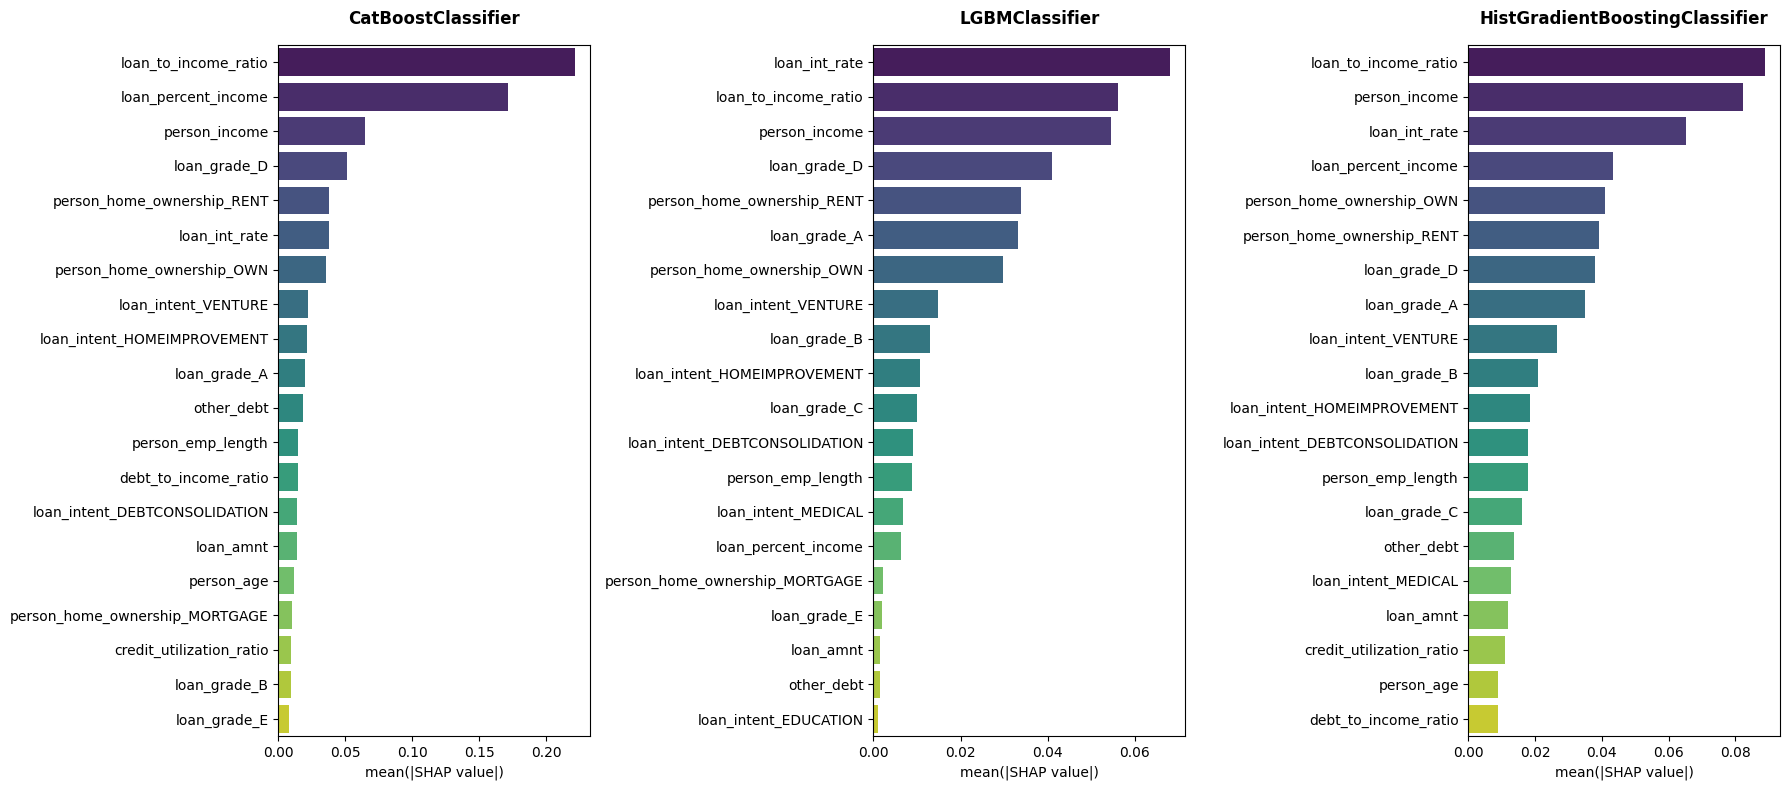

2026-05-06 13:56:32 | INFO     | SHAP comparison completed


In [31]:
max_index_cat = fold_auc_cb.index(max(fold_auc_cb))
max_index_lgbm = fold_auc_lgbm.index(max(fold_auc_lgbm))
max_index_hgbc = fold_auc_hgbc.index(max(fold_auc_hgbc))

list_model = [fold_models_cb[max_index_cat], fold_models_lgbm[max_index_lgbm], fold_models_hgbc[max_index_hgbc]]
shap_compare_models(models=list_model, X_test=X_test_prepared, logger=logger, feature_names=clean_features)

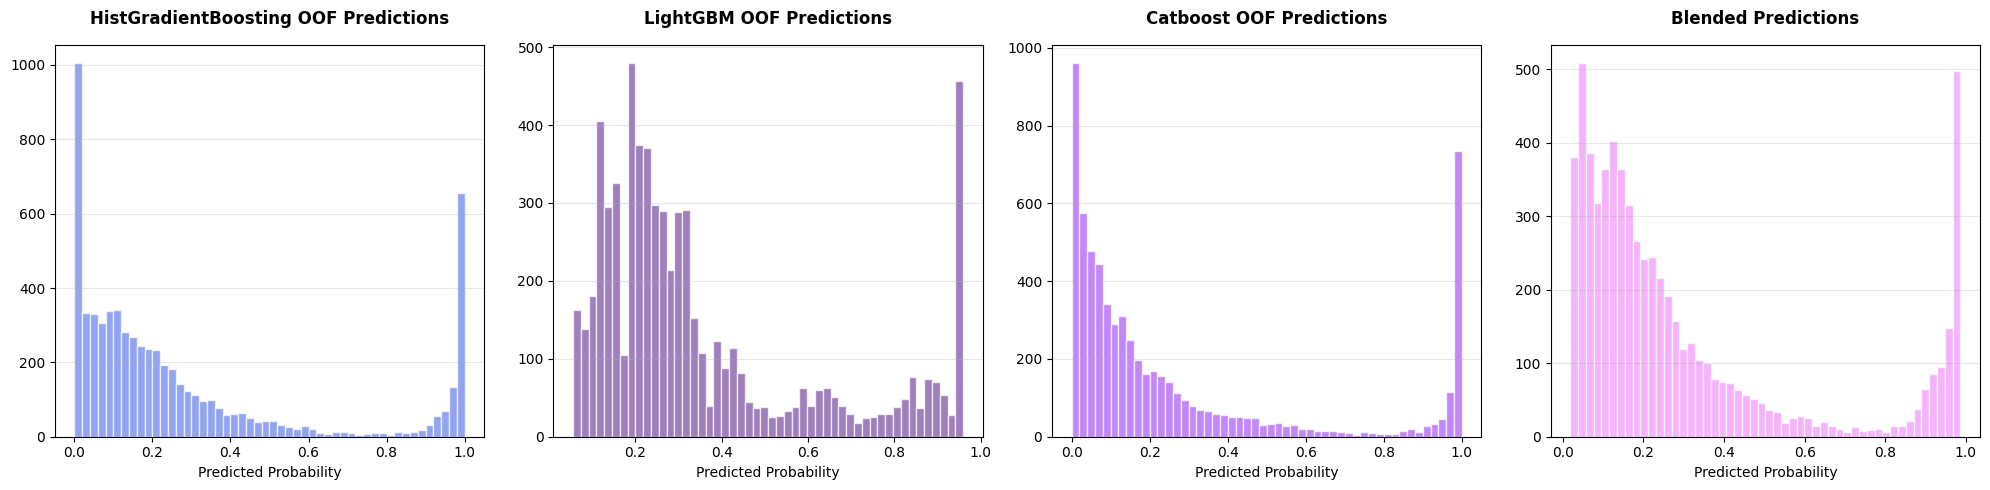

In [41]:
hgbc_auc = roc_auc_score(y_train, oof_pred_hgbc)
cat_auc = roc_auc_score(y_train, oof_pred_cb)
lgbm_auc = roc_auc_score(y_train, oof_pred_lgbm)

# AUC-weighted blend
total_auc = hgbc_auc + cat_auc + lgbm_auc
w_hgbc = hgbc_auc / total_auc
w_cat = cat_auc / total_auc
w_lgbm = lgbm_auc / total_auc

blended_test = w_hgbc * test_pred_hgbc + w_cat * test_pred_cb + w_lgbm * test_pred_lgbm

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
COLORS = ["#667eea", "#764ba2", "#a855f7", "#f093fb", "#fbc2eb"]

ax[0].hist(test_pred_hgbc, bins=50, color=COLORS[0], alpha=0.7, edgecolor="white")
ax[0].set_title("HistGradientBoosting OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[0].set_xlabel("Predicted Probability", fontsize=10)
ax[0].grid(axis="y", alpha=0.3)

ax[1].hist(test_pred_lgbm, bins=50, color=COLORS[1], alpha=0.7, edgecolor="white")
ax[1].set_title("LightGBM OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[1].set_xlabel("Predicted Probability", fontsize=10)
ax[1].grid(axis="y", alpha=0.3)

ax[2].hist(test_pred_cb, bins=50, color=COLORS[2], alpha=0.7, edgecolor="white")
ax[2].set_title("Catboost OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[2].set_xlabel("Predicted Probability", fontsize=10)
ax[2].grid(axis="y", alpha=0.3)

ax[3].hist(blended_test, bins=50, color=COLORS[3], alpha=0.7, edgecolor="white")
ax[3].set_title("Blended Predictions", fontsize=12, fontweight="bold", pad=15)
ax[3].set_xlabel("Predicted Probability", fontsize=10)
ax[3].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
hgbc_binary = (test_pred_hgbc >= 0.5).astype(int)
lgb_binary = (test_pred_lgbm >= 0.5).astype(int)
cat_binary = (test_pred_cb >= 0.5).astype(int)

logger.info("HistGradientBoosting Classification Report:")
logger.info("\n" + classification_report(y_test, hgbc_binary, target_names=['No', 'Yes']))
logger.info("*" * 80)

logger.info("LightGBM Classification Report:")
logger.info("\n" + classification_report(y_test, lgb_binary, target_names=['No', 'Yes']))
logger.info("*" * 80)

logger.info("CatBoost Classification Report:")
logger.info("\n" + classification_report(y_test, cat_binary, target_names=['No', 'Yes']))
logger.info("*" * 80)

2026-05-06 14:19:41 | INFO     | HistGradientBoosting Classification Report:
2026-05-06 14:19:41 | INFO     | 
              precision    recall  f1-score   support

          No       0.94      0.97      0.95      5095
         Yes       0.87      0.77      0.81      1422

    accuracy                           0.92      6517
   macro avg       0.90      0.87      0.88      6517
weighted avg       0.92      0.92      0.92      6517

2026-05-06 14:19:41 | INFO     | ********************************************************************************
2026-05-06 14:19:41 | INFO     | LightGBM Classification Report:
2026-05-06 14:19:41 | INFO     | 
              precision    recall  f1-score   support

          No       0.93      0.92      0.93      5095
         Yes       0.73      0.76      0.74      1422

    accuracy                           0.89      6517
   macro avg       0.83      0.84      0.83      6517
weighted avg       0.89      0.89      0.89      6517

2026-05-06 14:19:41 | 

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 10px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Key Business Recommendations
</div>

<div style="
    margin-bottom: 20px;
    font-size: 14px;
    color: #d5dbdb;
    font-style: italic;
">
Key drivers of default are <b>financial capacity</b> and <b>credit behavior</b>.
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>
<b>Focus on Repayment Capacity (Most Important)</b>
<ul>
<li>Use <b>DTI &amp; income ratios</b> as core approval criteria</li>
<li>High ratio → <b>reject or increase interest rate</b></li>
</ul>
</li>

<li>
<b>Leverage Loan Grade for Risk Segmentation</b>
<ul>
<li>A–B: approve &amp; low rate</li>
<li>C–D: controlled lending</li>
<li>E–G: <b>restrict / tighten conditions</b></li>
</ul>
</li>

<li>
<b>Flag High-Risk Customers</b>
<ul>
<li>Prior default (<code>cb_person_default_on_file = Y</code>) → <b>strong reject or strict policy</b></li>
<li>Renters + low income → <b>higher monitoring</b></li>
</ul>
</li>

<li>
<b>Adjust by Loan Purpose</b>
<ul>
<li>Risky: <b>debt consolidation, medical</b> → stricter approval</li>
<li>Safer: <b>education, venture</b> → growth opportunity</li>
</ul>
</li>

<li>
<b>Simplify Decision Factors</b>
<ul>
<li>Focus on: <b>income, DTI, loan grade, past default</b></li>
<li>Ignore: <b>demographics &amp; location (no impact)</b></li>
</ul>
</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy coding 🙌😊
    </p>
</div>
